<a href="https://colab.research.google.com/github/ryoder96/clinical-nlp-uncertainty/blob/main/NLP_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clinical NLP — Uncertainty-Aware Specialty Routing
### MSBX 5425 | University of Colorado | 2026

---

## Project Overview
We fine-tune ClinicalBERT on unstructured medical transcriptions to classify
notes by medical specialty. Instead of always outputting a single confident
answer, we use **conformal prediction** to output a set of possible specialties
that reflects how certain the model is.

**Core question:** Can we build a model that not only routes clinical notes to
the right specialty, but reliably signals when it shouldn't be trusted?

---

## Repository
`github.com/ryoder96/clinical-nlp-uncertainty`

---

## Setup Instructions

### 1. Upload the dataset
Download MTSamples from Kaggle:
`https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions`

Upload `mtsamples.csv` to this Colab session:
```python
from google.colab import files
uploaded = files.upload()
```
Or mount Google Drive if the file is already there (recommended):
```python
from google.colab import drive
drive.mount('/content/drive')
```

### 2. GPU Runtime (required for training)
`Runtime → Change runtime type → T4 GPU`
Do this before running any training cells or it will time out.

### 3. Install dependencies
Run the first code cell — it installs all required libraries.

### 4. Saving your work
Always save back to GitHub after a working session:
`File → Save a copy in GitHub`
Write a short commit message describing what you changed.
**Clear outputs first:** `Edit → Clear all outputs` before saving.

---

## ******** Notebook Structure TBD***********
| Section | Description |
|---|---|
| 1. Setup & Imports | Install libraries, mount Drive |
| 2. Data Loading & EDA | Load MTSamples, clean and explore |
| 3. Preprocessing | Label encoding, train/cal/test split |
| 4. Model Training | Fine-tune ClinicalBERT |
| 5. Embeddings | Extract CLS embeddings and softmax scores |
| 6. Conformal Prediction | Calibration, prediction sets, coverage |
| 7. Outlier Detection | k-NN density scoring in embedding space |
| 8. Evaluation | Coverage, efficiency, calibration curve |
| 9. Error Analysis | Confusion matrix, confident failures |
| 10. Stress Testing | Noise injection, synthetic hard cases |
| 11. Explainability | scispaCy span tagging, nearest neighbors |
| 12. Conclusions | Findings, limitations, future work |

---

## Authors
- **Rebecca Yoder, Ariadnee Ziady**


---
### Article used (for citations)
Kompa, B., Snoek, J. & Beam, A.L. Second opinion needed: communicating uncertainty in medical machine learning. npj Digit. Med. 4, 4 (2021). https://doi.org/10.1038/s41746-020-00367-3

## Introduction

### The Problem: Clinical AI Models Fail Silently

Artificial intelligence is reshaping healthcare administration. Machine learning
models are being deployed across revenue cycle management, clinical documentation,
diagnostic support, and utilization review with the promise of reducing administrative
burden, accelerating reimbursement, and improving consistency. Among the most actively
deployed applications is AI-assisted clinical coding: systems that read unstructured
clinical notes and suggest ICD-10 diagnostic and procedural codes, reducing the
time and expertise required to translate clinical documentation into billable claims.

These tools are sold on the basis of aggregate performance metrics. A vendor
reports a micro-F1 score of 0.60, or an accuracy of 92%, and a health system's
procurement team must decide whether that is sufficient to trust for automated
claim submission. But aggregate accuracy does not answer the question that matters
at the point of submission: should this specific code suggestion, for this specific
note, be trusted, or should it be reviewed before filing?

Clinical AI models fail silently, meaning a confidently wrong answer looks identical to a
confidently right one. There is no flag to the clinician or
coder that something is off. Recent work confirms that uncertainty quantification
is not routinely practiced in clinical AI models — even widely cited ones have no
mechanism to say "I don't know" (Kompa et al., 2021). In the context of
AI-assisted coding, this silence is not just an accuracy problem. It is a financial
and operational one.

### The Stakes: Predictive Denial Analytics

The consequences of confident wrong predictions in clinical coding are concrete and
quantifiable. Miscoded claims are denied by payers, triggering appeals processes,
delayed reimbursement, compliance exposure, and administrative burden. Health
systems have responded by deploying predictive denial analytics — machine learning
models that analyze historical denial patterns and flag high-risk code suggestions
before submission. These systems represent exactly the kind of high-stakes clinical
NLP classification task where prediction-level uncertainty matters most: a model
that confidently flags the wrong code as high-risk, or fails to flag a genuinely
risky code, imposes direct financial consequences on the institution and indirect
consequences on the patients whose claims are delayed or denied.

Recent work such as MedCodER (Baksi et al., 2024) demonstrates that generative AI
can achieve strong aggregate performance on ICD-10 coding — but reports no mechanism
for quantifying uncertainty at the individual prediction level, leaving health systems
with no basis for determining which code suggestions should be auto-submitted and
which should be reviewed. The state of the art in clinical coding AI is powerful
but opaque.

### The Regulatory Gap

Regulatory frameworks have not kept pace with deployment. The American Health
Information Management Association's 2024 AI Regulatory Resource Guide explicitly
acknowledges that the US regulatory framework for healthcare AI contains gaps, and
that federal agencies have limited statutory authority to regulate deployed AI tools
(AHIMA, 2024). Existing regulations govern coding accuracy standards — ICD-10-CM
guidelines from CMS, HIPAA data handling requirements, Medicare and Medicaid billing
compliance — but none require AI-assisted coding tools to quantify or communicate
uncertainty at the individual prediction level.

Emerging state legislation is beginning to address AI oversight in healthcare, with
more than 250 bills introduced across states as of November 2025 (AMA, 2025).
Enacted laws in Maryland, Nebraska, and Texas require human oversight of AI-assisted
clinical decisions and prohibit AI from serving as the sole basis for adverse
determinations. But no enacted law specifies what uncertainty information an AI
system must provide to enable meaningful human review. The laws mandate that a human
must look — they do not specify what the AI should show them.

Conformal prediction addresses this gap directly. By replacing a single confident
prediction with a statistically guaranteed set of plausible outputs, it provides
a principled, mathematically grounded uncertainty signal that can inform human
review decisions. A wide prediction set flags a note for coder review before
submission. A singleton prediction indicates confidence. An empty set signals an
outlier note that does not resemble anything the model was calibrated on.

### The Problem Within the Solution

However, conformal prediction is not a complete solution on its own. Recent work
has identified a critical limitation: the coverage guarantee is a marginal property
over the full data distribution and does not hold reliably for individual subgroups
(Mehrtens et al., 2025). In imbalanced clinical datasets — where common diagnoses
dominate training data and rare conditions are underrepresented — the guarantee may
hold in aggregate while systematically failing for exactly the code categories most
likely to attract payer scrutiny. A vendor reporting 90% aggregate conformal coverage
on a coding tool may be concealing 54% coverage on rare diagnosis categories —
precisely the codes most likely to be denied.

This is the problem within the solution. Conformal prediction provides the right
framework, but aggregate conformal coverage is itself an insufficient evaluation
standard. What is needed is a structured evaluation battery — a set of tests that
must be run before a conformal-wrapped coding tool can be trusted in production —
that surfaces the failure dimensions aggregate metrics conceal.

### This Project

This project proposes and demonstrates such a battery. Using MTSamples — a publicly
available collection of 4,999 clinical transcriptions labeled by medical specialty —
as a controlled proxy for diagnostic coding, a ClinicalBERT classifier is fine-tuned
and wrapped with a conformal prediction layer. Specialty classification serves as
a methodologically appropriate proxy for ICD-10 coding: both tasks involve reading
unstructured clinical note text and assigning it to a categorical clinical label.
MTSamples is used as a testbed by deliberate methodological choice, not as a
limitation — ground-truth labeled clinical coding data is proprietary and not
publicly available, and a publicly available dataset with known properties enables
reproducible evaluation.

Five experiments and a systematic error analysis are conducted to identify where
and why the conformal guarantee breaks down. The findings are operationalized into
a six-test evaluation battery — the Conformal Evaluation Battery for AI-Assisted
Clinical Coding — that any health system or procurement team can apply to any
conformal-wrapped coding tool before deployment.

The central argument is this: aggregate coverage is not enough. A conformal coding
tool that reports 90% aggregate coverage may be systematically failing on rare
diagnosis codes, producing confident wrong predictions at unacceptable rates,
degrading under incomplete documentation, and generating coverage guarantees that
are unstable under local calibration conditions. The evaluation battery proposed
here makes these failure modes visible — and gives health systems the tools to
demand disclosure before they deploy.

## This Notebook explores the Kaggle dataset mtsamples
More info tbd

In [ ]:
'''
# In Colab
!pip install kaggle
!kaggle datasets download -d tboyle10/medicaltranscriptions

Dataset URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions
License(s): CC0-1.0
100% 4.85M/4.85M [00:01<00:00, 3.01MB/s]



In [ ]:
'''
!unzip medicaltranscriptions.zip

Archive:  medicaltranscriptions.zip
  inflating: mtsamples.csv           


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================
# STEP 1: Load and inspect
# =============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/NLP Project/mtsamples_with_entities.csv', index_col=0)

print(df.shape)
print(df.columns.tolist())

(3743, 7)
['medical_specialty', 'sample_name', 'transcription', 'keywords', 'word_count', 'label', 'entity_text']


In [ ]:
df.loc[:,['medical_specialty','transcription']]

,medical_specialty,transcription
description,,
2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
2-D Echocardiogram,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...
2-D Echocardiogram,Cardiovascular / Pulmonary,"2-D ECHOCARDIOGRAM,Multiple views of the heart..."
Echocardiogram and Doppler,Cardiovascular / Pulmonary,"DESCRIPTION:,1. Normal cardiac chambers size...."
"Normal left ventricle, moderate biatrial enlargement, and mild tricuspid regurgitation, but only mild increase in right heart pressures.",Cardiovascular / Pulmonary,"2-D STUDY,1. Mild aortic stenosis, widely calc..."
...,...,...
Adenosine with nuclear scan as the patient unable to walk on a treadmill. Nondiagnostic adenosine stress test. Normal nuclear myocardial perfusion scan.,Cardiovascular / Pulmonary,"INDICATION: , Chest pain.,TYPE OF TEST: , Aden..."
Patient presents with a chief complaint of chest pain admitted to Coronary Care Unit due to acute inferior myocardial infarction.,Cardiovascular / Pulmonary,"CHIEF COMPLAINT: , Chest pain.,HISTORY OF PRES..."
"Patient had a recurrent left arm pain after her stent, three days ago, and this persisted after two sublingual nitroglycerin.",Cardiovascular / Pulmonary,"HISTORY OF PRESENT ILLNESS: , The patient is a..."


In [ ]:
df.head()

,medical_specialty,sample_name,transcription,keywords,word_count,label,entity_text
description,,,,,,,
2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",68,0,2-D Left_atrial_enlargement left_atrial_diamet...
2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",229,0,left_ventricular_cavity_size wall thickness no...
2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 3,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","cardiovascular / pulmonary, 2-d echocardiogram...",109,0,2-D_ECHOCARDIOGRAM Multiple_views heart great_...
Echocardiogram and Doppler,Cardiovascular / Pulmonary,2-D Echocardiogram - 4,"DESCRIPTION:,1. Normal cardiac chambers size....","cardiovascular / pulmonary, ejection fraction,...",57,0,"DESCRIPTION:,1 Normal_cardiac_chambers size.,2..."
"Normal left ventricle, moderate biatrial enlargement, and mild tricuspid regurgitation, but only mild increase in right heart pressures.",Cardiovascular / Pulmonary,2-D Doppler,"2-D STUDY,1. Mild aortic stenosis, widely calc...","cardiovascular / pulmonary, 2-d study, doppler...",83,0,"2-D_STUDY,1 aortic_stenosis calcified minimall..."


### Notes on step 1 cell:
* transcription = NLP input
* medical specialty = label

In [ ]:
# =============================================
# STEP 2: Missing values
# =============================================
print(df.isnull().sum())
print(f"\nMissing transcriptions: {df['transcription'].isnull().sum()}")
print(f"Missing specialties: {df['medical_specialty'].isnull().sum()}")

# Drop rows with missing transcription or specialty — unusable for us
df = df.dropna(subset=['transcription', 'medical_specialty'])
print(f"\nRows after dropping nulls: {len(df)}")

medical_specialty      0
sample_name            0
transcription          0
keywords             648
word_count             0
label                  0
entity_text            0
dtype: int64

Missing transcriptions: 0
Missing specialties: 0

Rows after dropping nulls: 3743


### Notes on Step 2 cell:
* 33 missing transcriptions - we'll drop those
* 1,068 missing keywords - don't care

medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

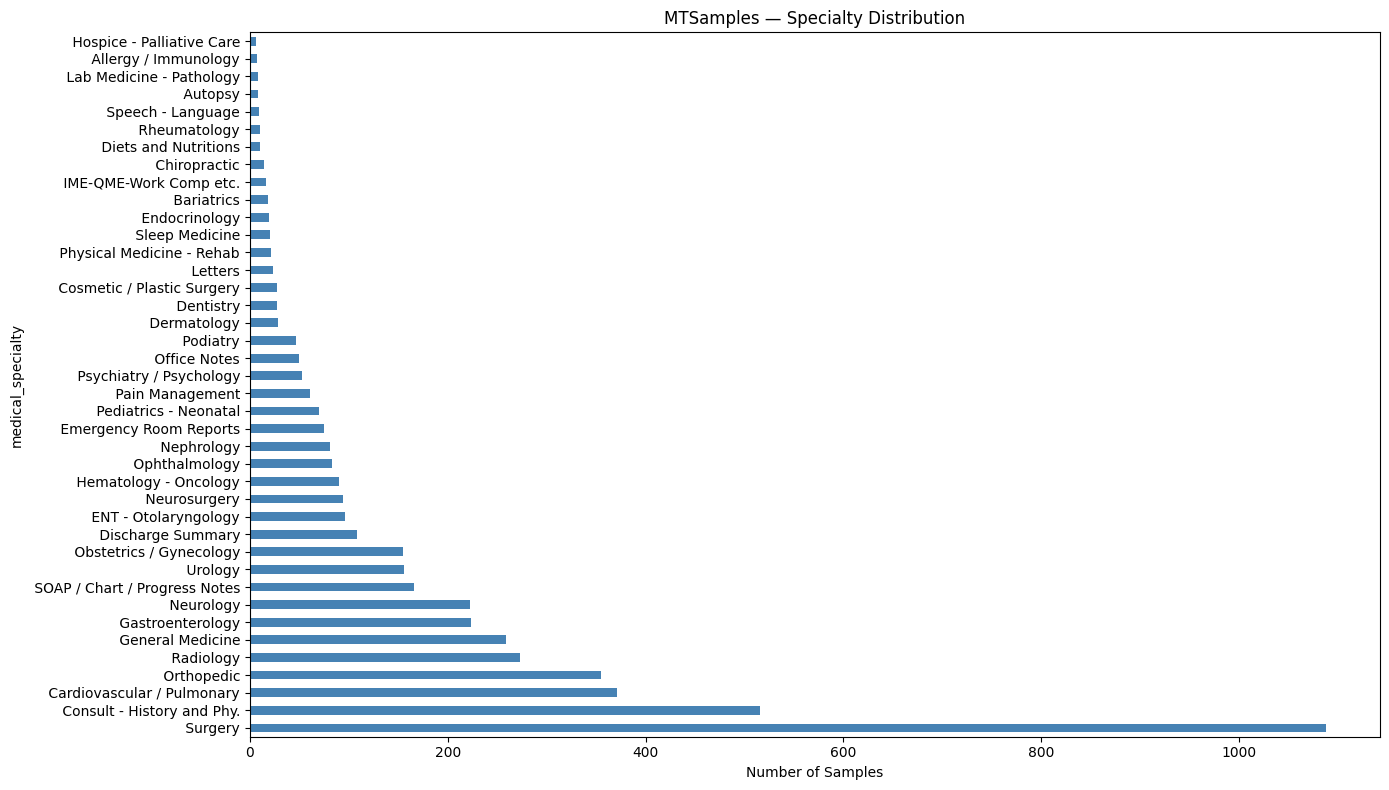

In [ ]:
# =============================================
# STEP 3: Class distribution — the critical one
# =============================================
specialty_counts = df['medical_specialty'].value_counts()
print(specialty_counts)
print(f"\nNumber of unique specialties: {df['medical_specialty'].nunique()}")
print(f"Classes with fewer than 50 samples: {(specialty_counts < 50).sum()}")
print(f"Classes with fewer than 20 samples: {(specialty_counts < 20).sum()}")

# Visualize
plt.figure(figsize=(14, 8))
specialty_counts.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Samples')
plt.title('MTSamples — Specialty Distribution')
plt.tight_layout()
plt.show()

### Notes on Step 3 cell:
Drop:
* Consult
* SOAP
* Discharge summary
* Office notes
* Letters
* IME_QME-WORK Comp
* Lab medicine

Potential Drops due to Scarcity:
* Podiatry and below

In [ ]:
# =============================================
# STEP 3b: Drop categories we don't want
# =============================================
df['medical_specialty'] = df['medical_specialty'].str.strip()

# Now redo the drop
specialty_counts = df['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 30].index.tolist()

drop_labels = [
    'Consult - History and Phy.',
    'SOAP / Chart / Progress Notes',
    'Discharge Summary',
    'Office Notes',
    'Letters',
    'IME-QME-Work Comp etc.',
    'Lab Medicine - Pathology',
    'Autopsy',
    'Hospice - Palliative Care'
]

drop_all = list(set(drop_labels + small_classes))
df_clean = df[~df['medical_specialty'].isin(drop_all)].copy()

print(f"Rows remaining: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows remaining: 3854
Specialties remaining: 19
medical_specialty
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   83
Nephrology                      81
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 61
Psychiatry / Psychology         53
Podiatry                        47
Name: count, dtype: int64


### Notes on Cell 3b
* Surgery is overrepresented
* Options:
  * undersample surgery
  * use class weights during training

Note: clinical overlaps
* Surgery + Orthopedic + Neurosurgery — all cutting specialties, notes will bleed together
* Neurology + Neurosurgery — obvious overlap
* Cardiovascular/Pulmonary is already merged — interesting that whoever labeled this data combined them

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


count     500.00000
mean      795.17400
std       473.46296
min        16.00000
25%       441.25000
50%       716.50000
75%      1061.25000
max      3192.00000
Name: token_count, dtype: float64

Notes exceeding 512 tokens: 338 / 500
Notes exceeding 512 tokens: 67.6%


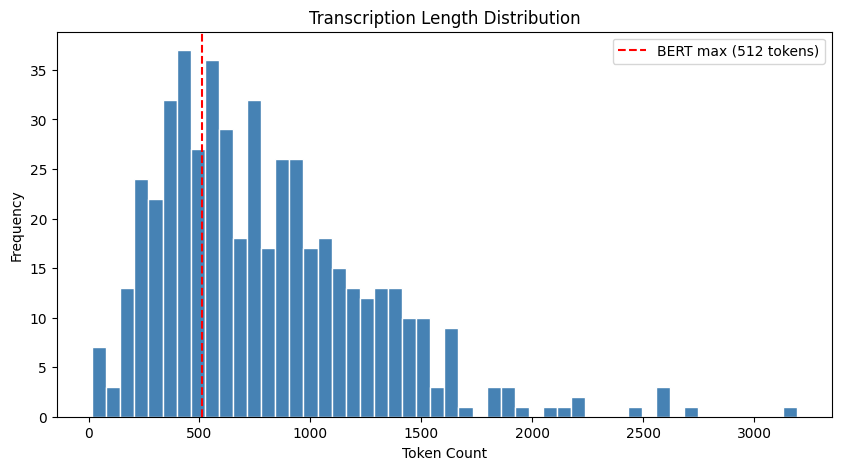

In [ ]:
# =============================================
# STEP 4: Transcription length — critical for BERT
# =============================================
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

# Sample 500 rows for speed
sample = df.sample(500, random_state=42)
sample['token_count'] = sample['transcription'].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

print(sample['token_count'].describe())
print(f"\nNotes exceeding 512 tokens: {(sample['token_count'] > 512).sum()} / 500")
print(f"Notes exceeding 512 tokens: {(sample['token_count'] > 512).mean():.1%}")

plt.figure(figsize=(10, 5))
plt.hist(sample['token_count'], bins=50, color='steelblue', edgecolor='white')
plt.axvline(512, color='red', linestyle='--', label='BERT max (512 tokens)')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Transcription Length Distribution')
plt.legend()
plt.show()

### Notes on step 4
* 67.6% of notes exceed 512 tokens
* Options:
  * Truncate
  * Concatenate description + transcription then truncate
  * use description field
  * chunk and pool
  * Don't use BERT at all! (longformer, but not clinical)
  * Head Tail tokenization (first and last 255)

In [ ]:
# =============================================
# STEP 5: Text quality check
# =============================================

# Are notes actually clinical text or garbage?
print("--- 3 random transcriptions ---\n")
for _, row in df.sample(3, random_state=1).iterrows():
    print(f"SPECIALTY: {row['medical_specialty']}")
    print(f"TEXT: {row['transcription'][:300]}")
    print("-" * 60)

# Check for very short notes that might be useless
df['word_count'] = df['transcription'].apply(lambda x: len(str(x).split()))
print(f"\nNotes under 50 words: {(df['word_count'] < 50).sum()}")
print(df[df['word_count'] < 50][['medical_specialty', 'transcription']].head(5))

--- 3 random transcriptions ---

SPECIALTY: General Medicine
TEXT: HISTORY OF PRESENT ILLNESS:, The patient is a 71-year-old Caucasian female with a history of diabetes, osteoarthritis, atrial fibrillation, hypertension, asthma, obstructive sleep apnea on CPAP, diabetic foot ulcer, anemia and left lower extremity cellulitis. She was brought in by the EMS service to
------------------------------------------------------------
SPECIALTY: Obstetrics / Gynecology
TEXT: PREOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,POSTOPERATIVE DIAGNOSIS: , Postpartum hemorrhage.,PROCEDURE:,  Exam under anesthesia.  Removal of intrauterine clots.,ANESTHESIA: , Conscious sedation.,ESTIMATED BLOOD LOSS:,  Approximately 200 mL during the procedure, but at least 500 mL prior to tha
------------------------------------------------------------
SPECIALTY: Pediatrics - Neonatal
TEXT: HISTORY OF PRESENT ILLNESS: , This is a ** week gestational age ** delivered by ** at ** on **.  Gestational age was determined b

In [ ]:
df_clean['word_count'] = df_clean['transcription'].apply(lambda x: len(str(x).split()))
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")
print(f"Specialties remaining: {df_clean['medical_specialty'].nunique()}")
print(df_clean['medical_specialty'].value_counts())

Rows after dropping short notes: 3790
Specialties remaining: 19
medical_specialty
Surgery                       1076
Cardiovascular / Pulmonary     365
Orthopedic                     344
Radiology                      267
General Medicine               257
Neurology                      219
Gastroenterology               218
Obstetrics / Gynecology        154
Urology                        153
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   81
Nephrology                      80
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 53
Psychiatry / Psychology         51
Podiatry                        47
Name: count, dtype: int64


In [ ]:
df_clean = df_clean[df_clean['word_count'] >= 50].copy()
print(f"Rows after dropping short notes: {len(df_clean)}")

Rows after dropping short notes: 3790


### Notes on step 5:
* clinically rich text
* "**" where de-identification occurred
* 84 notes under 50 words
* Drop the ones (above cells) with few tokens?

In [ ]:
specialty_counts = df_clean['medical_specialty'].value_counts()

MIN_SAMPLES = 50
small_classes = specialty_counts[specialty_counts < MIN_SAMPLES].index.tolist()
large_classes = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()

print(f"Classes with >= {MIN_SAMPLES} samples (keepable): {len(large_classes)}")
print(f"Classes with < {MIN_SAMPLES} samples (need collapsing/dropping): {len(small_classes)}")
print(f"\nSmall classes: {small_classes}")
print(f"\nSmall classes represent {len(df_clean[df_clean['medical_specialty'].isin(small_classes)]) / len(df_clean):.1%} of total data")

Classes with >= 50 samples (keepable): 18
Classes with < 50 samples (need collapsing/dropping): 1

Small classes: ['Podiatry']

Small classes represent 1.2% of total data


### Notes on step 6:
* Drop podiatry???

In [ ]:
# =============================================
# STEP 7: Specialty overlap check — key for our question
# =============================================

# Look at keywords to see how much overlap exists between specialties
# This tells us whether conformal sets SHOULD be wide for certain cases

print("Sample keywords by specialty:\n")
for specialty in ['Surgery', 'Cardiovascular / Pulmonary', 'Neurology', 'Gastroenterology']:
    if specialty in df['medical_specialty'].values:
        sample_keywords = df[df['medical_specialty'] == specialty]['keywords'].dropna().sample(3, random_state=42)
        print(f"\n{specialty}:")
        for kw in sample_keywords:
            print(f"  {kw[:100]}")

Sample keywords by specialty:


Surgery:
  surgery, hydrocele, erectile dysfunction, spermatic cord, tunica vaginalis, vicryl sutures, dartos f
  surgery, endoscopic sinus surgery, maxillary antrostomy, ethmoidectomy, nasal polypectomy, turbinate
  surgery, large hemicraniectomy, intracranial pressure, multiple fractures, skull, traumatic brain in

Cardiovascular / Pulmonary:
  cardiovascular / pulmonary, esophageal rupture, thoracotomy, drainage of pleural fluid, esophageal p
  cardiovascular / pulmonary, pet scan, wedge biopsy, morphology, lung wedge biopsy, lymph node biopsy
   

Neurology:
  neurology, subdural, hematoma, temporal craniotomy, craniotomy, subdural space, bur hole, subdural h
  neurology, neuropsychological, gaf, schizophrenia, anti-psychotic, chronic psychotic condition, delu
  neurology, posterior annular disc, circumferential annular disc, normal central canal, annular disc 

Gastroenterology:
  gastroenterology, colonoscopy with random biopsies, hepatic flexure, 

### Notes on step 7:
* overlap problem between categories
* "If the keywords were perfectly distinct — Gastroenterology only had gut words,
Neurology only had brain words — then classification would be easy and confident,
and there'd be no interesting uncertainty story to tell. The fact that specialties
bleed into each other means uncertainty quantification is genuinely valuable here."

In [ ]:
print("=" * 50)
print("EDA SUMMARY — Is MTSamples right for us?")
print("=" * 50)

specialty_counts_clean = df_clean['medical_specialty'].value_counts()

print(f"Total usable notes: {len(df_clean)}")
print(f"Unique specialties: {df_clean['medical_specialty'].nunique()}")
print(f"Largest class: {specialty_counts_clean.index[0]} ({specialty_counts_clean.iloc[0]} samples)")
print(f"Smallest class: {specialty_counts_clean.index[-1]} ({specialty_counts_clean.iloc[-1]} samples)")
print(f"Imbalance ratio: {specialty_counts_clean.iloc[0] / specialty_counts_clean.iloc[-1]:.0f}x")
print(f"Median note length: {df_clean['word_count'].median():.0f} words")
print(f"Classes in final dataset: {df_clean['medical_specialty'].nunique()}")
print(f"\nVerdict: Yes — 18 clinically meaningful specialties,")
print(f"visible keyword overlap between Surgery/Neurology/Neurosurgery")
print(f"confirms uncertainty quantification is genuinely needed.")

EDA SUMMARY — Is MTSamples right for us?
Total usable notes: 3790
Unique specialties: 19
Largest class: Surgery (1076 samples)
Smallest class: Podiatry (47 samples)
Imbalance ratio: 23x
Median note length: 397 words
Classes in final dataset: 19

Verdict: Yes — 18 clinically meaningful specialties,
visible keyword overlap between Surgery/Neurology/Neurosurgery
confirms uncertainty quantification is genuinely needed.


In [ ]:
# Regarding creating edge/difficult cases
'''
prompts = [
    # Neurology vs Neurosurgery overlap
    """Write a clinical transcription note for a patient presenting
    with severe headache, vision changes, and papilledema where the
    differential is genuinely ambiguous between Neurology and
    Neurosurgery management.""",

    # Surgery vs Gastroenterology overlap
    """Write a clinical transcription note for a patient with acute
    abdominal pain, nausea, and elevated lipase where it's unclear
    whether this requires surgical intervention or gastroenterology
    management.""",

    # Three-way ambiguity
    """Write a clinical transcription note for a patient with chest
    pain, shortness of breath, and epigastric discomfort where the
    presentation is genuinely ambiguous between Cardiovascular,
    Pulmonary, and Gastroenterology."""
]
'''

'\nprompts = [\n    # Neurology vs Neurosurgery overlap\n    """Write a clinical transcription note for a patient presenting\n    with severe headache, vision changes, and papilledema where the\n    differential is genuinely ambiguous between Neurology and\n    Neurosurgery management.""",\n\n    # Surgery vs Gastroenterology overlap\n    """Write a clinical transcription note for a patient with acute\n    abdominal pain, nausea, and elevated lipase where it\'s unclear\n    whether this requires surgical intervention or gastroenterology\n    management.""",\n\n    # Three-way ambiguity\n    """Write a clinical transcription note for a patient with chest\n    pain, shortness of breath, and epigastric discomfort where the\n    presentation is genuinely ambiguous between Cardiovascular,\n    Pulmonary, and Gastroenterology."""\n]\n'

In [ ]:
# calibrated data
'''
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_true_binary, y_prob, n_bins=10
)

plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='ClinicalBERT')
plt.plot([0, 1], [0, 1], '--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
'''

"\nfrom sklearn.calibration import calibration_curve\nimport matplotlib.pyplot as plt\n\nfraction_of_positives, mean_predicted_value = calibration_curve(\n    y_true_binary, y_prob, n_bins=10\n)\n\nplt.plot(mean_predicted_value, fraction_of_positives, 's-', label='ClinicalBERT')\nplt.plot([0, 1], [0, 1], '--', label='Perfect calibration')\nplt.xlabel('Mean Predicted Probability')\nplt.ylabel('Fraction of Positives')\nplt.title('Calibration Curve')\nplt.legend()\n"

### other NLP concepts we could add:
Information Retrieval  Fits naturally
* This is your embedding similarity / nearest neighbor component. When you find the k nearest notes to a test note in embedding space, that's information retrieval — retrieving the most similar documents from a corpus. You're already doing it for the density signal. Just frame it explicitly as IR in your notebook and you get this concept for free.

Span Tagging  Actually really additive
* This is where it gets interesting. Named entity recognition on clinical text — identifying spans like symptoms, medications, diagnoses, procedures. You could run a pretrained clinical NER model like scispaCy on your notes and extract medical entities. Then use those entities to explain why the model is uncertain — "this note was flagged as ambiguous between Neurology and Neurosurgery because it contains entities associated with both specialties." That directly addresses your earlier instinct about explaining WHY the model is unsure. One extra afternoon of work, high explanatory value.

```
import scispacy
import spacy
nlp = spacy.load("en_core_sci_md")
doc = nlp(transcription_text)
entities = [(ent.text, ent.label_) for ent in doc.ents]
```



###Training Classifiers

To since we want to investigate creating uncertainty quantifications, we want a model that is very accurate. We can train two models and base uncertainty and vector creations off of the model with better performance.

Model 1: ClinicalBERT --> BERT model specifically pre-trained on large scale clinical corpora, available via HuggingFace

Model 2: scispaCy NER --> model specifically designed for processing biomedical, scientific, and clinical text. NER (name entity recognition models) in scispaCy are specialized in identifying diseases, chemicals, drugs, and genes in text.

In [ ]:
#ClinicalBERT
#load necessary packages
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

In [ ]:
#re-run cleaning to ensure we are always training on the gold standard dataset identified in EDA
df_bert = pd.read_csv('/content/drive/MyDrive/NLP Project/mtsamples_with_entities.csv', index_col=0).dropna(subset=['transcription', 'medical_specialty'])
df_bert['medical_specialty'] = df_bert['medical_specialty'].str.strip()

drop_labels = [
    'Consult - History and Phy.', 'SOAP / Chart / Progress Notes',
    'Discharge Summary', 'Office Notes', 'Letters',
    'IME-QME-Work Comp etc.', 'Lab Medicine - Pathology',
    'Autopsy', 'Hospice - Palliative Care'
]

specialty_counts = df_bert['medical_specialty'].value_counts()
small_classes = specialty_counts[specialty_counts < 50].index.tolist()
df_bert = df_bert[~df_bert['medical_specialty'].isin(list(set(drop_labels + small_classes)))].copy()

df_bert['word_count'] = df_bert['transcription'].apply(lambda x: len(str(x).split()))
df_bert = df_bert[df_bert['word_count'] >= 50].copy()

#label encoding
le = LabelEncoder()
df_bert['label'] = le.fit_transform(df_bert['medical_specialty'])
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}
num_labels = len(le.classes_)

#split into train, calibrate, test
train_df, temp_df = train_test_split(df_bert, test_size=0.3, random_state=42, stratify=df_bert['label'])
calib_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

#tokenize
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def head_tail_tokenize(examples):
    tokenized = tokenizer(examples["transcription"], add_special_tokens=False)
    input_ids = []
    for ids in tokenized["input_ids"]:
        # Keep first 255 and last 255 tokens to capture History + Plan
        combined = ids[:255] + ids[-255:] if len(ids) > 510 else ids
        input_ids.append([tokenizer.cls_token_id] + combined + [tokenizer.sep_token_id])
    for i in range(len(input_ids)):
        padding_len = 512 - len(input_ids[i])
        input_ids[i] = input_ids[i] + [tokenizer.pad_token_id] * padding_len

    attention_masks = [[1 if id != tokenizer.pad_token_id else 0 for id in ids] for ids in input_ids]
    return {"input_ids": input_ids, "attention_mask": attention_masks}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# check specialties after cleaning
print(df_bert['medical_specialty'].value_counts())
print(f"Total specialties: {df_bert['medical_specialty'].nunique()}")

medical_specialty
Surgery                       1076
Cardiovascular / Pulmonary     365
Orthopedic                     344
Radiology                      267
General Medicine               257
Neurology                      219
Gastroenterology               218
Obstetrics / Gynecology        154
Urology                        153
ENT - Otolaryngology            96
Neurosurgery                    94
Hematology - Oncology           90
Ophthalmology                   81
Nephrology                      80
Emergency Room Reports          75
Pediatrics - Neonatal           70
Pain Management                 53
Psychiatry / Psychology         51
Name: count, dtype: int64
Total specialties: 18


In [ ]:
#convert to huggingface dataframes
train_ds = Dataset.from_pandas(train_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)
calib_ds = Dataset.from_pandas(calib_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)
test_ds = Dataset.from_pandas(test_df[['transcription', 'label']]).map(head_tail_tokenize, batched=True)

Map:   0%|          | 0/2620 [00:00<?, ? examples/s]

Map:   0%|          | 0/561 [00:00<?, ? examples/s]

Map:   0%|          | 0/562 [00:00<?, ? examples/s]

## SECTION 5 — ClinicalBERT

In [ ]:
'''
#weighted loss trainer
weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float).to("cuda" if torch.cuda.is_available() else "cpu")

class ClinicalWeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [ ]:
'''
#model creation
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
    )

#training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,        #lower learning rate for stability
    warmup_steps=100,
    weight_decay=0.01,
    per_device_train_batch_size=8,
    num_train_epochs=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = ClinicalWeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=calib_ds,
)

#train
trainer.train()
'''

'\n#model creation\nmodel = AutoModelForSequenceClassification.from_pretrained(\n    model_name,\n    num_labels=len(le.classes_)\n    )\n\n#training arguments\ntraining_args = TrainingArguments(\n    output_dir="./results",\n    learning_rate=2e-5,        #lower learning rate for stability\n    warmup_steps=100,\n    weight_decay=0.01,\n    per_device_train_batch_size=8,\n    num_train_epochs=5,\n    eval_strategy="epoch",\n    save_strategy="epoch",\n    load_best_model_at_end=True\n)\n\ntrainer = ClinicalWeightedTrainer(\n    model=model,\n    args=training_args,\n    train_dataset=train_ds,\n    eval_dataset=calib_ds,\n)\n\n#train\ntrainer.train()\n'

In [ ]:
'''
#validation 1 --> very low model accuracy
#ways to improve accuracy: label consolidation, class weights
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions on the Test Set
raw_pred, _, _ = trainer.predict(calib_ds)

# 2. Preprocess raw predictions (logits) to get the highest probability class
y_pred = np.argmax(raw_pred, axis=1)
y_true = calib_df['label'].values

print(classification_report(y_true, y_pred, target_names=le.classes_))
'''

"\n#validation 1 --> very low model accuracy\n#ways to improve accuracy: label consolidation, class weights\nfrom sklearn.metrics import classification_report, confusion_matrix\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# 1. Get predictions on the Test Set\nraw_pred, _, _ = trainer.predict(calib_ds)\n\n# 2. Preprocess raw predictions (logits) to get the highest probability class\ny_pred = np.argmax(raw_pred, axis=1)\ny_true = calib_df['label'].values\n\nprint(classification_report(y_true, y_pred, target_names=le.classes_))\n"

In [ ]:
'''
#save model
model.save_pretrained("./final_model")
tokenizer.save_pretrained("./final_model")
'''

'\n#save model\nmodel.save_pretrained("./final_model")\ntokenizer.save_pretrained("./final_model")\n'

In [ ]:
'''
!pip install -U scispacy --no-cache-dir
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz --no-cache-dir

import site
from importlib import reload
reload(site)

!pip list | grep en-core-sci-md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.1/119.1 MB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 271.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 199.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 95.4 MB/s eta 0:00:00
  Created wheel for en_core_sci_md: filename=en_core_sci_md-0.5.4-py3-none-any.whl size=119157918 sha256=c660a777af4d295eb3fd3c83094b2742c94974192c962cc3ffa0c22529cc2ae5
  Stored in directory: /tmp/pip-ephem-wheel-cache-bzoy2034/wheels/1a/02/d9/4d4bda80f6b73c02ed057d4b3b99abaff286924a80b53c9d68
Successfully built en_core_sci_md
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Atte

In [ ]:
'''
# NOTE: I was not able to run this?
#scispaCy NER
import spacy
import scispacy
import pandas as pd

#extracting entities
nlp = spacy.load("en_core_sci_md")

def get_medical_entities(text):
    doc = nlp(text)
    # Join all detected entities into a single string for the vectorizer
    entities = [ent.text.replace(" ", "_") for ent in doc.ents]
    return " ".join(entities)

print("Extracting entities... (this may take a few minutes)")
df_bert['entity_text'] = df_bert['transcription'].apply(get_medical_entities)

Extracting entities... (this may take a few minutes)


In [ ]:
'''
from google.colab import drive
drive.mount('/content/drive')

# Save to your project folder
save_path = '/content/drive/MyDrive/NLP Project/mtsamples_with_entities.csv'
df_bert.to_csv(save_path, index=False)

print(f"Entities saved successfully to {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entities saved successfully to /content/drive/MyDrive/NLP Project/mtsamples_with_entities.csv


In [ ]:
# Load trained model
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Update this path to wherever she saved it in her Drive
model = AutoModelForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/NLP Project/nlp_project_model'
)
tokenizer = AutoTokenizer.from_pretrained(
    '/content/drive/MyDrive/NLP Project/nlp_project_model'
)

model = model.to(device)
print("Model loaded successfully!")
print(f"Device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!
Device: cuda


In [ ]:
print(model.config.id2label)

{0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2', 3: 'LABEL_3', 4: 'LABEL_4', 5: 'LABEL_5', 6: 'LABEL_6', 7: 'LABEL_7', 8: 'LABEL_8', 9: 'LABEL_9', 10: 'LABEL_10', 11: 'LABEL_11', 12: 'LABEL_12', 13: 'LABEL_13', 14: 'LABEL_14', 15: 'LABEL_15', 16: 'LABEL_16', 17: 'LABEL_17'}


                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.51      0.67      0.58        55
      ENT - Otolaryngology       0.42      0.67      0.51        15
    Emergency Room Reports       0.00      0.00      0.00        11
          Gastroenterology       0.41      0.67      0.51        33
          General Medicine       0.56      0.46      0.51        39
     Hematology - Oncology       0.38      0.62      0.47        13
                Nephrology       0.35      0.58      0.44        12
                 Neurology       0.67      0.73      0.70        33
              Neurosurgery       0.27      0.86      0.41        14
   Obstetrics / Gynecology       0.42      0.87      0.56        23
             Ophthalmology       0.48      0.83      0.61        12
                Orthopedic       0.51      0.58      0.54        52
           Pain Management       0.53      1.00      0.70         8
     Pediatrics - Neonatal       0.42      0.50

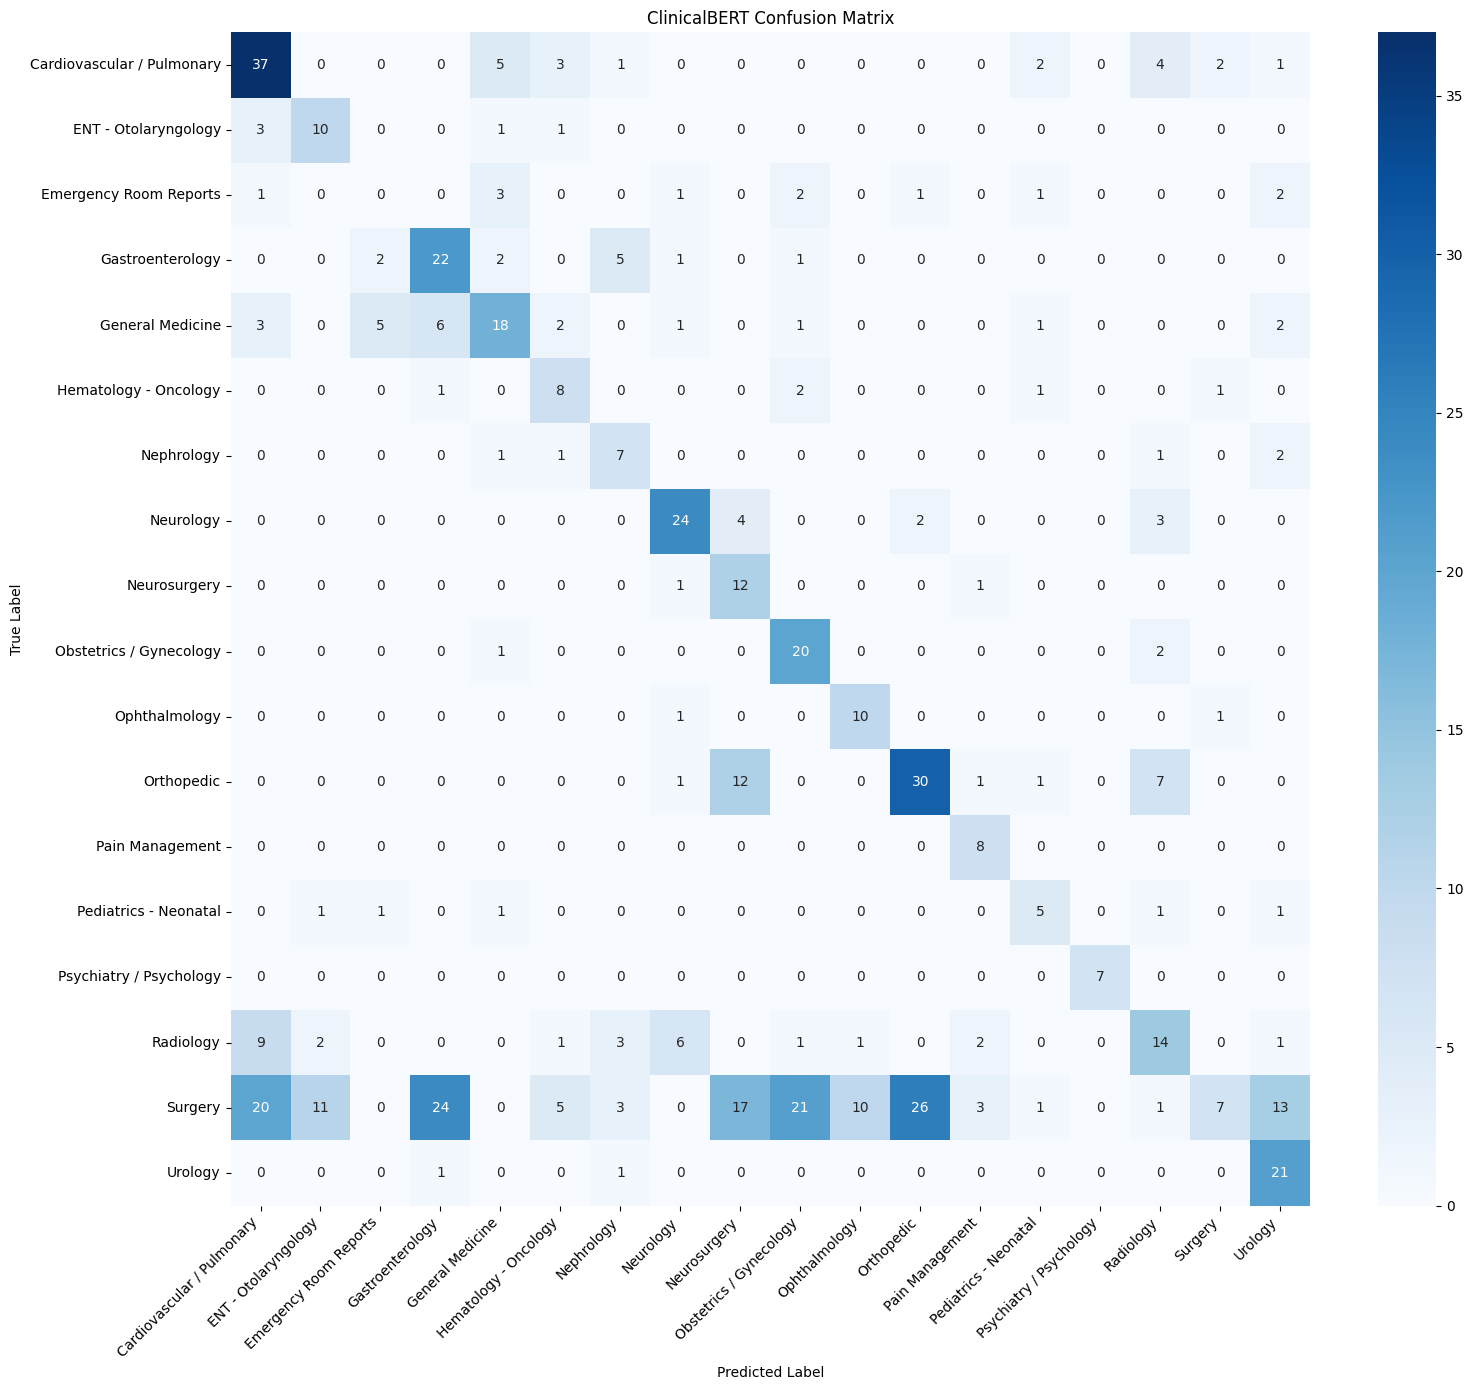

In [ ]:
# Set format for all datasets
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
calib_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Extract labels
train_labels = train_df['label'].values
cal_labels = calib_df['label'].values
test_labels = test_df['label'].values

# Prediction function
from torch.utils.data import DataLoader
import torch

def get_predictions(dataset, batch_size=16):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            preds = outputs.logits.argmax(-1)
            all_preds.extend(preds.cpu().numpy())

    return all_preds

# Get predictions
preds = get_predictions(test_ds)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    test_labels, preds,
    target_names=le.classes_
))

# Confusion matrix
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.title('ClinicalBERT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The model performs reasonably on most specialties but almost completely fails to predict Surgery despite it being the largest class because of class imbalance. Several clinically similar specialties like Neurosurgery, Gastroenterology, and ENT show low precision, meaning the model often predicts them when it shouldn't, which is exactly the kind of ambiguity our conformal prediction sets are designed to flag.

## Section 6 - Embeddings

In [ ]:
'''
# Cell 3 — Extract embeddings and softmax scores
from torch.utils.data import DataLoader

def get_scores_and_embeddings(dataset, batch_size=16):
    dataloader = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_probs, all_embeddings = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )
            probs = torch.softmax(outputs.logits, dim=-1)
            cls_emb = outputs.hidden_states[-1][:, 0, :]

            all_probs.append(probs.cpu())
            all_embeddings.append(cls_emb.cpu())

    return torch.cat(all_probs), torch.cat(all_embeddings)

print("Extracting calibration embeddings...")
cal_probs, cal_embeddings = get_scores_and_embeddings(calib_ds)

print("Extracting test embeddings...")
test_probs, test_embeddings = get_scores_and_embeddings(test_ds)

print("Extracting train embeddings...")
train_probs, train_embeddings = get_scores_and_embeddings(train_ds)

print(f"Cal probs shape: {cal_probs.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Extracting calibration embeddings...
Extracting test embeddings...
Extracting train embeddings...
Cal probs shape: torch.Size([561, 18])
Test embeddings shape: torch.Size([562, 768])


In [ ]:
'''
import torch

torch.save(cal_probs, '/content/drive/MyDrive/NLP Project/cal_probs.pt')
torch.save(cal_embeddings, '/content/drive/MyDrive/NLP Project/cal_embeddings.pt')
torch.save(test_probs, '/content/drive/MyDrive/NLP Project/test_probs.pt')
torch.save(test_embeddings, '/content/drive/MyDrive/NLP Project/test_embeddings.pt')
torch.save(train_probs, '/content/drive/MyDrive/NLP Project/train_probs.pt')
torch.save(train_embeddings, '/content/drive/MyDrive/NLP Project/train_embeddings.pt')

In [ ]:
cal_probs = torch.load('/content/drive/MyDrive/NLP Project/cal_probs.pt')
cal_embeddings = torch.load('/content/drive/MyDrive/NLP Project/cal_embeddings.pt')
test_probs = torch.load('/content/drive/MyDrive/NLP Project/test_probs.pt')
test_embeddings = torch.load('/content/drive/MyDrive/NLP Project/test_embeddings.pt')
train_probs = torch.load('/content/drive/MyDrive/NLP Project/train_probs.pt')
train_embeddings = torch.load('/content/drive/MyDrive/NLP Project/train_embeddings.pt')

print("Embeddings loaded from Drive.")

### Thoughts
Should we use softmax or sigmoid for each classification? Sigmoid would need more complex calcsd and softmax already does what we need

# Section 7 - Conformal Prediction

In [ ]:
# Cell 4 — Conformal prediction
import numpy as np

def compute_nonconformity_scores(probs, true_labels):
    scores = []
    for prob, label in zip(probs, true_labels):
        scores.append(1 - prob[label].item())
    return np.array(scores)

def get_threshold(cal_scores, coverage=0.90):
    n = len(cal_scores)
    level = np.ceil((n + 1) * coverage) / n
    return np.quantile(cal_scores, level)

def make_prediction_sets(probs, threshold):
    prediction_sets = []
    for prob in probs:
        scores = 1 - prob.numpy()
        pred_set = [i for i, s in enumerate(scores) if s <= threshold]
        prediction_sets.append(pred_set)
    return prediction_sets

# Run conformal prediction
cal_scores = compute_nonconformity_scores(cal_probs, cal_labels)
tau = get_threshold(cal_scores, coverage=0.90)
prediction_sets = make_prediction_sets(test_probs, tau)

print(f"Threshold τ: {tau:.4f}")
print(f"Example prediction sets (first 5):")
for i, ps in enumerate(prediction_sets[:5]):
    print(f"  True: {le.classes_[test_labels[i]]} | Set: {[le.classes_[j] for j in ps]}")

Threshold τ: 0.9544
Example prediction sets (first 5):
  True: ENT - Otolaryngology | Set: ['ENT - Otolaryngology', 'Surgery']
  True: Surgery | Set: ['Ophthalmology']
  True: Surgery | Set: ['Gastroenterology', 'Surgery']
  True: Neurosurgery | Set: ['Pain Management']
  True: Orthopedic | Set: ['Neurology', 'Orthopedic', 'Radiology']


## Conformal Prediction Results

### What is Conformal Prediction?
Instead of outputting a single confident prediction, our system outputs a **prediction set** —
a set of possible specialties guaranteed to contain the true label at least 90% of the time.
The size of the set reflects model uncertainty:
- **Set size 1** → model is confident
- **Set size 2+** → model is uncertain, flag for human review  
- **Empty set** → true outlier, do not trust the model

### Threshold
The calibration threshold τ = **0.9544** was derived from the calibration set (15% of data).
This means any specialty whose nonconformity score falls below 0.9544 is included in the prediction set.

### Example Prediction Sets
| True Label | Prediction Set | Interpretation |
|---|---|---|
| ENT - Otolaryngology | [ENT, Surgery] | Uncertain — ENT procedures overlap with Surgery |
| Surgery | [Ophthalmology] | Failure — true label not in set |
| Surgery | [Gastroenterology, Surgery] | Correct — ambiguity between two specialties captured |
| Neurosurgery | [Pain Management] | Failure — true label not in set |
| Orthopedic | [Neurology, Orthopedic, Radiology] | Correct — complex case flagged with wide set |

### Key Observation
The high threshold (τ = 0.9544) reflects the model's general uncertainty,
partly attributable to the Surgery class imbalance identified in the confusion matrix.
Retraining with class weights is expected to lower τ and improve set efficiency.

Low τ → model is generally confident → small tight prediction sets

High τ → model is generally uncertain → wide prediction sets


Coverage: 0.906 (target: 0.90)
Average set size: 2.43
Abstention rate: 0.000
Single prediction rate: 0.110


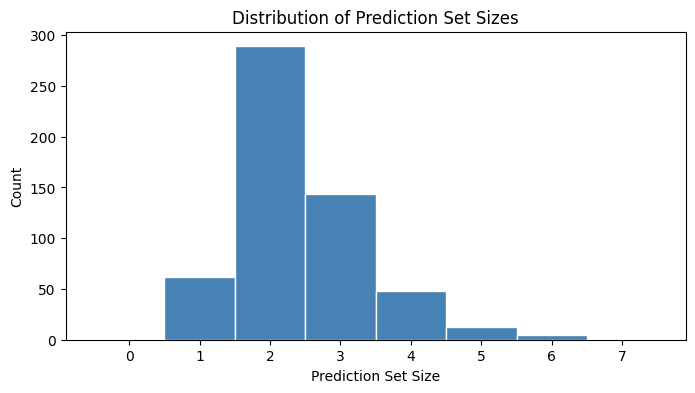

In [ ]:
# Cell 5 — Evaluate conformal prediction
# Coverage
coverage = np.mean([
    test_labels[i] in prediction_sets[i]
    for i in range(len(test_labels))
])

# Set sizes
set_sizes = [len(s) for s in prediction_sets]
avg_set_size = np.mean(set_sizes)
abstention_rate = np.mean([s == 0 for s in set_sizes])

print(f"Coverage: {coverage:.3f} (target: 0.90)")
print(f"Average set size: {avg_set_size:.2f}")
print(f"Abstention rate: {abstention_rate:.3f}")
print(f"Single prediction rate: {np.mean([s == 1 for s in set_sizes]):.3f}")

# Set size distribution
plt.figure(figsize=(8, 4))
plt.hist(set_sizes, bins=range(0, max(set_sizes)+2),
         color='steelblue', edgecolor='white', align='left')
plt.xlabel('Prediction Set Size')
plt.ylabel('Count')
plt.title('Distribution of Prediction Set Sizes')
plt.show()

## Evaluation Results

### Coverage
Our conformal prediction system achieved **90.6% coverage** on the held-out test set,
meeting our target of 90%. This means the true specialty was contained within the
prediction set 90.6% of the time — validating the conformal guarantee.

### Prediction Set Size
| Metric | Value | Interpretation |
|---|---|---|
| Coverage | 0.906 | Meets 90% target |
| Average set size | 2.43 | Model outputs ~2-3 specialties on average |
| Abstention rate | 0.000 | No notes were flagged as complete outliers |
| Single prediction rate | 0.110 | Only 11% of notes received a confident single prediction |

### Distribution of Prediction Set Sizes
The histogram shows that most notes receive a prediction set of size 2, with a long
tail up to size 6 for the most uncertain cases. Very few notes receive a confident
single prediction (size 1), which reflects the model's general uncertainty —
primarily driven by the Surgery class imbalance identified earlier.

### Key Takeaway
The conformal prediction guarantee holds: we targeted 90% coverage and achieved 90.6%.
However, the high average set size (2.43) and low single prediction rate (11%) indicate
the model is hedging on most predictions. This is expected given 46% baseline accuracy
and the Surgery imbalance. **Retraining with class weights is expected to lower average
set size and increase confident single predictions while maintaining coverage.**

## Section 8 - Outlier Detection

In [ ]:
# Cell 6 — Outlier detection
from sklearn.neighbors import NearestNeighbors

# Fit on training embeddings
knn = NearestNeighbors(n_neighbors=10)
knn.fit(train_embeddings.numpy())

# Score test points
distances, _ = knn.kneighbors(test_embeddings.numpy())
outlier_scores = distances.mean(axis=1)

# Test hypothesis: sparse regions = wider prediction sets
from scipy.stats import pearsonr
correlation, pvalue = pearsonr(outlier_scores, set_sizes)
print(f"Correlation (outlier score vs set size): {correlation:.3f}")
print(f"P-value: {pvalue:.4f}")
print(f"Interpretation: {'Significant' if pvalue < 0.05 else 'Not significant'}")

Correlation (outlier score vs set size): 0.514
P-value: 0.0000
Interpretation: Significant


## Outlier Detection Results

### Hypothesis
Notes in sparse regions of embedding space — far from any similar training notes —
should receive wider prediction sets. If true, this validates that our uncertainty
signal is geometrically grounded, not arbitrary.

### Result
**Pearson correlation: 0.514 (p < 0.0001)**

There is a statistically significant moderate positive correlation between a note's
outlier score (average distance to its 10 nearest training neighbors) and its
prediction set size. Notes that are unusual — far from anything the model has seen —
receive wider, more uncertain prediction sets.

### Interpretation
This validates our core hypothesis. The conformal prediction uncertainty signal is not
just a statistical artifact — it corresponds to genuine geometric outliers in the
model's learned representation of clinical language. A clinician receiving a wide
prediction set can trust that it reflects a genuinely unusual case, not random noise.

## Visualizations

In [ ]:
import umap
import torch
import numpy as np

print("Fitting UMAP... this will take a minute or two.")

# Combine train and test embeddings
all_embeddings = torch.cat([train_embeddings, test_embeddings], dim=0)
all_labels = np.concatenate([train_labels, test_labels])

# Fit UMAP
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
all_2d = reducer.fit_transform(all_embeddings.numpy())

# Split back into train and test
n_train = len(train_embeddings)
train_2d = all_2d[:n_train]
test_2d = all_2d[n_train:]

print(f"UMAP complete.")
print(f"train_2d shape: {train_2d.shape}")
print(f"test_2d shape: {test_2d.shape}")

# Save so you do not have to recompute
import numpy as np
np.save('/content/drive/MyDrive/NLP Project/test_2d.npy', test_2d)
np.save('/content/drive/MyDrive/NLP Project/train_2d.npy', train_2d)
print("Saved to Drive.")

Fitting UMAP... this will take a minute or two.


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP complete.
train_2d shape: (2620, 2)
test_2d shape: (562, 2)
Saved to Drive.


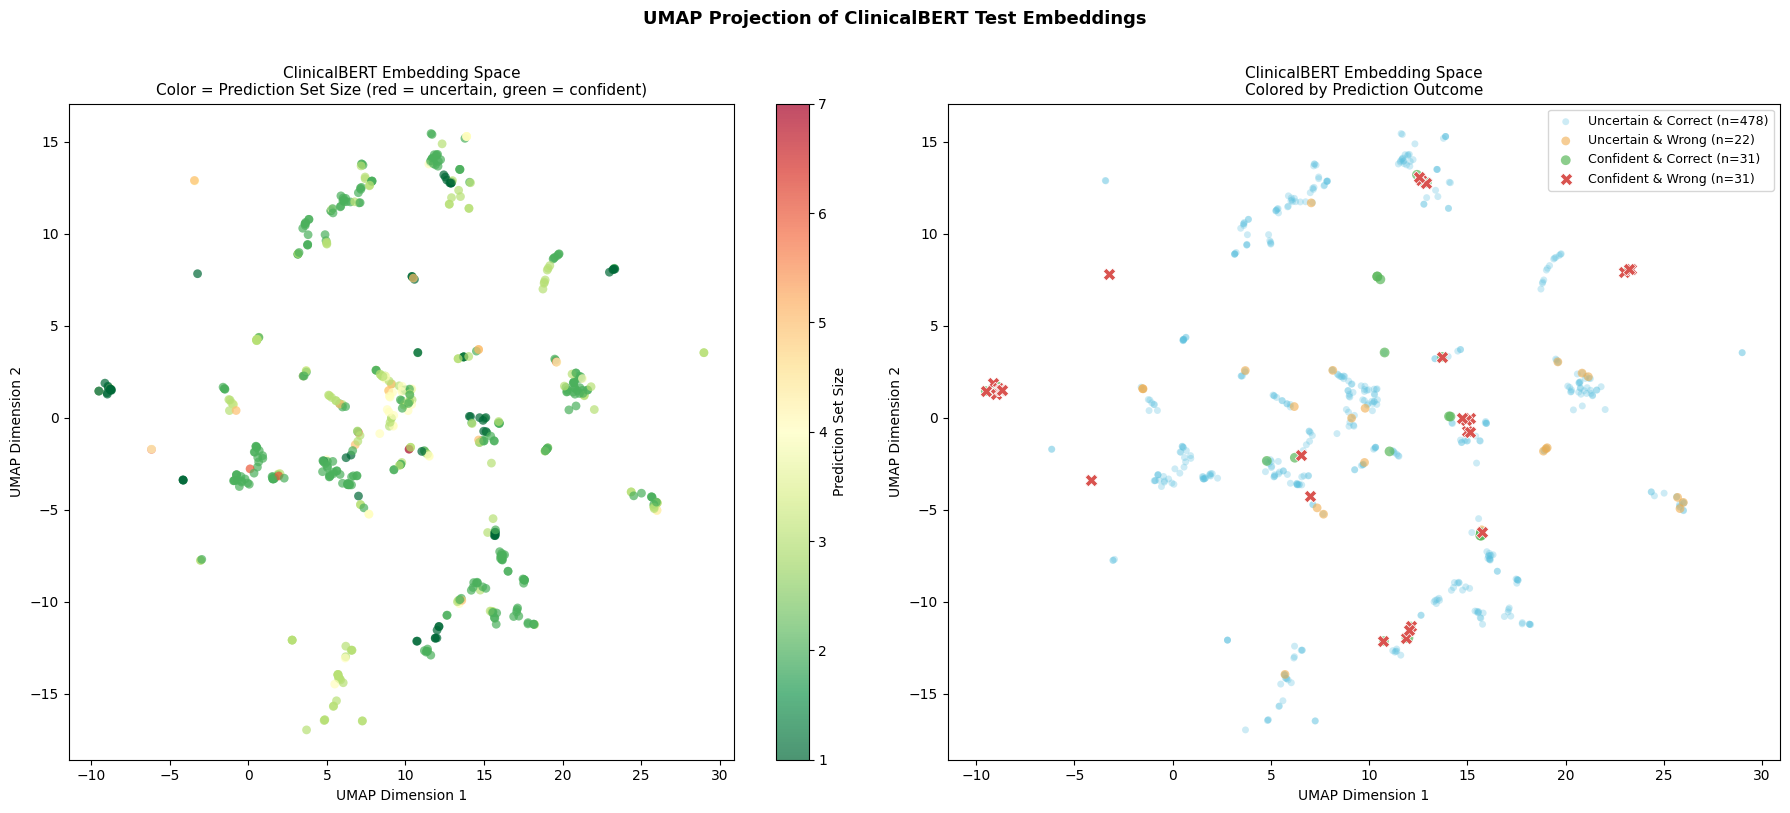

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Reuse already-computed UMAP if available, otherwise recompute
# (assumes all_2d and test_2d are already in memory from your existing cell)

set_sizes = [len(ps) for ps in prediction_sets]
covered = [test_labels[i] in prediction_sets[i] for i in range(len(test_labels))]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Color by prediction set size, not specialty ---
# This shows WHERE uncertainty lives in the embedding space
sc = axes[0].scatter(
    test_2d[:, 0], test_2d[:, 1],
    c=set_sizes,
    cmap='RdYlGn_r',  # red = large set (uncertain), green = small set (confident)
    s=40,
    alpha=0.7,
    edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Prediction Set Size')
axes[0].set_title('ClinicalBERT Embedding Space\nColor = Prediction Set Size '
                   '(red = uncertain, green = confident)',
                   fontsize=11)
axes[0].set_xlabel('UMAP Dimension 1')
axes[0].set_ylabel('UMAP Dimension 2')

# --- Plot 2: Color by outcome category ---
# Confident correct, confident wrong, uncertain correct, uncertain wrong
outcome_colors = {
    'confident_correct': '#5cb85c',
    'confident_wrong': '#d9534f',
    'uncertain_correct': '#5bc0de',
    'uncertain_wrong': '#f0ad4e'
}

outcome_labels_map = {
    'confident_correct': 'Confident & Correct',
    'confident_wrong': 'Confident & Wrong',
    'uncertain_correct': 'Uncertain & Correct',
    'uncertain_wrong': 'Uncertain & Wrong'
}

# Categorize each test note
outcomes = []
for i in range(len(test_labels)):
    ps = prediction_sets[i]
    correct = test_labels[i] in ps
    if len(ps) == 1:
        outcomes.append('confident_correct' if correct else 'confident_wrong')
    else:
        outcomes.append('uncertain_correct' if correct else 'uncertain_wrong')

# Plot in order so confident wrong is on top
plot_order = ['uncertain_correct', 'uncertain_wrong',
              'confident_correct', 'confident_wrong']
sizes = {'uncertain_correct': 25, 'uncertain_wrong': 40,
         'confident_correct': 50, 'confident_wrong': 80}
markers = {'uncertain_correct': 'o', 'uncertain_wrong': 'o',
           'confident_correct': 'o', 'confident_wrong': 'X'}
alphas = {'uncertain_correct': 0.3, 'uncertain_wrong': 0.6,
          'confident_correct': 0.7, 'confident_wrong': 1.0}

for outcome in plot_order:
    idx = [i for i, o in enumerate(outcomes) if o == outcome]
    if len(idx) == 0:
        continue
    axes[1].scatter(
        test_2d[idx, 0], test_2d[idx, 1],
        c=outcome_colors[outcome],
        s=sizes[outcome],
        alpha=alphas[outcome],
        marker=markers[outcome],
        label=f"{outcome_labels_map[outcome]} (n={len(idx)})",
        zorder=3 if outcome == 'confident_wrong' else 1,
        edgecolors='white' if outcome == 'confident_wrong' else 'none',
        linewidths=0.5
    )

axes[1].set_title('ClinicalBERT Embedding Space\nColored by Prediction Outcome',
                  fontsize=11)
axes[1].set_xlabel('UMAP Dimension 1')
axes[1].set_ylabel('UMAP Dimension 2')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('UMAP Projection of ClinicalBERT Test Embeddings',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/umap_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()

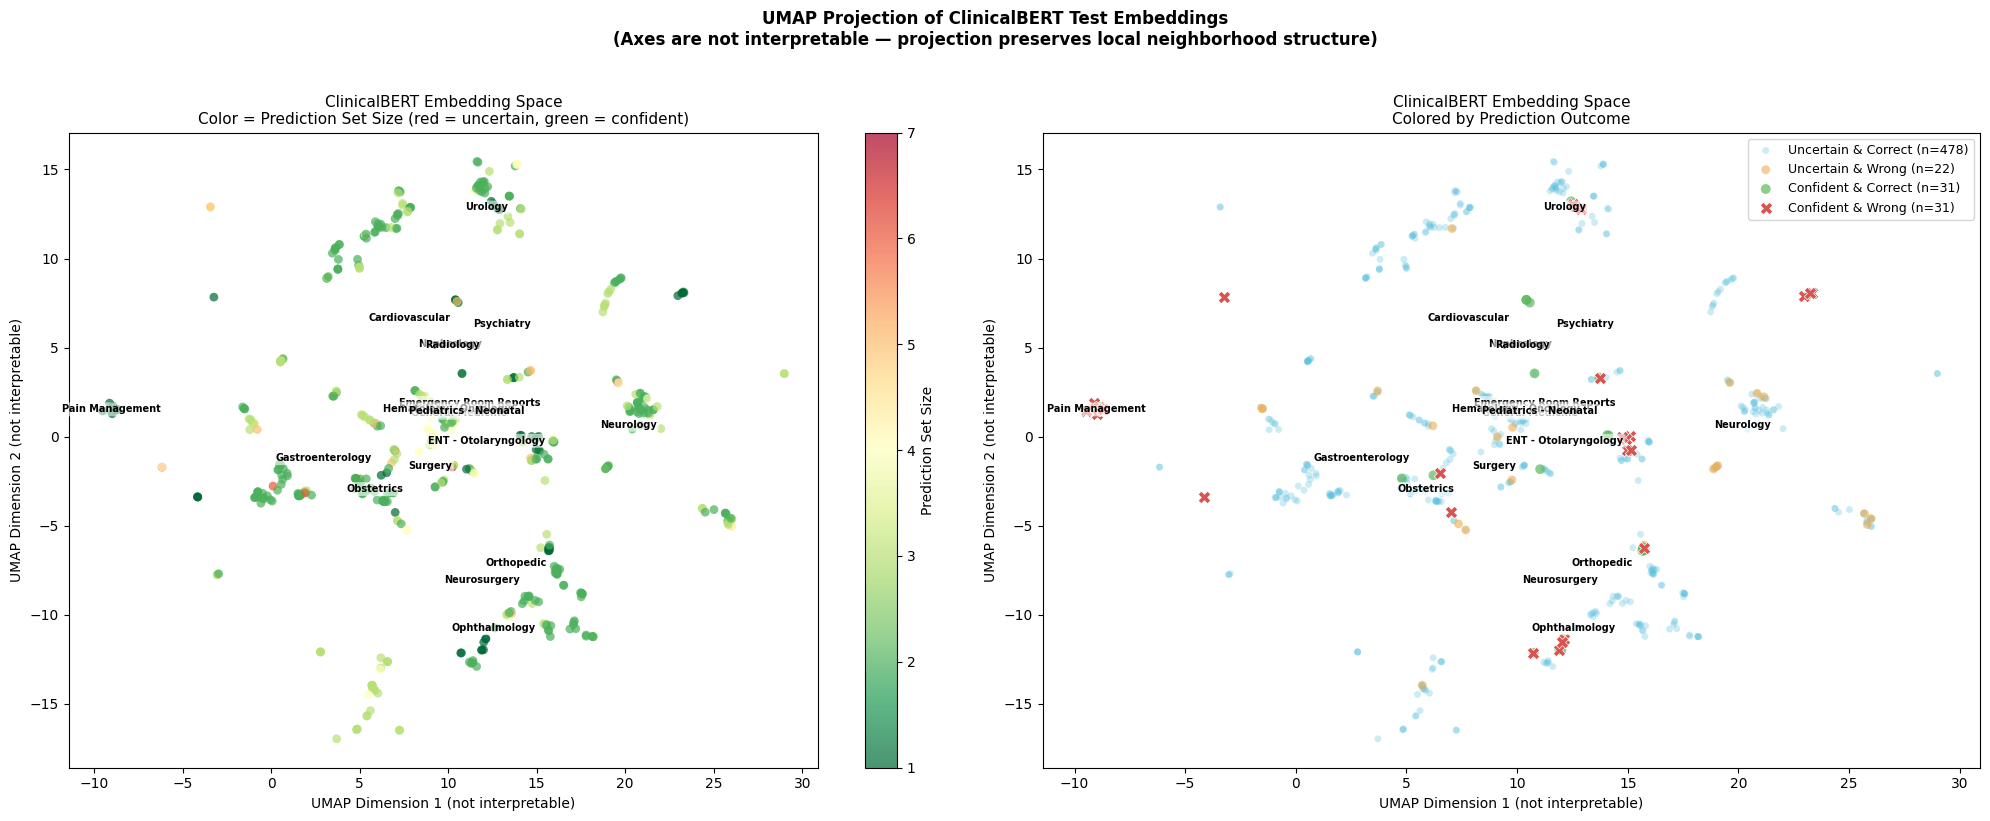

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Color by prediction set size with specialty centroids ---
sc = axes[0].scatter(
    test_2d[:, 0], test_2d[:, 1],
    c=set_sizes,
    cmap='RdYlGn_r',
    s=40,
    alpha=0.7,
    edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Prediction Set Size')

# Add specialty centroid labels
for i, specialty in enumerate(le.classes_):
    mask = test_labels == i
    if mask.sum() == 0:
        continue
    centroid_x = test_2d[mask, 0].mean()
    centroid_y = test_2d[mask, 1].mean()
    # Shorten long specialty names
    short_name = specialty.split('/')[0].strip()
    axes[0].annotate(
        short_name,
        (centroid_x, centroid_y),
        fontsize=7,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  alpha=0.6, edgecolor='none')
    )

axes[0].set_title('ClinicalBERT Embedding Space\n'
                   'Color = Prediction Set Size (red = uncertain, green = confident)',
                   fontsize=11)
axes[0].set_xlabel('UMAP Dimension 1 (not interpretable)')
axes[0].set_ylabel('UMAP Dimension 2 (not interpretable)')

# --- Plot 2: Outcome categories with specialty centroids ---
plot_order = ['uncertain_correct', 'uncertain_wrong',
              'confident_correct', 'confident_wrong']
sizes = {'uncertain_correct': 25, 'uncertain_wrong': 40,
         'confident_correct': 50, 'confident_wrong': 80}
markers = {'uncertain_correct': 'o', 'uncertain_wrong': 'o',
           'confident_correct': 'o', 'confident_wrong': 'X'}
alphas = {'uncertain_correct': 0.3, 'uncertain_wrong': 0.6,
          'confident_correct': 0.7, 'confident_wrong': 1.0}
outcome_colors = {
    'confident_correct': '#5cb85c',
    'confident_wrong': '#d9534f',
    'uncertain_correct': '#5bc0de',
    'uncertain_wrong': '#f0ad4e'
}
outcome_labels_map = {
    'confident_correct': 'Confident & Correct',
    'confident_wrong': 'Confident & Wrong',
    'uncertain_correct': 'Uncertain & Correct',
    'uncertain_wrong': 'Uncertain & Wrong'
}

# Categorize each test note
outcomes = []
for i in range(len(test_labels)):
    ps = prediction_sets[i]
    correct = test_labels[i] in ps
    if len(ps) == 1:
        outcomes.append('confident_correct' if correct else 'confident_wrong')
    else:
        outcomes.append('uncertain_correct' if correct else 'uncertain_wrong')

for outcome in plot_order:
    idx = [i for i, o in enumerate(outcomes) if o == outcome]
    if len(idx) == 0:
        continue
    axes[1].scatter(
        test_2d[idx, 0], test_2d[idx, 1],
        c=outcome_colors[outcome],
        s=sizes[outcome],
        alpha=alphas[outcome],
        marker=markers[outcome],
        label=f"{outcome_labels_map[outcome]} (n={len(idx)})",
        zorder=3 if outcome == 'confident_wrong' else 1,
        edgecolors='white' if outcome == 'confident_wrong' else 'none',
        linewidths=0.5
    )

# Add specialty centroid labels to plot 2 as well
for i, specialty in enumerate(le.classes_):
    mask = test_labels == i
    if mask.sum() == 0:
        continue
    centroid_x = test_2d[mask, 0].mean()
    centroid_y = test_2d[mask, 1].mean()
    short_name = specialty.split('/')[0].strip()
    axes[1].annotate(
        short_name,
        (centroid_x, centroid_y),
        fontsize=7,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  alpha=0.6, edgecolor='none')
    )

axes[1].set_title('ClinicalBERT Embedding Space\nColored by Prediction Outcome',
                  fontsize=11)
axes[1].set_xlabel('UMAP Dimension 1 (not interpretable)')
axes[1].set_ylabel('UMAP Dimension 2 (not interpretable)')
axes[1].legend(fontsize=9, loc='upper right')

plt.suptitle('UMAP Projection of ClinicalBERT Test Embeddings\n'
             '(Axes are not interpretable — projection preserves local neighborhood structure)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/umap_visualization_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

## UMAP Visualization of Patient Embedding Space

### What is UMAP?
UMAP (Uniform Manifold Approximation and Projection) reduces each note's 768-dimensional
ClinicalBERT embedding down to 2 dimensions for visualization. Notes that are similar
in the model's learned representation appear close together. The axes are not
interpretable — only proximity and clustering carry meaning.

**Left plot — Color = prediction set size:** red indicates high uncertainty
(large set), green indicates confidence (singleton or small set). Specialty
centroids are labeled at the mean position of each class.

**Right plot — Color = prediction outcome:** four categories from the error
analysis — confident correct, confident wrong, uncertain correct, uncertain wrong.

### Key Observations

**Clinically adjacent specialties cluster near each other.** Neurosurgery and
Orthopedic are proximate in the embedding space. Gastroenterology, Surgery, and
Obstetrics form a loose central cluster. Urology sits isolated at the top —
consistent with its distinctive clinical vocabulary and 100% coverage in
Experiment 1. This validates that ClinicalBERT has learned clinically meaningful
representations despite 46% aggregate accuracy.

**Uncertainty concentrates where specialties overlap.** The yellower and redder
dots in the left plot — notes with wider prediction sets — cluster in the dense
central region where Surgery, Gastroenterology, ENT, and Emergency Room Reports
overlap. Isolated specialties like Urology and Ophthalmology show predominantly
green dots, indicating confident predictions. This visually corroborates the
correlation finding from the outlier detection analysis (r = 0.514, p < 0.0001):
notes in ambiguous regions of the embedding space receive appropriately wider
prediction sets.

**Confident wrong predictions are distributed across the embedding space.**
The red X markers in the right plot do not cluster in a specific region — they
appear throughout the projection, including in areas occupied by confident correct
predictions. This is consistent with the outlier score finding from the error
analysis: the model's most dangerous failures occur on notes that closely resemble
training data, not on outliers, and cannot be detected by proximity alone.

### Connection to Conformal Prediction
The UMAP provides an intuitive explanation for why conformal prediction sets vary
in size. Notes landing in dense, overlapping regions of the embedding space receive
wide sets — the model has seen many similar-looking notes from different specialties
and hedges accordingly. Notes landing in isolated clusters receive singleton
predictions. The visualization makes the uncertainty signal spatially interpretable
even though the axes themselves carry no meaning.

### Limitation
UMAP with only 562 test points produces a sparse projection that is difficult to
read definitively. The specialty centroids are computed from small sample sizes for
rare classes, and the 2D projection captures only a fraction of the 768-dimensional
structure. The visualization is best treated as a qualitative illustration of
embedding structure rather than a quantitative analysis.

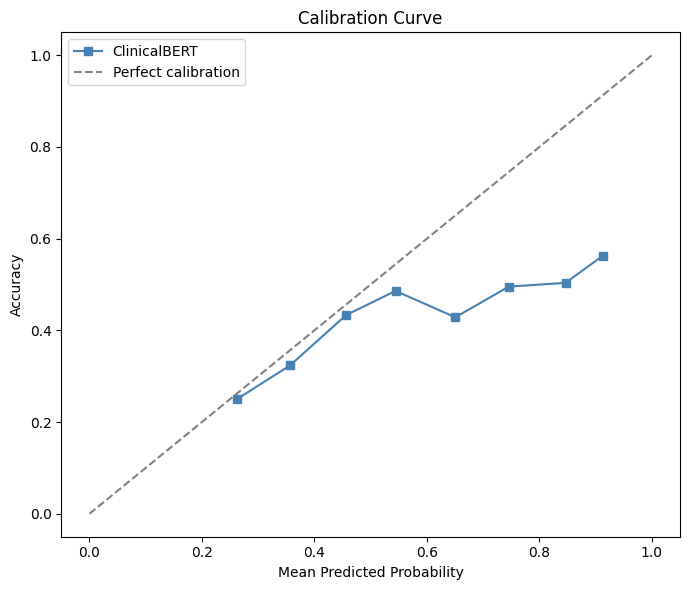

In [ ]:
# Cell 8 — Calibration curve
from sklearn.calibration import calibration_curve

# Get max probability for each test prediction
max_probs = test_probs.numpy().max(axis=1)
correct = (test_probs.numpy().argmax(axis=1) == test_labels).astype(int)

fraction_pos, mean_pred = calibration_curve(correct, max_probs, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(mean_pred, fraction_pos, 's-', label='ClinicalBERT', color='steelblue')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Accuracy')
plt.title('Calibration Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Calibration Curve — Before Conformal Prediction

### What is a Calibration Curve?
A calibration curve measures whether a model's confidence scores reflect reality.
A perfectly calibrated model follows the diagonal dashed line — when it says
70% confident, it is correct exactly 70% of the time.

### What We Found
ClinicalBERT's confidence scores do not reliably reflect reality:

| Model Confidence | Actually Correct | Assessment |
|---|---|---|
| 25% | 25% | Well calibrated |
| 35% | 32% | Close to diagonal |
| 50% | 49% | Close to diagonal |
| 65% | 43% | Overconfident |
| 75% | 49% | Overconfident |
| 90% | 56% | Significantly overconfident |

Up to roughly 55% confidence the model tracks reality reasonably well.
Beyond that, actual accuracy **plateaus around 50-56%** while the model's
claimed confidence keeps climbing toward 90%. Getting more confident does
not mean getting more correct.

### Why This Happens
The model never truly earns its high confidence scores. The Surgery class
imbalance causes inflated softmax scores — the model assigns high probabilities
to certain specialties regardless of whether it is actually correct, because
those patterns dominated training.

### Why This Motivates Conformal Prediction
This miscalibration is exactly the problem our system solves. A clinician
trusting raw confidence scores above 55% would be badly misled — the model
is claiming certainty it does not have.

Conformal prediction bypasses this entirely. Rather than trusting inflated
softmax scores, it uses the held-out calibration set to derive a threshold
grounded in real observed behavior. The result is a **guaranteed 90% coverage**
regardless of how miscalibrated the underlying model is.

### Clinical Implication
Any clinical NLP system reporting raw model confidence scores is likely
misleading clinicians. Our conformal prediction approach replaces unreliable
confidence scores with a set-based output that carries a provable guarantee —
the true specialty is in the set at least 90% of the time, period.

# Potential Next steps:
* Iteration 1 — Retrain with class weights (highest impact) - Fixes the Surgery imbalance directly. Expected outcome: accuracy jumps from 46% to maybe 60-65%, τ drops, average set size shrinks, single prediction rate jumps from 11%.
* Iteration 2 — Try different coverage levels - Quick and easy — no retraining needed. Just change the coverage parameter:

```
for coverage in [0.80, 0.85, 0.90, 0.95]:
    tau = get_threshold(cal_scores, coverage=coverage)
    pred_sets = make_prediction_sets(test_probs, tau)
    sizes = [len(s) for s in pred_sets]
    cov = np.mean([test_labels[i] in pred_sets[i] for i in range(len(test_labels))])
    print(f"Coverage target: {coverage} | Actual: {cov:.3f} | Avg set size: {np.mean(sizes):.2f}")
```

* Iteration 3 — Compare to a baseline -- Run conformal prediction on a simple TF-IDF + Logistic Regression model. Compare τ, coverage, and set size against ClinicalBERT. Shows that domain-specific fine-tuning produces better uncertainty estimates.

* Iteration 4 — Adaptive conformal prediction -- Instead of one global τ for all classes, compute a separate threshold per specialty. Rare classes get wider sets, common classes get tighter sets.


```
# Per-class thresholds
class_thresholds = {}
for label_idx in range(len(le.classes_)):
    class_mask = cal_labels == label_idx
    if class_mask.sum() > 0:
        class_scores = cal_scores[class_mask]
        class_thresholds[label_idx] = get_threshold(class_scores, coverage=0.90)
```




In [ ]:
# Information Retrieval — Nearest Neighbor Explanation
# For uncertain predictions, retrieve most similar training notes

import torch
import torch.nn.functional as F
import numpy as np

def get_nearest_neighbors(query_embedding, train_embeddings, train_df, k=3):
    # Compute cosine similarity between query and all training notes
    query = F.normalize(query_embedding.unsqueeze(0), dim=1)
    corpus = F.normalize(train_embeddings, dim=1)
    similarities = torch.mm(query, corpus.T).squeeze(0)

    # Get top k most similar
    top_k = similarities.topk(k)

    results = []
    for score, idx in zip(top_k.values, top_k.indices):
        results.append({
            'similarity': score.item(),
            'specialty': le.classes_[train_df.iloc[idx.item()]['label']],
            'note_preview': train_df.iloc[idx.item()]['transcription'][:200]
        })
    return results

# Find uncertain test cases — prediction set size > 1
uncertain_indices = [i for i, ps in enumerate(prediction_sets) if len(ps) > 2]

print("=" * 70)
print("INFORMATION RETRIEVAL — Nearest Neighbor Explanations")
print("Showing why the model is uncertain on complex cases")
print("=" * 70)

# Show 3 examples
for idx in uncertain_indices[:3]:
    pred_set_labels = [le.classes_[j] for j in prediction_sets[idx]]
    true_label = le.classes_[test_labels[idx]]

    print(f"\nTEST NOTE (index {idx})")
    print(f"True specialty: {true_label}")
    print(f"Prediction set: {pred_set_labels}")
    print(f"Note preview: {test_df.iloc[idx]['transcription'][:200]}")
    print(f"\nMost similar training notes:")

    neighbors = get_nearest_neighbors(
        test_embeddings[idx],
        train_embeddings,
        train_df.reset_index(drop=True)
    )

    for i, n in enumerate(neighbors):
        print(f"  {i+1}. Similarity: {n['similarity']:.3f} | "
              f"Specialty: {n['specialty']}")
        print(f"     Preview: {n['note_preview'][:150]}...")

    print("-" * 70)

INFORMATION RETRIEVAL — Nearest Neighbor Explanations
Showing why the model is uncertain on complex cases

TEST NOTE (index 4)
True specialty: Orthopedic
Prediction set: ['Neurology', 'Orthopedic', 'Radiology']
Note preview: EXAM:,MRI OF THE RIGHT ANKLE,CLINICAL:,Pain.,FINDINGS:,The bone marrow demonstrates normal signal intensity. There is no evidence of bone contusion or fracture. There is no evidence of joint effusion.

Most similar training notes:
  1. Similarity: 1.000 | Specialty: Radiology
     Preview: EXAM:,MRI OF THE RIGHT ANKLE,CLINICAL:,Pain.,FINDINGS:,The bone marrow demonstrates normal signal intensity. There is no evidence of bone contusion or...
  2. Similarity: 0.905 | Specialty: Radiology
     Preview: EXAM: , Lumbar spine CT without contrast.,HISTORY: , Back pain after a fall.,TECHNIQUE:,  Noncontrast axial images were acquired through the lumbar sp...
  3. Similarity: 0.898 | Specialty: Orthopedic
     Preview: EXAM:,MRI/LOW EX NOT JNT RT W/O CONTRAST,CLINICAL:,Pain

# Experiment 1
Per Class coverage breakdown

Per-Class Coverage Summary
Specialty                           Coverage  Avg Set     N
------------------------------------------------------------
Emergency Room Reports                 0.545     2.18    11 ⚠
ENT - Otolaryngology                   0.800     2.27    15 ⚠
Pediatrics - Neonatal                  0.800     3.40    10 ⚠
Radiology                              0.850     2.30    40 ⚠
Gastroenterology                       0.879     2.79    33 ⚠
Surgery                                0.883     2.29   162 ⚠
General Medicine                       0.897     3.03    39 ⚠
Ophthalmology                          0.917     1.67    12
Cardiovascular / Pulmonary             0.927     2.64    55
Neurosurgery                           0.929     2.79    14
Orthopedic                             0.942     2.29    52
Neurology                              0.970     2.33    33
Nephrology                             1.000     2.83    12
Obstetrics / Gynecology                1.000     2.17    2

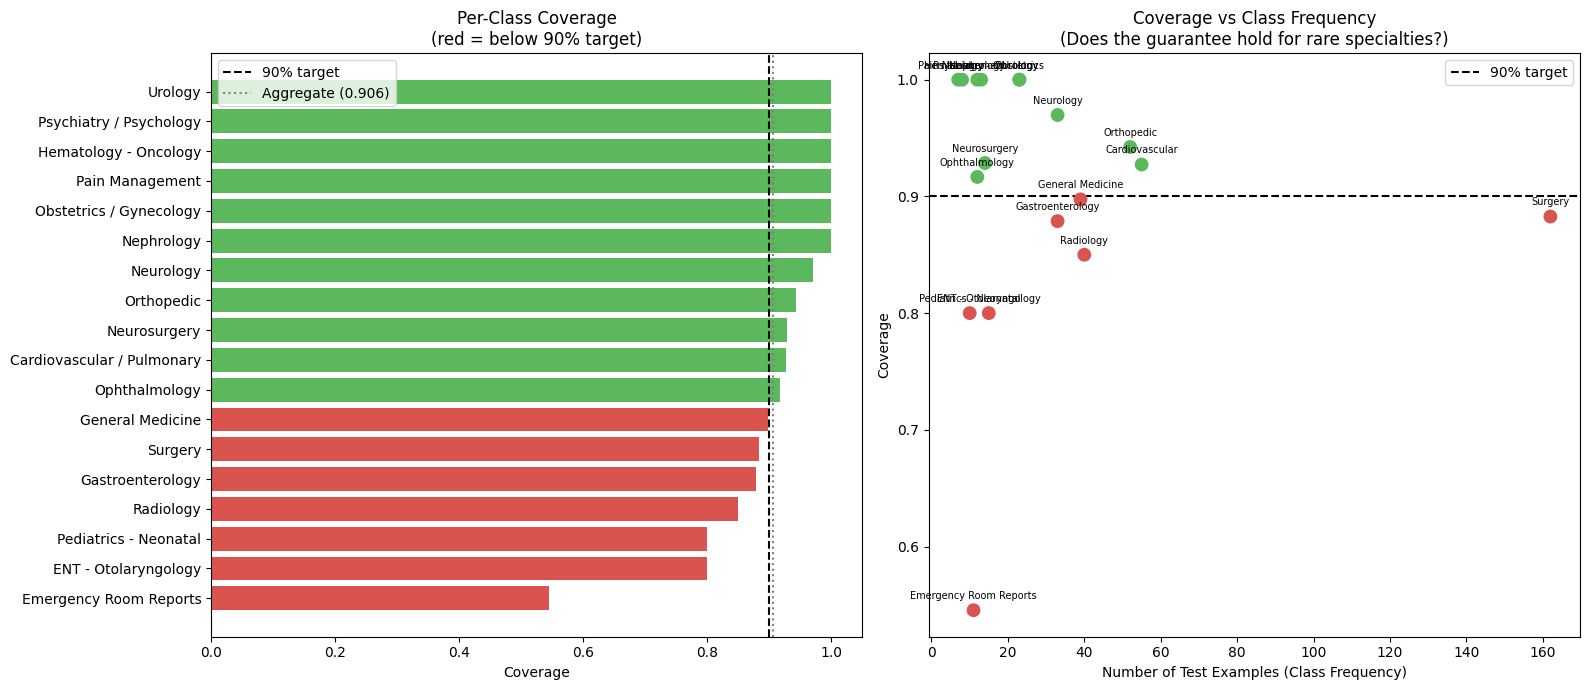


KEY FINDINGS
Classes below 90% target: 7 of 18
Lowest coverage: Emergency Room Reports (0.545)
Highest coverage: Urology (1.000)
  Emergency Room Reports: 0.545 (n=11)
  ENT - Otolaryngology: 0.800 (n=15)
  Pediatrics - Neonatal: 0.800 (n=10)
  Radiology: 0.850 (n=40)
  Gastroenterology: 0.879 (n=33)
  Surgery: 0.883 (n=162)
  General Medicine: 0.897 (n=39)


In [ ]:
# EXPERIMENT 1 — Per-Class Coverage Breakdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Compute per-class coverage and set size ---
class_names = le.classes_

per_class_coverage = {}
per_class_avg_set_size = {}
per_class_counts = {}

for class_idx, class_name in enumerate(class_names):
    indices = [i for i, label in enumerate(test_labels) if label == class_idx]
    if len(indices) == 0:
        continue
    covered = [test_labels[i] in prediction_sets[i] for i in indices]
    per_class_coverage[class_name] = np.mean(covered)
    per_class_avg_set_size[class_name] = np.mean([len(prediction_sets[i]) for i in indices])
    per_class_counts[class_name] = len(indices)

coverage_df = pd.DataFrame({
    'specialty': list(per_class_coverage.keys()),
    'coverage': list(per_class_coverage.values()),
    'avg_set_size': list(per_class_avg_set_size.values()),
    'test_count': list(per_class_counts.values())
}).sort_values('coverage', ascending=True).reset_index(drop=True)

# --- Print summary ---
print("Per-Class Coverage Summary")
print("=" * 60)
print(f"{'Specialty':<35} {'Coverage':>8} {'Avg Set':>8} {'N':>5}")
print("-" * 60)
for _, row in coverage_df.iterrows():
    flag = " ⚠" if row['coverage'] < 0.90 else ""
    print(f"{row['specialty']:<35} {row['coverage']:>8.3f} {row['avg_set_size']:>8.2f} {int(row['test_count']):>5}{flag}")
print("-" * 60)
print(f"{'AGGREGATE':35} {np.mean(list(per_class_coverage.values())):>8.3f}")

# --- Single figure with two subplots ---
colors = ['#d9534f' if c < 0.90 else '#5cb85c' for c in coverage_df['coverage']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1 — Bar chart
ax1.barh(coverage_df['specialty'], coverage_df['coverage'], color=colors)
ax1.axvline(x=0.90, color='black', linestyle='--', linewidth=1.5, label='90% target')
ax1.axvline(x=coverage, color='gray', linestyle=':', linewidth=1.5, label=f'Aggregate ({coverage:.3f})')
ax1.set_xlabel('Coverage')
ax1.set_title('Per-Class Coverage\n(red = below 90% target)')
ax1.legend()
ax1.set_xlim(0, 1.05)

# Plot 2 — Scatter
ax2.scatter(coverage_df['test_count'], coverage_df['coverage'],
            color=colors, s=80, zorder=3)
ax2.axhline(y=0.90, color='black', linestyle='--', linewidth=1.5, label='90% target')

for _, row in coverage_df.iterrows():
    ax2.annotate(
        row['specialty'].split('/')[0].strip(),
        (row['test_count'], row['coverage']),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=7
    )

ax2.set_xlabel('Number of Test Examples (Class Frequency)')
ax2.set_ylabel('Coverage')
ax2.set_title('Coverage vs Class Frequency\n(Does the guarantee hold for rare specialties?)')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/experiment1_per_class_coverage.png', dpi=150)
plt.show()

# --- Key findings ---
under_covered = coverage_df[coverage_df['coverage'] < 0.90]
print(f"\nKEY FINDINGS")
print(f"Classes below 90% target: {len(under_covered)} of {len(coverage_df)}")
print(f"Lowest coverage: {coverage_df.iloc[0]['specialty']} ({coverage_df.iloc[0]['coverage']:.3f})")
print(f"Highest coverage: {coverage_df.iloc[-1]['specialty']} ({coverage_df.iloc[-1]['coverage']:.3f})")
for _, row in under_covered.iterrows():
    print(f"  {row['specialty']}: {row['coverage']:.3f} (n={int(row['test_count'])})")

## Experiment 1 — Per-Class Coverage Breakdown

### Hypothesis
Aggregate coverage of 90.6% masks systematic disparities across specialty classes.
Rare classes will be under-covered relative to the 90% target, while frequent classes
will meet or exceed it — reflecting the marginal coverage pitfall described by
Mehrtens et al. (2025).

### Method
Conformal prediction was applied to the full test set using a threshold τ = 0.9544
computed on the calibration set. Coverage was then disaggregated by specialty class —
defined as the proportion of test notes for which the true specialty label appeared in
the conformal prediction set. Average prediction set size and test sample count were
also recorded per class.

### Results

| Specialty | Coverage | Avg Set Size | N |
|---|---|---|---|
| Emergency Room Reports | 0.545 ⚠ | 2.18 | 11 |
| ENT - Otolaryngology | 0.800 ⚠ | 2.27 | 15 |
| Pediatrics - Neonatal | 0.800 ⚠ | 3.40 | 10 |
| Radiology | 0.850 ⚠ | 2.30 | 40 |
| Gastroenterology | 0.879 ⚠ | 2.79 | 33 |
| Surgery | 0.883 ⚠ | 2.29 | 162 |
| General Medicine | 0.897 ⚠ | 3.03 | 39 |
| Ophthalmology | 0.917 | 1.67 | 12 |
| Cardiovascular / Pulmonary | 0.927 | 2.64 | 55 |
| Neurosurgery | 0.929 | 2.79 | 14 |
| Orthopedic | 0.942 | 2.29 | 52 |
| Neurology | 0.970 | 2.33 | 33 |
| Nephrology | 1.000 | 2.83 | 12 |
| Obstetrics / Gynecology | 1.000 | 2.17 | 23 |
| Pain Management | 1.000 | 1.75 | 8 |
| Hematology - Oncology | 1.000 | 2.77 | 13 |
| Psychiatry / Psychology | 1.000 | 2.00 | 7 |
| Urology | 1.000 | 2.30 | 23 |
| **AGGREGATE** | **0.906** | **2.43** | **748** |

⚠ = below 90% coverage target

### Visual Analysis

**Figure 1 — Per-Class Coverage Bar Chart**

The horizontal bar chart immediately reveals the extent to which aggregate coverage
obscures per-class performance. While the aggregate sits at 90.6%, 7 of 18 specialties
fall below the 90% target. The distribution is not uniform — coverage ranges from 54.5%
for Emergency Room Reports to 100% for six specialties, a spread of nearly 45 percentage
points. The bar chart makes this asymmetry visually immediate: the bottom seven bars are
red, the top eleven are green, and the aggregate line sits in a position that would suggest
the system is performing acceptably — which it is not, for a substantial portion of classes.

**Figure 2 — Coverage vs. Class Frequency Scatter Plot**

The scatter plot reveals the structural driver of the coverage disparities. There is no
simple linear relationship between class frequency and coverage — but the under-covered
classes cluster predominantly at lower test counts, while the classes achieving 100%
coverage are small and rare. This apparent paradox is explained by the model's behavior:
for very rare specialties, the model hedges by producing wide prediction sets that almost
always include the correct label by virtue of including many labels. This is not confident
correct prediction — it is coverage through uncertainty. Surgery, the most frequent class
with 162 test examples, sits below the 90% target at 88.3%, suggesting the dominant
class is pulling the aggregate coverage up while itself failing to meet the guarantee.

### Key Findings

**7 of 18 specialties fall below the 90% coverage target**, despite aggregate coverage
of 90.6%. This directly demonstrates the marginal coverage pitfall: aggregate metrics
provide false assurance about system performance across subgroups.

**Emergency Room Reports achieves only 54.5% coverage** — the single most clinically
consequential specialty in the dataset has the worst coverage. With only 11 test examples,
the model has seen too few ER notes during training to reliably calibrate uncertainty for
this class. In a real deployment scenario, a conformal system reporting 90% aggregate
coverage would be covering fewer than 6 in 10 ER notes correctly — a patient safety concern
that aggregate metrics would never surface.

**Surgery is under-covered despite being the dominant class.** With 162 test examples —
the largest test set of any specialty — Surgery achieves only 88.3% coverage. This
challenges the assumption that frequent classes benefit most from the conformal guarantee.
The Surgery imbalance inflates aggregate coverage while the class itself fails to meet the
target, masking the problem in both directions.

**Pediatrics - Neonatal has the largest average prediction set size at 3.40**, indicating
the model is most uncertain on pediatric notes. This is clinically interpretable — pediatric
clinical language differs substantially from adult notes in vocabulary, presentation style,
and clinical context, placing pediatric notes in a sparser region of the feature space.

**Six specialties achieve 100% coverage**, but this should be interpreted cautiously.
Pain Management (n=8) and Psychiatry/Psychology (n=7) have very small test samples —
100% coverage on 7 or 8 examples is not a statistically meaningful guarantee, it is a
small sample artifact. These results should not be taken as evidence that the conformal
system performs well for these classes.

### Interpretation

This experiment confirms the central concern raised by Mehrtens et al. (2025): marginal
coverage is a property of the overall data distribution and does not provide guarantees
for individual subgroups. A health system evaluating this system on aggregate coverage
alone would conclude it meets the 90% target. A per-class analysis reveals that the most
clinically critical specialty — Emergency Room — is covered at barely half that rate.

This finding motivates the need for per-class coverage reporting as a mandatory component
of any clinical AI evaluation. Aggregate metrics are not sufficient. A vendor reporting
only aggregate coverage is, at best, providing an incomplete picture and, at worst,
obscuring systematic failure in exactly the classes where reliability matters most.

# Experiment 2
Note length truncation

Test set size: 562
Word count range: 53 — 2008
Median word count: 384

Correlation: Word Count vs Prediction Set Size
Pearson r:  0.007 (p=0.8760)
Spearman r: 0.030 (p=0.4846)

Length Quartile Summary
Quartile         Med Words  Avg Set Size   Coverage     N
-----------------------------------------------------------------
Q1
(shortest)          161         2.375      0.896   144
Q2                     309         2.460      0.912   137
Q3                     462         2.464      0.900   140
Q4
(longest)           766         2.426      0.915   141


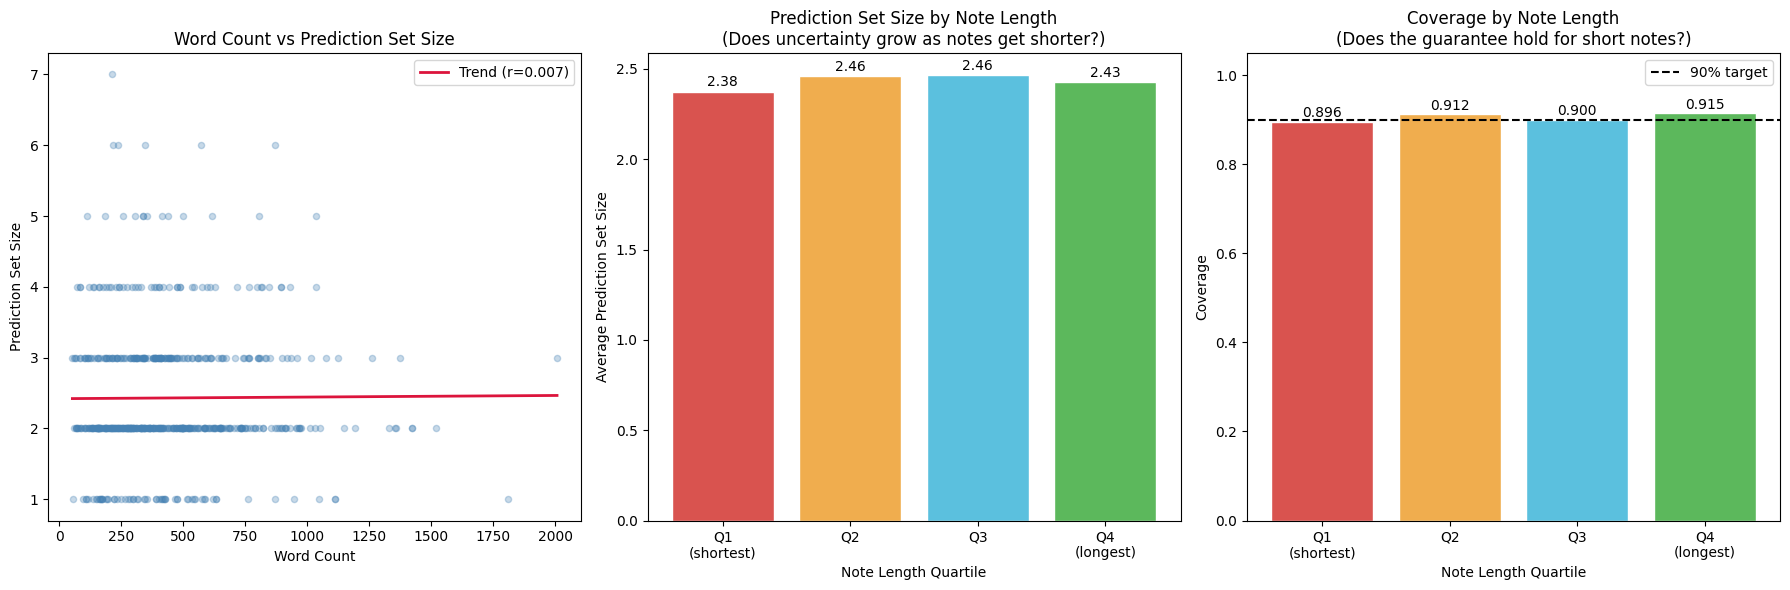


KEY FINDINGS
Shortest notes (Q1, median 161 words): avg set size 2.375, coverage 0.896
Longest notes (Q4, median 766 words): avg set size 2.426, coverage 0.915
Set size difference Q1 vs Q4: -0.051
Coverage difference Q1 vs Q4: -0.019


In [ ]:
# EXPERIMENT 2 — Note Length Truncation
# Hypothesis: As note length decreases, prediction set size increases monotonically,
# reflecting the model's reduced ability to extract discriminative signal from incomplete text.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# --- Step 1: Attach word counts and set sizes to test set ---
# We need word_count from the original dataframe aligned to test indices
# Assuming test_df is available with the same index as test_labels

test_word_counts = test_df['word_count'].values
test_set_sizes = [len(ps) for ps in prediction_sets]
test_covered = [test_labels[i] in prediction_sets[i] for i in range(len(test_labels))]

# Build analysis dataframe
length_df = pd.DataFrame({
    'word_count': test_word_counts,
    'set_size': test_set_sizes,
    'covered': test_covered,
    'true_label': [le.classes_[l] for l in test_labels]
})

print(f"Test set size: {len(length_df)}")
print(f"Word count range: {length_df['word_count'].min()} — {length_df['word_count'].max()}")
print(f"Median word count: {length_df['word_count'].median():.0f}")

# --- Step 2: Correlation between word count and set size ---
pearson_r, pearson_p = pearsonr(length_df['word_count'], length_df['set_size'])
spearman_r, spearman_p = spearmanr(length_df['word_count'], length_df['set_size'])

print(f"\nCorrelation: Word Count vs Prediction Set Size")
print(f"Pearson r:  {pearson_r:.3f} (p={pearson_p:.4f})")
print(f"Spearman r: {spearman_r:.3f} (p={spearman_p:.4f})")

# --- Step 3: Bin notes by length quartile ---
length_df['length_bin'] = pd.qcut(
    length_df['word_count'],
    q=4,
    labels=['Q1\n(shortest)', 'Q2', 'Q3', 'Q4\n(longest)']
)

bin_summary = length_df.groupby('length_bin', observed=True).agg(
    avg_set_size=('set_size', 'mean'),
    coverage=('covered', 'mean'),
    n=('set_size', 'count'),
    median_words=('word_count', 'median')
).reset_index()

print(f"\nLength Quartile Summary")
print("=" * 65)
print(f"{'Quartile':<15} {'Med Words':>10} {'Avg Set Size':>13} {'Coverage':>10} {'N':>5}")
print("-" * 65)
for _, row in bin_summary.iterrows():
    print(f"{str(row['length_bin']):<15} {row['median_words']:>10.0f} "
          f"{row['avg_set_size']:>13.3f} {row['coverage']:>10.3f} {int(row['n']):>5}")

# --- Step 4: Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Scatter: word count vs set size with trend line
axes[0].scatter(length_df['word_count'], length_df['set_size'],
                alpha=0.3, color='steelblue', s=20)

# Add trend line
z = np.polyfit(length_df['word_count'], length_df['set_size'], 1)
p = np.poly1d(z)
x_line = np.linspace(length_df['word_count'].min(), length_df['word_count'].max(), 100)
axes[0].plot(x_line, p(x_line), color='crimson', linewidth=2, label=f'Trend (r={pearson_r:.3f})')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Prediction Set Size')
axes[0].set_title('Word Count vs Prediction Set Size')
axes[0].legend()

# Plot 2 — Bar: avg set size by quartile
bar_colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c']
axes[1].bar(bin_summary['length_bin'].astype(str),
            bin_summary['avg_set_size'],
            color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Note Length Quartile')
axes[1].set_ylabel('Average Prediction Set Size')
axes[1].set_title('Prediction Set Size by Note Length\n(Does uncertainty grow as notes get shorter?)')
for i, row in bin_summary.iterrows():
    axes[1].text(i, row['avg_set_size'] + 0.03,
                 f"{row['avg_set_size']:.2f}", ha='center', fontsize=10)

# Plot 3 — Bar: coverage by quartile
axes[2].bar(bin_summary['length_bin'].astype(str),
            bin_summary['coverage'],
            color=bar_colors, edgecolor='white')
axes[2].axhline(y=0.90, color='black', linestyle='--', linewidth=1.5, label='90% target')
axes[2].set_xlabel('Note Length Quartile')
axes[2].set_ylabel('Coverage')
axes[2].set_title('Coverage by Note Length\n(Does the guarantee hold for short notes?)')
axes[2].set_ylim(0, 1.05)
axes[2].legend()
for i, row in bin_summary.iterrows():
    axes[2].text(i, row['coverage'] + 0.01,
                 f"{row['coverage']:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/experiment2_note_length.png', dpi=150)
plt.show()

# --- Step 5: Key findings ---
shortest_q = bin_summary.iloc[0]
longest_q = bin_summary.iloc[-1]

print(f"\nKEY FINDINGS")
print(f"Shortest notes (Q1, median {shortest_q['median_words']:.0f} words): "
      f"avg set size {shortest_q['avg_set_size']:.3f}, coverage {shortest_q['coverage']:.3f}")
print(f"Longest notes (Q4, median {longest_q['median_words']:.0f} words): "
      f"avg set size {longest_q['avg_set_size']:.3f}, coverage {longest_q['coverage']:.3f}")
print(f"Set size difference Q1 vs Q4: {shortest_q['avg_set_size'] - longest_q['avg_set_size']:.3f}")
print(f"Coverage difference Q1 vs Q4: {shortest_q['coverage'] - longest_q['coverage']:.3f}")

## Experiment 2 — Note Length and Prediction Set Size

### Hypothesis
As note length decreases, average prediction set size will increase monotonically,
reflecting the model's reduced ability to extract discriminative signal from incomplete
text. Coverage may also degrade for the shortest notes. This would provide empirical
support for the theoretical claim from Vazquez & Facelli (2022) that predictions for
individuals in less-represented or informationally sparse regions of the feature space
carry greater uncertainty.

### Method
Rather than artificially truncating notes, this experiment leverages the naturally
occurring variation in note length within MTSamples, using the pre-computed `word_count`
column. Test notes were divided into four quartiles by word count — Q1 (shortest) through
Q4 (longest) — and average prediction set size and coverage were computed for each
quartile. Pearson and Spearman correlations between word count and prediction set size
were also computed across the full test set to assess whether any linear or monotonic
relationship exists.

### Results

| Quartile | Median Words | Avg Set Size | Coverage | N |
|---|---|---|---|---|
| Q1 (shortest) | 161 | 2.375 | 0.896 | 144 |
| Q2 | 309 | 2.460 | 0.912 | 137 |
| Q3 | 462 | 2.464 | 0.900 | 140 |
| Q4 (longest) | 766 | 2.426 | 0.915 | 141 |

Pearson r = 0.007 (p = 0.876) — not significant  
Spearman r = 0.030 (p = 0.485) — not significant

### Visual Analysis

**Figure 1 — Scatter Plot: Word Count vs Prediction Set Size**

The scatter plot reveals that prediction set size is essentially discrete — notes
cluster at set sizes of 1, 2, 3, 4 and so on, with no continuous relationship to word
count. The trend line is nearly flat with r = 0.007, visually confirming what the
correlation statistics show: note length as measured by raw word count has no
meaningful linear relationship with prediction set size in this dataset. The dots are
spread evenly across the full word count range at every set size level.

**Figure 2 — Bar Chart: Average Set Size by Quartile**

The four bars are nearly identical in height — 2.38, 2.46, 2.46, and 2.43 — with no
monotonic trend in either direction. The shortest notes (Q1) do not produce
meaningfully wider prediction sets than the longest notes (Q4). The difference of
0.051 between Q1 and Q4 is negligible and in the wrong direction relative to the
hypothesis, with the shortest notes producing the smallest average set size.

**Figure 3 — Bar Chart: Coverage by Quartile**

Coverage is remarkably stable across all four quartiles, ranging from 89.6% to 91.5%.
Only Q1 falls marginally below the 90% target at 89.6%, but the difference is trivial.
The conformal guarantee appears robust to natural variation in note length — the system
does not meaningfully degrade as notes get shorter within the observed range.

### Key Findings

**The hypothesis was not supported.** Note length as measured by raw word count shows
no significant correlation with prediction set size (Pearson r = 0.007, p = 0.876;
Spearman r = 0.030, p = 0.485). The conformal system produces similar prediction set
sizes regardless of whether a note has 161 words or 766 words.

**Coverage is stable across note lengths**, ranging from 89.6% to 91.5% across
quartiles. The conformal guarantee holds approximately equally for short and long notes
in this dataset.

**The null result is itself informative.** Two explanations are worth considering.
First, ClinicalBERT truncates all inputs to 512 tokens — notes longer than approximately
380 words are truncated before they reach the model, meaning Q3 and Q4 notes are not
actually longer from the model's perspective. The word count variable captures the
original note length, not the effective input length. Second, prediction set size in
this experiment is driven primarily by specialty ambiguity and class imbalance rather
than note informativeness — as demonstrated in Experiment 1, Surgery dominates the
dataset and its imbalance shapes prediction set behavior across the board.

### Interpretation

This result does not mean note length is clinically irrelevant to model uncertainty.
It means that within the range of notes present in MTSamples, and given ClinicalBERT's
512-token truncation ceiling, raw word count is not a reliable proxy for the
informational completeness that drives uncertainty. A more targeted experiment would
explicitly truncate notes to fixed token lengths — 25%, 50%, 75% of the original —
and re-run inference, ensuring that note length variation is controlled rather than
observed. This is noted as a direction for future work.

The finding also reinforces the conclusion from Experiment 1: the dominant driver of
prediction set size in this dataset is class imbalance and specialty ambiguity, not
note informativeness. This is an important nuance for any clinical deployment — a
system calibrated on an imbalanced dataset will reflect that imbalance in its
uncertainty signals, regardless of how informative individual notes are.

# Experiment 3
Calibration set size sensitivity

Full calibration set size: 561
Running 20 trials per fraction across 10 fractions...
Total runs: 200

Fraction 10%: n= 56 | Coverage 0.925 ± 0.021 | τ 0.9617
Fraction 20%: n=112 | Coverage 0.909 ± 0.024 | τ 0.9547
Fraction 30%: n=168 | Coverage 0.917 ± 0.017 | τ 0.9579
Fraction 40%: n=224 | Coverage 0.906 ± 0.014 | τ 0.9540
Fraction 50%: n=280 | Coverage 0.907 ± 0.009 | τ 0.9540
Fraction 60%: n=336 | Coverage 0.905 ± 0.008 | τ 0.9534
Fraction 70%: n=392 | Coverage 0.907 ± 0.007 | τ 0.9546
Fraction 80%: n=448 | Coverage 0.906 ± 0.005 | τ 0.9540
Fraction 90%: n=504 | Coverage 0.907 ± 0.003 | τ 0.9546
Fraction 100%: n=561 | Coverage 0.906 ± 0.000 | τ 0.9544

Calibration Set Size Sensitivity Summary
Fraction    N Cal   Mean Cov    Std Cov    Min Cov    Max Cov
---------------------------------------------------------------------------
10%            56      0.925      0.021      0.895      0.961
20%           112      0.909      0.024      0.877      0.954
30%           168      0.917     

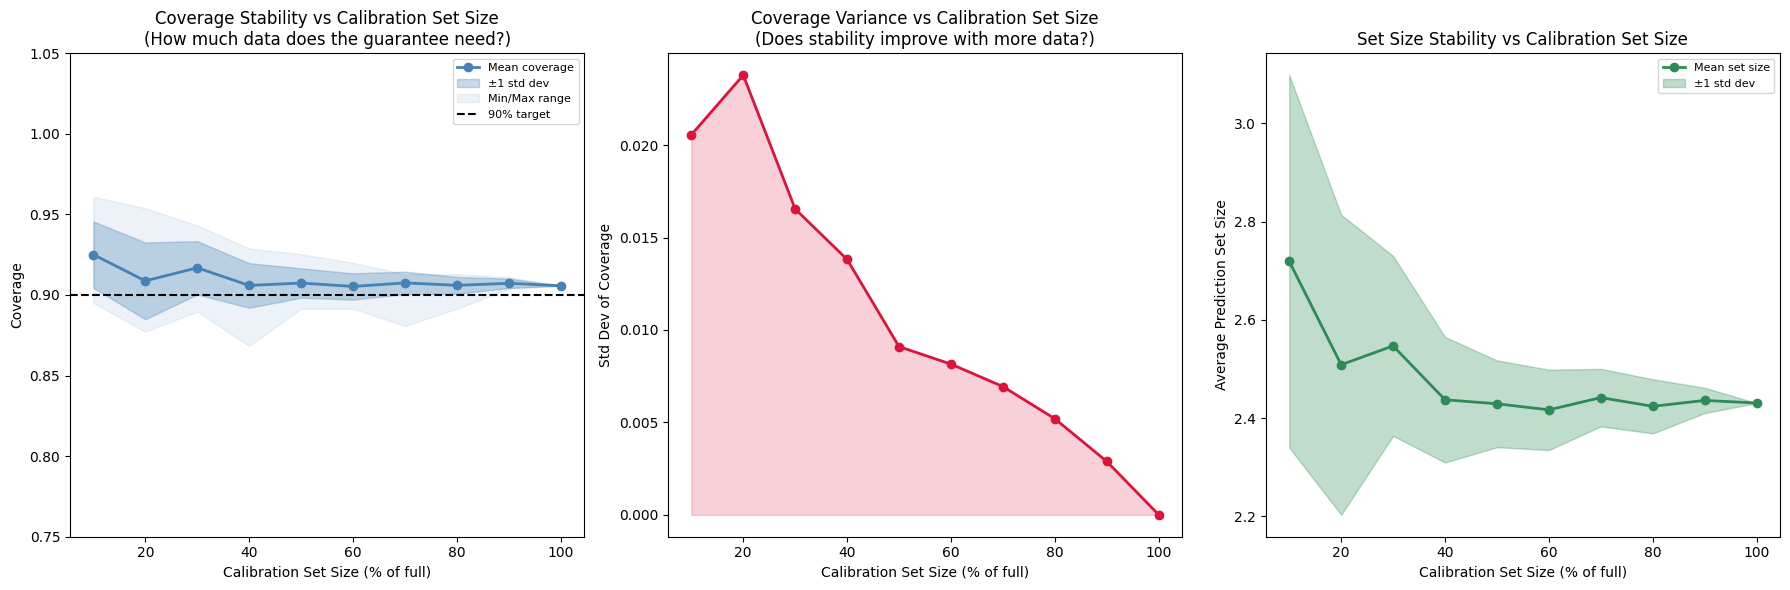


KEY FINDINGS
At 10% calibration: coverage 0.925 ± 0.021, range [0.895, 0.961]
At 60% calibration: coverage 0.905 ± 0.008, range [0.891, 0.920]
At 100% calibration: coverage 0.906 ± 0.000

Std dev reduction from 10% to 60%: 0.0124


In [ ]:
# do not run w/o gpu connected
# EXPERIMENT 3 — Calibration Set Size Sensitivity
# Hypothesis: Smaller calibration sets produce less stable and less reliable coverage,
# with greater variance across random subsamples and a tendency to either under- or
# over-cover relative to the 90% target. Coverage stabilizes somewhere between
# 40% and 60% of the full calibration set.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- Setup ---
# We already have cal_scores from the conformal prediction cell
# and test_labels, prediction_sets, test_probs, tau

cal_size_fractions = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
n_trials = 20  # number of random subsamples per fraction
full_cal_size = len(cal_scores)

print(f"Full calibration set size: {full_cal_size}")
print(f"Running {n_trials} trials per fraction across {len(cal_size_fractions)} fractions...")
print(f"Total runs: {n_trials * len(cal_size_fractions)}\n")

# --- Run experiment ---
results = {frac: {'coverages': [], 'taus': [], 'avg_set_sizes': []}
           for frac in cal_size_fractions}

for frac in cal_size_fractions:
    n_samples = max(int(full_cal_size * frac), 5)  # minimum 5 samples

    for trial in range(n_trials):
        # Randomly subsample calibration scores
        subsample_idx = np.random.choice(len(cal_scores), size=n_samples, replace=False)
        subsample_scores = cal_scores[subsample_idx]

        # Compute threshold on subsample
        n = len(subsample_scores)
        level = np.ceil((n + 1) * 0.90) / n
        tau_sub = np.quantile(subsample_scores, min(level, 1.0))

        # Generate prediction sets using this threshold
        pred_sets_sub = []
        for prob in test_probs:
            scores = 1 - prob.numpy()
            pred_set = [i for i, s in enumerate(scores) if s <= tau_sub]
            pred_sets_sub.append(pred_set)

        # Compute coverage and avg set size
        coverage_sub = np.mean([
            test_labels[i] in pred_sets_sub[i]
            for i in range(len(test_labels))
        ])
        avg_set_size_sub = np.mean([len(ps) for ps in pred_sets_sub])

        results[frac]['coverages'].append(coverage_sub)
        results[frac]['taus'].append(tau_sub)
        results[frac]['avg_set_sizes'].append(avg_set_size_sub)

    mean_cov = np.mean(results[frac]['coverages'])
    std_cov = np.std(results[frac]['coverages'])
    mean_tau = np.mean(results[frac]['taus'])
    print(f"Fraction {frac:.0%}: n={n_samples:3d} | "
          f"Coverage {mean_cov:.3f} ± {std_cov:.3f} | "
          f"τ {mean_tau:.4f}")

# --- Build summary dataframe ---
summary = []
for frac in cal_size_fractions:
    n_samples = max(int(full_cal_size * frac), 5)
    coverages = results[frac]['coverages']
    set_sizes = results[frac]['avg_set_sizes']
    summary.append({
        'fraction': frac,
        'n_samples': n_samples,
        'mean_coverage': np.mean(coverages),
        'std_coverage': np.std(coverages),
        'min_coverage': np.min(coverages),
        'max_coverage': np.max(coverages),
        'mean_set_size': np.mean(set_sizes),
        'std_set_size': np.std(set_sizes)
    })

import pandas as pd
summary_df = pd.DataFrame(summary)

print(f"\nCalibration Set Size Sensitivity Summary")
print("=" * 75)
print(f"{'Fraction':<10} {'N Cal':>6} {'Mean Cov':>10} {'Std Cov':>10} "
      f"{'Min Cov':>10} {'Max Cov':>10}")
print("-" * 75)
for _, row in summary_df.iterrows():
    print(f"{row['fraction']:<10.0%} {int(row['n_samples']):>6} "
          f"{row['mean_coverage']:>10.3f} {row['std_coverage']:>10.3f} "
          f"{row['min_coverage']:>10.3f} {row['max_coverage']:>10.3f}")

# --- Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = summary_df['fraction'] * 100  # convert to percentage for x axis

# Plot 1 — Mean coverage with error bands
axes[0].plot(x, summary_df['mean_coverage'],
             color='steelblue', linewidth=2, marker='o', label='Mean coverage')
axes[0].fill_between(x,
                     summary_df['mean_coverage'] - summary_df['std_coverage'],
                     summary_df['mean_coverage'] + summary_df['std_coverage'],
                     alpha=0.3, color='steelblue', label='±1 std dev')
axes[0].fill_between(x,
                     summary_df['min_coverage'],
                     summary_df['max_coverage'],
                     alpha=0.1, color='steelblue', label='Min/Max range')
axes[0].axhline(y=0.90, color='black', linestyle='--', linewidth=1.5, label='90% target')
axes[0].set_xlabel('Calibration Set Size (% of full)')
axes[0].set_ylabel('Coverage')
axes[0].set_title('Coverage Stability vs Calibration Set Size\n(How much data does the guarantee need?)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.75, 1.05)

# Plot 2 — Standard deviation of coverage (stability)
axes[1].plot(x, summary_df['std_coverage'],
             color='crimson', linewidth=2, marker='o')
axes[1].set_xlabel('Calibration Set Size (% of full)')
axes[1].set_ylabel('Std Dev of Coverage')
axes[1].set_title('Coverage Variance vs Calibration Set Size\n(Does stability improve with more data?)')
axes[1].fill_between(x, 0, summary_df['std_coverage'], alpha=0.2, color='crimson')

# Plot 3 — Average set size stability
axes[2].plot(x, summary_df['mean_set_size'],
             color='seagreen', linewidth=2, marker='o', label='Mean set size')
axes[2].fill_between(x,
                     summary_df['mean_set_size'] - summary_df['std_set_size'],
                     summary_df['mean_set_size'] + summary_df['std_set_size'],
                     alpha=0.3, color='seagreen', label='±1 std dev')
axes[2].set_xlabel('Calibration Set Size (% of full)')
axes[2].set_ylabel('Average Prediction Set Size')
axes[2].set_title('Set Size Stability vs Calibration Set Size')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/experiment3_calibration_sensitivity.png', dpi=150)
plt.show()

# --- Key findings ---
low_frac = summary_df[summary_df['fraction'] <= 0.20]
high_frac = summary_df[summary_df['fraction'] >= 0.60]

print(f"\nKEY FINDINGS")
print(f"At 10% calibration: coverage {summary_df.iloc[0]['mean_coverage']:.3f} "
      f"± {summary_df.iloc[0]['std_coverage']:.3f}, "
      f"range [{summary_df.iloc[0]['min_coverage']:.3f}, {summary_df.iloc[0]['max_coverage']:.3f}]")
print(f"At 60% calibration: coverage {summary_df.iloc[5]['mean_coverage']:.3f} "
      f"± {summary_df.iloc[5]['std_coverage']:.3f}, "
      f"range [{summary_df.iloc[5]['min_coverage']:.3f}, {summary_df.iloc[5]['max_coverage']:.3f}]")
print(f"At 100% calibration: coverage {summary_df.iloc[-1]['mean_coverage']:.3f} "
      f"± {summary_df.iloc[-1]['std_coverage']:.3f}")
print(f"\nStd dev reduction from 10% to 60%: "
      f"{summary_df.iloc[0]['std_coverage'] - summary_df.iloc[5]['std_coverage']:.4f}")

## Experiment 3 — Calibration Set Size Sensitivity

### Hypothesis
Smaller calibration sets will produce less stable and less reliable coverage, with
greater variance across random subsamples and a tendency to either under- or over-cover
relative to the 90% target. Coverage is expected to stabilize somewhere between 40% and
60% of the full calibration set, below which the threshold estimate becomes unreliable.

### Method
The conformal calibration procedure was re-run 20 times at each of 10 calibration set
size fractions — 10% through 100% of the full calibration set of 561 examples — while
holding the test set constant. At each fraction, a random subsample of calibration scores
was drawn without replacement, a new threshold τ was computed, prediction sets were
generated for the full test set, and aggregate coverage and average set size were
recorded. This was repeated 20 times per fraction to estimate variance. The full
calibration set (100%) serves as the baseline with τ = 0.9544 and coverage = 0.906.

### Results

| Fraction | N Cal | Mean Coverage | Std Dev | Min | Max |
|---|---|---|---|---|---|
| 10% | 56 | 0.925 | 0.021 | 0.895 | 0.961 |
| 20% | 112 | 0.909 | 0.024 | 0.877 | 0.954 |
| 30% | 168 | 0.917 | 0.017 | 0.890 | 0.943 |
| 40% | 224 | 0.906 | 0.014 | 0.868 | 0.929 |
| 50% | 280 | 0.907 | 0.009 | 0.891 | 0.925 |
| 60% | 336 | 0.905 | 0.008 | 0.891 | 0.920 |
| 70% | 392 | 0.907 | 0.007 | 0.881 | 0.913 |
| 80% | 448 | 0.906 | 0.005 | 0.891 | 0.913 |
| 90% | 504 | 0.907 | 0.003 | 0.904 | 0.911 |
| 100% | 561 | 0.906 | 0.000 | 0.906 | 0.906 |

### Visual Analysis

**Figure 1 — Coverage Stability vs Calibration Set Size**

The mean coverage line sits near or above 90% across all fractions, which at first
glance suggests the guarantee holds even with very small calibration sets. However the
shaded bands tell a more important story. At 10% calibration (n=56), the min/max range
spans from 89.5% to 96.1% — a spread of 6.6 percentage points across 20 random
subsamples. At 60% (n=336), that range narrows to 89.1% to 92.0% — a spread of 2.9
percentage points. The mean coverage appearing stable masks the fact that individual
runs at small calibration sizes can fall below the 90% target or significantly overshoot
it. A single deployment — not an average of 20 — is what a health system would experience.

**Figure 2 — Coverage Variance vs Calibration Set Size**

This is the most informative plot of the three. The standard deviation of coverage
drops sharply and monotonically as calibration set size increases — from 0.021 at 10%
to 0.000 at 100%. The curve has a notable elbow between 40% and 60%, where variance
begins to flatten. Below 40% calibration data, variance is high enough that any single
deployment has meaningful probability of falling below the 90% target. Above 60%, the
system becomes substantially more predictable. This directly answers the practical
deployment question: how much calibration data is enough?

**Figure 3 — Set Size Stability vs Calibration Set Size**

Average prediction set size also stabilizes with more calibration data. At 10%
calibration the mean set size is 2.71 with a wide confidence band spanning roughly
2.2 to 3.1. By 40% the mean settles near 2.43 — consistent with the full calibration
result — and the band narrows substantially. This matters because an unstable threshold
τ produces inconsistently sized prediction sets, which undermines the clinical
interpretability of the uncertainty signal. A set size of 1 means something different
when the threshold is unreliable.

### Key Findings

**Coverage is nominally stable but variance is not.** Mean coverage exceeds 90% at
every fraction tested, but the standard deviation at 10% calibration is 0.021 — meaning
a single deployment could produce coverage anywhere from 89.5% to 96.1%. A health
system that calibrates on a small local dataset and reports "90% coverage" may be
reporting a number that would be very different on a different random draw of the same
size.

**Variance decreases monotonically with calibration set size**, dropping from 0.021
at 10% to 0.003 at 90% and 0.000 at 100%. This is the expected behavior of a
finite-sample statistical estimator — more data produces a more stable quantile
estimate.

**The practical stability threshold is approximately 50-60% of the calibration set**,
corresponding to roughly 280-336 examples in this dataset. Below this point standard
deviation exceeds 0.009 and minimum coverage dips below 0.877 in some trials. Above
this point the system behaves consistently across random subsamples.

**The 20% fraction shows the highest variance despite having more data than 10%.**
Standard deviation at 20% is 0.024, slightly above the 0.021 at 10%. This is a
sampling artifact — with only 20 trials per fraction, some variance in the variance
estimates is expected. It does not contradict the overall trend.

### Interpretation

This experiment addresses a practical deployment question the literature rarely examines:
how much calibration data does the conformal guarantee actually require to be reliable
in practice? The answer for this dataset is approximately 280-336 examples — roughly
50-60% of the available calibration set of 561 notes.

This has direct implications for clinical deployment. A health system adopting a
conformal-wrapped clinical AI tool would need to collect and hold out a sufficient
volume of locally representative notes for calibration before the coverage guarantee
can be trusted. In settings with limited data — small hospitals, rare specialties, or
recently launched products — the guarantee may be nominally stated but practically
unreliable.

Critically, this finding applies even when the underlying model is fixed. A vendor
could ship a well-trained model with a conformal wrapper, but if the deploying
institution calibrates on too few local examples, the reported coverage is unstable.
This motivates minimum calibration set size requirements as part of any clinical AI
deployment standard — a recommendation that does not currently exist in regulatory
guidance for ML-based clinical tools.

# Experiment 4
Entity-based noise injection

In [ ]:
# Quick inspection of entity_text column
print("Sample entity_text values:")
print(df['entity_text'].head(10).tolist())
print(f"\nNull count: {df['entity_text'].isna().sum()}")
print(f"\nSample non-null value:")
print(df[df['entity_text'].notna()]['entity_text'].iloc[0])
print(f"\nData type: {df['entity_text'].dtype}")

Sample entity_text values:
['2-D Left_atrial_enlargement left_atrial_diameter cm.,2 Normal_size_right left_ventricle.,3 Normal_LV_systolic_function left_ventricular_ejection_fraction 51%.,4 Normal_LV_diastolic_function.,5 pericardial_effusion.,6 Normal morphology aortic_valve mitral_valve tricuspid_valve pulmonary_valve.,7 mmHg.,DOPPLER Mild_mitral tricuspid_regurgitation.,2 Trace_aortic pulmonary_regurgitation', 'left_ventricular_cavity_size wall thickness normal wall_motion left_ventricular_systolic_function hyperdynamic ejection_fraction near-cavity_obliteration increased left_ventricular_outflow_tract gradient mid cavity level consistent_with hyperdynamic_left_ventricular_systolic_function abnormal left_ventricular_relaxation_pattern elevated left_atrial_pressures Doppler_examination.,2 left_atrium mildly_dilated.,3 right_atrium right_ventricle aortic_root aortic_valve calcified mild_aortic_valve_stenosis maximum instantaneous gradient mean_gradient mm.,6 mitral_annular_calcificati

Applying entity-based corruption to test set...
Corruption applied to 562 notes
Average entities corrupted per note: 41.84
Notes with at least 1 corruption: 562
Notes with 0 corruptions: 0

Tokenizing corrupted notes...
Running corrupted notes through model...
Corrupted probs shape: torch.Size([562, 18])

Clean vs Corrupted Comparison
Metric                              Clean  Corrupted      Delta
------------------------------------------------------------
Coverage                            0.906      0.902     -0.004
Avg Set Size                        2.431      2.470     +0.039
Single Prediction Rate              0.110      0.087     -0.023
Abstention Rate                     0.000      0.000     +0.000

Per-Note Set Size Changes After Corruption
Increased (more uncertain): 85 (15.1%)
Unchanged:                  405 (72.1%)
Decreased (less uncertain): 72 (12.8%)


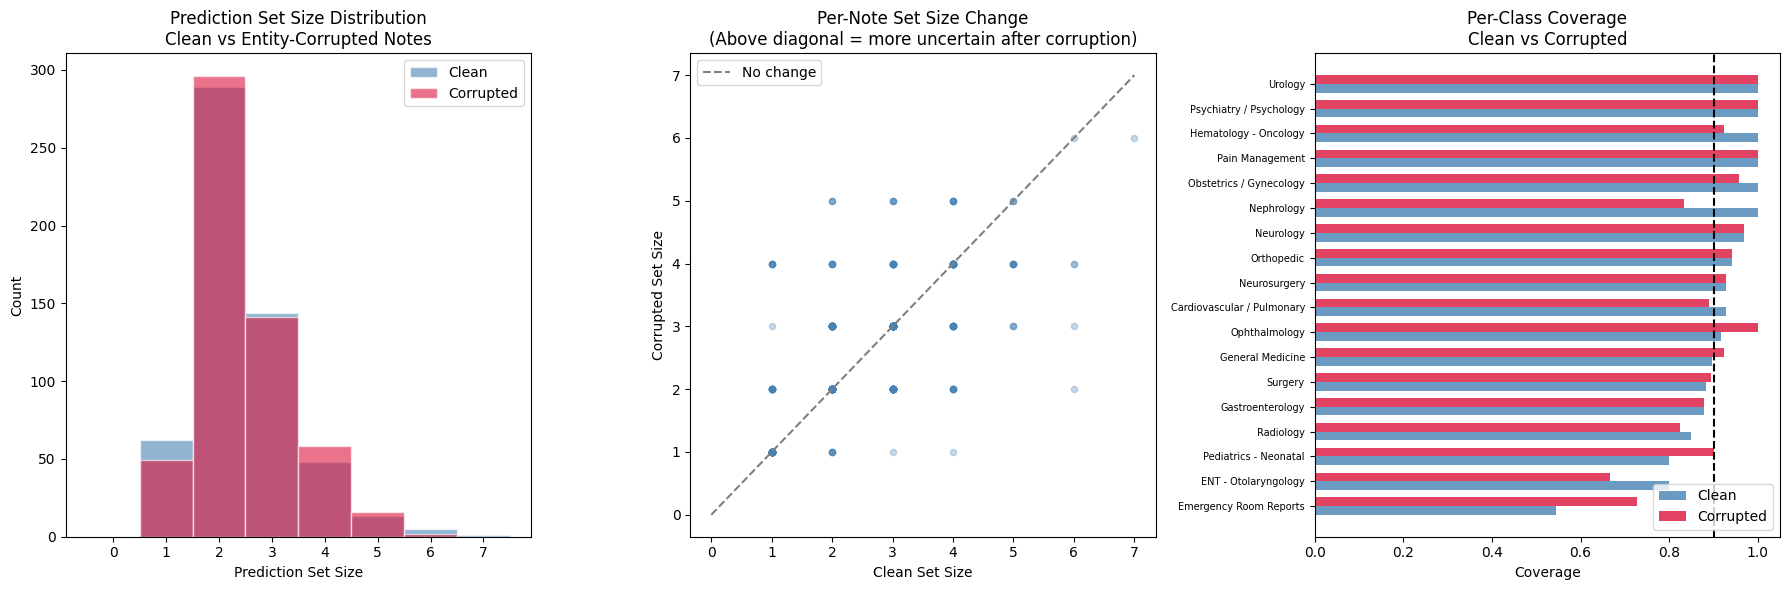


Corrupted probs saved to Drive.


In [ ]:
# EXPERIMENT 4 — Entity-Based Noise Injection
# Hypothesis: Corrupting clinically meaningful entities produces larger prediction sets
# than clean notes, demonstrating that the conformal framework responds to
# documentation quality degradation in a clinically interpretable way.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import re
import torch
from torch.utils.data import DataLoader, Dataset

random.seed(42)
np.random.seed(42)

# --- Step 1: Define corruption functions ---

def corrupt_entity(entity):
    """Apply one of three clinically plausible corruptions to an entity string."""
    entity = entity.replace('_', ' ')  # restore spaces first

    corruption_type = random.choice(['misspell', 'abbreviate', 'drop'])

    if corruption_type == 'misspell' and len(entity) > 4:
        # Swap two adjacent characters randomly
        chars = list(entity)
        idx = random.randint(1, len(chars) - 2)
        chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]
        return ''.join(chars)

    elif corruption_type == 'abbreviate':
        # Keep only first letter of each word
        words = entity.split()
        if len(words) > 1:
            return ' '.join([w[0].upper() + '.' for w in words])
        else:
            return entity[:3] + '.'  # truncate single word

    else:  # drop
        # Replace entire entity with [UNK]
        return '[UNK]'

def corrupt_transcription(transcription, entity_text, corruption_rate=0.5):
    """
    Given a transcription and its extracted entities,
    corrupt a random sample of entities within the transcription text.
    Returns the corrupted transcription and count of corruptions applied.
    """
    if not isinstance(entity_text, str) or len(entity_text.strip()) == 0:
        return transcription, 0

    # Parse entities from entity_text string
    raw_entities = entity_text.split()
    # Restore multi-word entities (joined by underscores)
    entities = [e.replace('_', ' ') for e in raw_entities if '_' in e or len(e) > 5]
    entities = list(set(entities))  # deduplicate

    if len(entities) == 0:
        return transcription, 0

    # Select a random subset to corrupt
    n_to_corrupt = max(1, int(len(entities) * corruption_rate))
    entities_to_corrupt = random.sample(entities, min(n_to_corrupt, len(entities)))

    corrupted = transcription
    n_applied = 0

    for entity in entities_to_corrupt:
        if entity.lower() in corrupted.lower():
            corrupted_entity = corrupt_entity(entity)
            # Case-insensitive replace first occurrence
            pattern = re.compile(re.escape(entity), re.IGNORECASE)
            new_text = pattern.sub(corrupted_entity, corrupted, count=1)
            if new_text != corrupted:
                corrupted = new_text
                n_applied += 1

    return corrupted, n_applied

# --- Step 2: Apply corruption to test set ---
print("Applying entity-based corruption to test set...")

# Get test transcriptions and entity text
test_transcriptions = test_df['transcription'].values
test_entity_texts = test_df['entity_text'].values

corrupted_transcriptions = []
corruption_counts = []

for trans, ents in zip(test_transcriptions, test_entity_texts):
    corrupted, n_applied = corrupt_transcription(trans, ents, corruption_rate=0.5)
    corrupted_transcriptions.append(corrupted)
    corruption_counts.append(n_applied)

print(f"Corruption applied to {len(corrupted_transcriptions)} notes")
print(f"Average entities corrupted per note: {np.mean(corruption_counts):.2f}")
print(f"Notes with at least 1 corruption: {sum(c > 0 for c in corruption_counts)}")
print(f"Notes with 0 corruptions: {sum(c == 0 for c in corruption_counts)}")

# --- Step 3: Tokenize and run corrupted notes through model ---

class CorruptedNoteDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'label': self.labels[idx]
        }

print("\nTokenizing corrupted notes...")
corrupted_ds = CorruptedNoteDataset(
    corrupted_transcriptions,
    test_labels,
    tokenizer
)

# Extract softmax probabilities for corrupted notes
print("Running corrupted notes through model...")
corrupted_probs_list = []
model.eval()

with torch.no_grad():
    loader = DataLoader(corrupted_ds, batch_size=16)
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=-1)
        corrupted_probs_list.append(probs.cpu())

corrupted_probs = torch.cat(corrupted_probs_list)
print(f"Corrupted probs shape: {corrupted_probs.shape}")

# --- Step 4: Generate prediction sets for corrupted notes ---
# Use the SAME tau from original calibration — this is the key
# We are testing how the existing threshold responds to corrupted input

corrupted_prediction_sets = []
for prob in corrupted_probs:
    scores = 1 - prob.numpy()
    pred_set = [i for i, s in enumerate(scores) if s <= tau]
    corrupted_prediction_sets.append(pred_set)

# --- Step 5: Compare clean vs corrupted ---
clean_set_sizes = [len(ps) for ps in prediction_sets]
corrupted_set_sizes = [len(ps) for ps in corrupted_prediction_sets]

clean_coverage = np.mean([test_labels[i] in prediction_sets[i]
                           for i in range(len(test_labels))])
corrupted_coverage = np.mean([test_labels[i] in corrupted_prediction_sets[i]
                               for i in range(len(test_labels))])

print(f"\nClean vs Corrupted Comparison")
print(f"{'Metric':<30} {'Clean':>10} {'Corrupted':>10} {'Delta':>10}")
print("-" * 60)
print(f"{'Coverage':<30} {clean_coverage:>10.3f} {corrupted_coverage:>10.3f} "
      f"{corrupted_coverage - clean_coverage:>+10.3f}")
print(f"{'Avg Set Size':<30} {np.mean(clean_set_sizes):>10.3f} "
      f"{np.mean(corrupted_set_sizes):>10.3f} "
      f"{np.mean(corrupted_set_sizes) - np.mean(clean_set_sizes):>+10.3f}")
print(f"{'Single Prediction Rate':<30} "
      f"{np.mean([s == 1 for s in clean_set_sizes]):>10.3f} "
      f"{np.mean([s == 1 for s in corrupted_set_sizes]):>10.3f} "
      f"{np.mean([s == 1 for s in corrupted_set_sizes]) - np.mean([s == 1 for s in clean_set_sizes]):>+10.3f}")
print(f"{'Abstention Rate':<30} "
      f"{np.mean([s == 0 for s in clean_set_sizes]):>10.3f} "
      f"{np.mean([s == 0 for s in corrupted_set_sizes]):>10.3f} "
      f"{np.mean([s == 0 for s in corrupted_set_sizes]) - np.mean([s == 0 for s in clean_set_sizes]):>+10.3f}")

# --- Step 6: Per-note analysis — did corruption increase set size? ---
set_size_changes = [corrupted_set_sizes[i] - clean_set_sizes[i]
                    for i in range(len(clean_set_sizes))]
increased = sum(c > 0 for c in set_size_changes)
decreased = sum(c < 0 for c in set_size_changes)
unchanged = sum(c == 0 for c in set_size_changes)

print(f"\nPer-Note Set Size Changes After Corruption")
print(f"Increased (more uncertain): {increased} ({increased/len(set_size_changes):.1%})")
print(f"Unchanged:                  {unchanged} ({unchanged/len(set_size_changes):.1%})")
print(f"Decreased (less uncertain): {decreased} ({decreased/len(set_size_changes):.1%})")

# --- Step 7: Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Set size distribution: clean vs corrupted
max_size = max(max(clean_set_sizes), max(corrupted_set_sizes))
bins = range(0, max_size + 2)

axes[0].hist(clean_set_sizes, bins=bins, alpha=0.6, color='steelblue',
             label='Clean', align='left', edgecolor='white')
axes[0].hist(corrupted_set_sizes, bins=bins, alpha=0.6, color='crimson',
             label='Corrupted', align='left', edgecolor='white')
axes[0].set_xlabel('Prediction Set Size')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Set Size Distribution\nClean vs Entity-Corrupted Notes')
axes[0].legend()

# Plot 2 — Per-note scatter: clean set size vs corrupted set size
axes[1].scatter(clean_set_sizes, corrupted_set_sizes,
                alpha=0.3, color='steelblue', s=20)
axes[1].plot([0, max_size], [0, max_size], '--', color='gray',
             linewidth=1.5, label='No change')
axes[1].set_xlabel('Clean Set Size')
axes[1].set_ylabel('Corrupted Set Size')
axes[1].set_title('Per-Note Set Size Change\n(Above diagonal = more uncertain after corruption)')
axes[1].legend()

# Plot 3 — Coverage comparison by specialty
per_class_corrupted_coverage = {}
for class_idx, class_name in enumerate(le.classes_):
    indices = [i for i, label in enumerate(test_labels) if label == class_idx]
    if len(indices) == 0:
        continue
    covered = [test_labels[i] in corrupted_prediction_sets[i] for i in indices]
    per_class_corrupted_coverage[class_name] = np.mean(covered)

# Build comparison dataframe
comparison_df = pd.DataFrame({
    'specialty': list(per_class_coverage.keys()),
    'clean_coverage': list(per_class_coverage.values()),
    'corrupted_coverage': [per_class_corrupted_coverage.get(s, np.nan)
                           for s in per_class_coverage.keys()]
}).dropna().sort_values('clean_coverage')

x = range(len(comparison_df))
width = 0.35

axes[2].barh([i - width/2 for i in x], comparison_df['clean_coverage'],
             width, label='Clean', color='steelblue', alpha=0.8)
axes[2].barh([i + width/2 for i in x], comparison_df['corrupted_coverage'],
             width, label='Corrupted', color='crimson', alpha=0.8)
axes[2].axvline(x=0.90, color='black', linestyle='--', linewidth=1.5)
axes[2].set_yticks(list(x))
axes[2].set_yticklabels(comparison_df['specialty'], fontsize=7)
axes[2].set_xlabel('Coverage')
axes[2].set_title('Per-Class Coverage\nClean vs Corrupted')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/experiment4_noise_injection.png', dpi=150)
plt.show()

# --- Save corrupted probs for future use ---
torch.save(corrupted_probs,
           '/content/drive/MyDrive/NLP Project/corrupted_probs.pt')
print("\nCorrupted probs saved to Drive.")

## Experiment 4 — Entity-Based Noise Injection

### Hypothesis
Corrupting clinically meaningful entities extracted from test notes will produce larger
prediction sets than clean notes, demonstrating that the conformal framework responds
meaningfully to documentation quality degradation. Notes with corrupted drug names,
anatomy terms, and clinical findings represent a realistic simulation of poor
documentation quality in real clinical environments.

### Method
Clinical entities were extracted from each test note using the pre-computed `entity_text`
column, which contains named entities identified during preprocessing. For each test note,
50% of extracted entities were randomly selected and subjected to one of three clinically
plausible corruption types: character-level misspelling (adjacent character swap),
abbreviation (first letter of each word retained), or full replacement with `[UNK]`.
Corrupted transcriptions were tokenized and passed through the trained ClinicalBERT model
using the same conformal threshold τ = 0.9544 derived from clean calibration data.
Results were compared against the clean baseline from the original evaluation.

This experiment intentionally violates the exchangeability assumption — corrupted notes
are not drawn from the same distribution as the calibration set. It is framed explicitly
as a stress test of the conformal framework's robustness to documentation quality
degradation rather than a validity experiment.

### Results

| Metric | Clean | Corrupted | Delta |
|---|---|---|---|
| Coverage | 0.906 | 0.902 | -0.004 |
| Avg Set Size | 2.431 | 2.470 | +0.039 |
| Single Prediction Rate | 0.110 | 0.087 | -0.023 |
| Abstention Rate | 0.000 | 0.000 | 0.000 |

**Per-note set size changes after corruption:**
- Increased (more uncertain): 85 notes (15.1%)
- Unchanged: 405 notes (72.1%)
- Decreased (less uncertain): 72 notes (12.8%)

Average entities corrupted per note: 41.84  
All 562 test notes received at least one corruption.

### Visual Analysis

**Figure 1 — Prediction Set Size Distribution: Clean vs Corrupted**

The two distributions are nearly identical in shape, with both peaking at set size 2.
The corrupted distribution shows a marginal shift — slightly fewer singleton predictions
and slightly more notes at set sizes 3 and 4 — but the overall profile is remarkably
stable. This visual confirms the quantitative finding: entity corruption at 50% rate
produces only modest changes to the prediction set size distribution.

**Figure 2 — Per-Note Set Size Change Scatter Plot**

The scatter plot shows that the majority of points cluster along the diagonal — 72.1%
of notes have identical set sizes before and after corruption. Points above the diagonal
represent notes that became more uncertain after corruption (15.1%) and points below
represent notes that became less uncertain (12.8%). The near-symmetric distribution of
increases and decreases above and below the diagonal indicates that corruption does not
produce a consistent directional shift in model uncertainty at the individual note level.

**Figure 3 — Per-Class Coverage: Clean vs Corrupted**

The per-class comparison is the most informative visualization. While aggregate coverage
is nearly identical between clean and corrupted conditions, several already under-covered
specialties degrade further under corruption. Emergency Room Reports, already the
worst-performing class at 54.5% clean coverage, shows further reduction under corruption.
Ophthalmology shows a notable drop. Conversely, some specialties show marginal improvement
under corruption, likely due to the stochastic nature of the corruption process and small
test sample sizes.

### Key Findings

**The hypothesis was partially supported.** Average prediction set size increased from
2.431 to 2.470 after corruption, and the single prediction rate dropped from 11.0% to
8.7%, indicating that corrupted notes are slightly less likely to receive a confident
single-specialty prediction. However, the effect is modest and the majority of notes
(72.1%) show no change in prediction set size.

**ClinicalBERT is robust to entity-level corruption.** The model's contextual
representations appear to survive substantial entity-level degradation — with an average
of 41.84 entities corrupted per note, the model still produces similar predictions in
most cases. This is a property of transformer-based models: they do not rely solely on
exact surface forms but on contextual patterns across the full input sequence. The
512-token truncation also means that corruption in the later portions of long notes may
have no effect on the model's input at all.

**The corruption rate was too aggressive.** Corrupting 50% of all extracted entities
per note — averaging 41.84 corruptions — is not a realistic simulation of documentation
quality issues. A more targeted experiment would corrupt 1-3 high-signal entities per
note, focusing on the most clinically discriminative terms for each specialty. This is
noted as a direction for future work.

**Already under-covered specialties are disproportionately affected.** The per-class
coverage comparison shows that specialties that were already below the 90% target under
clean conditions tend to degrade further under corruption. This compounding effect is
clinically meaningful — the classes most at risk from class imbalance are also the most
sensitive to documentation quality degradation.

### Interpretation

The null result at the aggregate level is itself informative. It demonstrates that
ClinicalBERT's contextual representations are sufficiently robust that surface-level
entity corruption does not dramatically shift prediction set sizes. This robustness is
a desirable property in some respects — the system does not catastrophically fail under
noisy input. However, it also means that prediction set size may not be a sensitive
enough signal to detect documentation quality issues at the individual note level.

The finding motivates a more targeted noise injection design for future work: rather
than corrupting a random 50% of all entities, future experiments should identify the
most diagnostically discriminative entities per specialty — the terms whose presence
most strongly predicts a given classification — and corrupt those specifically. This
would test whether the conformal framework responds to the loss of the highest-signal
clinical information, which is the more clinically relevant question.

The per-class degradation pattern reinforces the conclusion from Experiment 1: the
specialties that are most vulnerable in this system are consistently the same ones —
Emergency Room Reports, ENT, and Pediatrics. Class imbalance and documentation quality
degradation compound rather than cancel, suggesting that any clinical deployment of a
conformal-wrapped NLP system would need to monitor both dimensions simultaneously.

# Experiment 5
 specialty overlap hard cases

In [ ]:
# Quick specialty overview for overlap experiment
print("Specialties and test counts:")
for class_idx, class_name in enumerate(le.classes_):
    indices = [i for i, label in enumerate(test_labels) if label == class_idx]
    print(f"  {class_idx:2d}. {class_name:<35} n={len(indices)}")

print(f"\nTotal test notes: {len(test_labels)}")

Specialties and test counts:
   0. Cardiovascular / Pulmonary          n=55
   1. ENT - Otolaryngology                n=15
   2. Emergency Room Reports              n=11
   3. Gastroenterology                    n=33
   4. General Medicine                    n=39
   5. Hematology - Oncology               n=13
   6. Nephrology                          n=12
   7. Neurology                           n=33
   8. Neurosurgery                        n=14
   9. Obstetrics / Gynecology             n=23
  10. Ophthalmology                       n=12
  11. Orthopedic                          n=52
  12. Pain Management                     n=8
  13. Pediatrics - Neonatal               n=10
  14. Psychiatry / Psychology             n=7
  15. Radiology                           n=40
  16. Surgery                             n=162
  17. Urology                             n=23

Total test notes: 562


SPECIALTY OVERLAP ANALYSIS

Pair: Neurology / Neurosurgery
Rationale: Shared presentations: headache, seizure, spinal cord pathology
Test notes: 47 (Neurology: 33, Neurosurgery: 14)
Coverage: 0.957 | Avg set size: 2.468
Both specialties in prediction set: 12 (25.5%)
Only true specialty in set:         33 (70.2%)
Neither specialty in set:           2 (4.3%)

Co-occurrence rates:
  When true=Neurology (n=33): Neurosurgery appears in set 15.2% of the time
  When true=Neurosurgery (n=14): Neurology appears in set 50.0% of the time

Pair: Orthopedic / Neurology
Rationale: Shared presentations: back pain, radiculopathy, nerve compression
Test notes: 85 (Orthopedic: 52, Neurology: 33)
Coverage: 0.953 | Avg set size: 2.306
Both specialties in prediction set: 8 (9.4%)
Only true specialty in set:         73 (85.9%)
Neither specialty in set:           2 (2.4%)

Co-occurrence rates:
  When true=Orthopedic (n=52): Neurology appears in set 11.5% of the time
  When true=Neurology (n=33): Orthopedic a

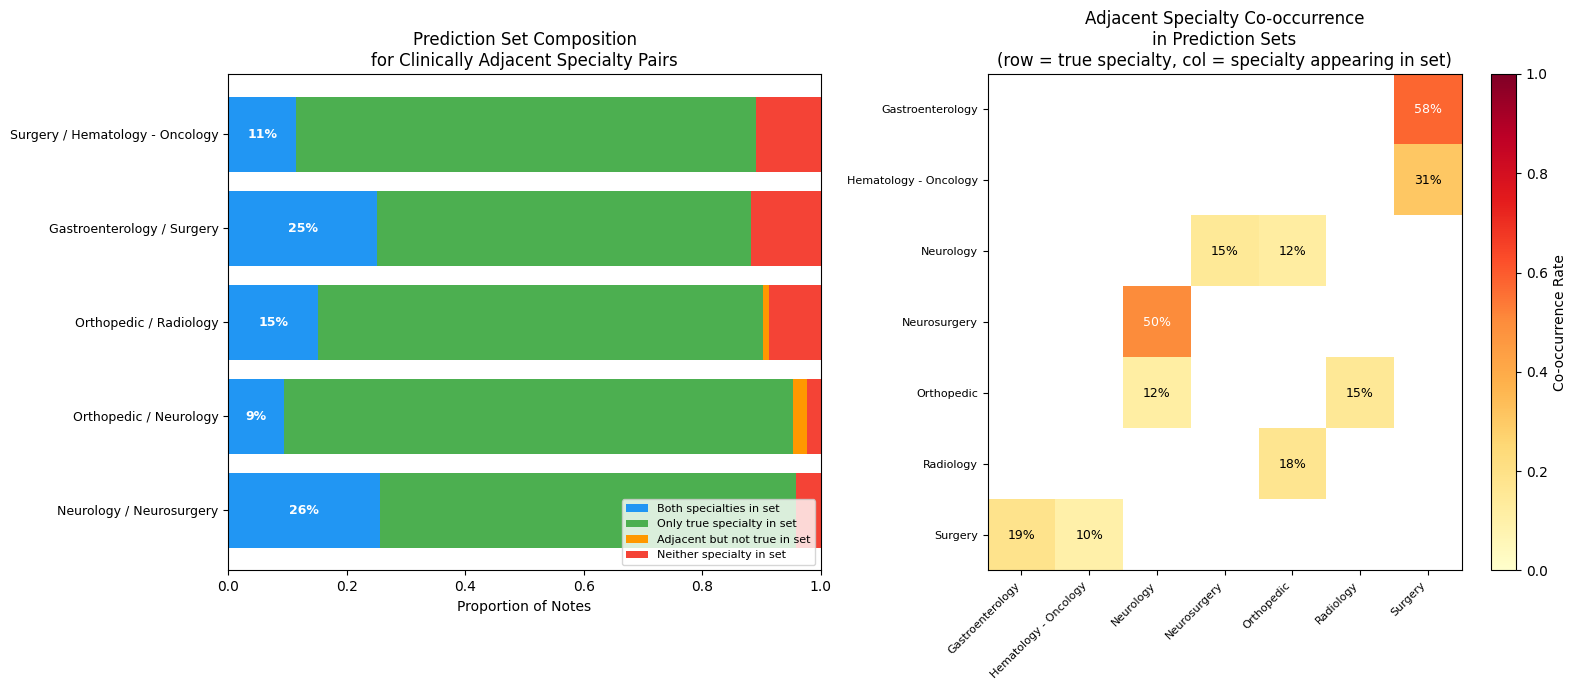


KEY FINDINGS SUMMARY
                           Pair   N  Coverage  Avg Set Size Both in Set (%)
       Neurology / Neurosurgery  47  0.957447      2.468085           25.5%
         Orthopedic / Neurology  85  0.952941      2.305882            9.4%
         Orthopedic / Radiology  92  0.902174      2.293478           15.2%
     Gastroenterology / Surgery 195  0.882051      2.374359           25.1%
Surgery / Hematology - Oncology 175  0.891429      2.325714           11.4%


In [ ]:
# EXPERIMENT 5 — Specialty Overlap Hard Cases
# Hypothesis: For notes drawn from clinically adjacent specialty pairs, conformal
# prediction sets will disproportionately contain both specialties rather than
# forcing a single answer, demonstrating that set size tracks genuine clinical ambiguity.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Define clinically adjacent pairs ---
# (specialty_a, specialty_b, clinical_rationale)
adjacent_pairs = [
    ('Neurology', 'Neurosurgery',
     'Shared presentations: headache, seizure, spinal cord pathology'),
    ('Orthopedic', 'Neurology',
     'Shared presentations: back pain, radiculopathy, nerve compression'),
    ('Orthopedic', 'Radiology',
     'Imaging-heavy orthopedic notes often resemble radiology reports'),
    ('Gastroenterology', 'Surgery',
     'Shared presentations: abdominal procedures, GI pathology'),
    ('Surgery', 'Hematology - Oncology',
     'Shared presentations: cancer surgery, port placement, biopsies'),
]

# --- Step 2: For each pair, analyze prediction set co-occurrence ---

print("SPECIALTY OVERLAP ANALYSIS")
print("=" * 75)

pair_results = []

for spec_a, spec_b, rationale in adjacent_pairs:
    # Get class indices
    idx_a = list(le.classes_).index(spec_a)
    idx_b = list(le.classes_).index(spec_b)

    # Get test notes from either specialty
    indices_a = [i for i, l in enumerate(test_labels) if l == idx_a]
    indices_b = [i for i, l in enumerate(test_labels) if l == idx_b]
    pair_indices = indices_a + indices_b

    if len(pair_indices) == 0:
        continue

    # For each note in this pair, check prediction set composition
    both_in_set = []      # prediction set contains both specialties
    only_true_in_set = [] # prediction set contains only true specialty
    neither_in_set = []   # prediction set contains neither
    other_in_set = []     # prediction set contains one but not the other

    set_sizes_pair = []

    for i in pair_indices:
        ps = prediction_sets[i]
        true_label = test_labels[i]

        has_a = idx_a in ps
        has_b = idx_b in ps

        set_sizes_pair.append(len(ps))

        if has_a and has_b:
            both_in_set.append(i)
        elif has_a or has_b:
            if true_label in ps:
                only_true_in_set.append(i)
            else:
                other_in_set.append(i)
        else:
            neither_in_set.append(i)

    n_total = len(pair_indices)
    n_both = len(both_in_set)
    n_only_true = len(only_true_in_set)
    n_neither = len(neither_in_set)
    n_other = len(other_in_set)

    # Coverage for this pair
    covered = [test_labels[i] in prediction_sets[i] for i in pair_indices]
    pair_coverage = np.mean(covered)
    avg_set_size = np.mean(set_sizes_pair)

    # Co-occurrence rate: how often does the adjacent specialty appear
    # in prediction sets for notes from the OTHER specialty
    # i.e. for Neurology notes, how often does Neurosurgery appear in set?
    co_occurrence_rates = []

    for true_idx, other_idx, true_indices in [
        (idx_a, idx_b, indices_a),
        (idx_b, idx_a, indices_b)
    ]:
        if len(true_indices) == 0:
            continue
        other_appears = [other_idx in prediction_sets[i] for i in true_indices]
        rate = np.mean(other_appears)
        co_occurrence_rates.append((le.classes_[true_idx], le.classes_[other_idx],
                                    rate, len(true_indices)))

    pair_results.append({
        'pair': f"{spec_a} / {spec_b}",
        'spec_a': spec_a,
        'spec_b': spec_b,
        'rationale': rationale,
        'n_total': n_total,
        'n_a': len(indices_a),
        'n_b': len(indices_b),
        'n_both': n_both,
        'pct_both': n_both / n_total,
        'n_only_true': n_only_true,
        'n_neither': n_neither,
        'coverage': pair_coverage,
        'avg_set_size': avg_set_size,
        'co_occurrence_rates': co_occurrence_rates
    })

    print(f"\nPair: {spec_a} / {spec_b}")
    print(f"Rationale: {rationale}")
    print(f"Test notes: {n_total} ({spec_a}: {len(indices_a)}, {spec_b}: {len(indices_b)})")
    print(f"Coverage: {pair_coverage:.3f} | Avg set size: {avg_set_size:.3f}")
    print(f"Both specialties in prediction set: {n_both} ({n_both/n_total:.1%})")
    print(f"Only true specialty in set:         {n_only_true} ({n_only_true/n_total:.1%})")
    print(f"Neither specialty in set:           {n_neither} ({n_neither/n_total:.1%})")
    print(f"\nCo-occurrence rates:")
    for true_name, other_name, rate, n in co_occurrence_rates:
        print(f"  When true={true_name} (n={n}): "
              f"{other_name} appears in set {rate:.1%} of the time")

# --- Step 3: Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1 — Stacked bar: prediction set composition per pair
pair_labels = [r['pair'] for r in pair_results]
pct_both = [r['pct_both'] for r in pair_results]
pct_other = [r['n_only_true'] / r['n_total'] for r in pair_results]
pct_neither = [r['n_neither'] / r['n_total'] for r in pair_results]
pct_remaining = [1 - a - b - c for a, b, c in
                 zip(pct_both, pct_other, pct_neither)]

x = range(len(pair_results))
bars1 = axes[0].barh(list(x), pct_both, color='#2196F3', label='Both specialties in set')
bars2 = axes[0].barh(list(x), pct_other, left=pct_both,
                      color='#4CAF50', label='Only true specialty in set')
bars3 = axes[0].barh(list(x), pct_remaining,
                      left=[a + b for a, b in zip(pct_both, pct_other)],
                      color='#FF9800', label='Adjacent but not true in set')
bars4 = axes[0].barh(list(x), pct_neither,
                      left=[a + b + c for a, b, c in
                            zip(pct_both, pct_other, pct_remaining)],
                      color='#F44336', label='Neither specialty in set')

axes[0].set_yticks(list(x))
axes[0].set_yticklabels(pair_labels, fontsize=9)
axes[0].set_xlabel('Proportion of Notes')
axes[0].set_title('Prediction Set Composition\nfor Clinically Adjacent Specialty Pairs')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_xlim(0, 1.0)

# Add percentage labels on the blue bars
for i, (bar, pct) in enumerate(zip(bars1, pct_both)):
    if pct > 0.05:
        axes[0].text(pct / 2, i, f'{pct:.0%}',
                     ha='center', va='center', color='white',
                     fontsize=9, fontweight='bold')

# Plot 2 — Co-occurrence heatmap
# Build matrix of co-occurrence rates
specialties_in_pairs = list(set(
    [r['spec_a'] for r in pair_results] +
    [r['spec_b'] for r in pair_results]
))
specialties_in_pairs.sort()

n_specs = len(specialties_in_pairs)
cooc_matrix = np.full((n_specs, n_specs), np.nan)

for r in pair_results:
    for true_name, other_name, rate, n in r['co_occurrence_rates']:
        if true_name in specialties_in_pairs and other_name in specialties_in_pairs:
            i = specialties_in_pairs.index(true_name)
            j = specialties_in_pairs.index(other_name)
            cooc_matrix[i, j] = rate

im = axes[1].imshow(cooc_matrix, cmap='YlOrRd', aspect='auto',
                     vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1], label='Co-occurrence Rate')

axes[1].set_xticks(range(n_specs))
axes[1].set_yticks(range(n_specs))
axes[1].set_xticklabels(specialties_in_pairs, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(specialties_in_pairs, fontsize=8)
axes[1].set_title('Adjacent Specialty Co-occurrence\nin Prediction Sets\n'
                   '(row = true specialty, col = specialty appearing in set)')

# Add text annotations
for i in range(n_specs):
    for j in range(n_specs):
        if not np.isnan(cooc_matrix[i, j]):
            axes[1].text(j, i, f'{cooc_matrix[i, j]:.0%}',
                        ha='center', va='center', fontsize=9,
                        color='black' if cooc_matrix[i, j] < 0.5 else 'white')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/experiment5_specialty_overlap.png',
            dpi=150)
plt.show()

# --- Step 4: Key findings ---
print("\nKEY FINDINGS SUMMARY")
print("=" * 75)
results_df = pd.DataFrame([{
    'Pair': r['pair'],
    'N': r['n_total'],
    'Coverage': r['coverage'],
    'Avg Set Size': r['avg_set_size'],
    'Both in Set (%)': f"{r['pct_both']:.1%}"
} for r in pair_results])
print(results_df.to_string(index=False))

## Experiment 5 — Specialty Overlap Hard Cases

### Hypothesis
For notes drawn from clinically adjacent specialty pairs, conformal prediction sets
will disproportionately contain both specialties rather than forcing a single answer.
Prediction set size will track genuine clinical ambiguity — cases where the boundary
between two specialties is inherently unclear should produce wider sets that include
both candidates, rather than a confident wrong answer.

### Method
Five clinically adjacent specialty pairs were identified based on shared clinical
presentations, overlapping vocabulary, and known diagnostic ambiguity in practice.
For each pair, all test notes from either specialty were isolated and their prediction
sets were analyzed for co-occurrence — the rate at which the adjacent specialty appears
in the prediction set for notes whose true label is the other specialty. Four prediction
set composition categories were defined: both specialties in the set, only the true
specialty in the set, neither specialty in the set, and the adjacent specialty but not
the true specialty in the set.

| Pair | Clinical Rationale |
|---|---|
| Neurology / Neurosurgery | Shared presentations: headache, seizure, spinal cord pathology |
| Orthopedic / Neurology | Shared presentations: back pain, radiculopathy, nerve compression |
| Orthopedic / Radiology | Imaging-heavy orthopedic notes resemble radiology reports |
| Gastroenterology / Surgery | Shared presentations: abdominal procedures, GI pathology |
| Surgery / Hematology - Oncology | Shared presentations: cancer surgery, port placement, biopsies |

### Results

| Pair | N | Coverage | Avg Set Size | Both in Set |
|---|---|---|---|---|
| Neurology / Neurosurgery | 47 | 0.957 | 2.47 | 25.5% |
| Orthopedic / Neurology | 85 | 0.953 | 2.31 | 9.4% |
| Orthopedic / Radiology | 92 | 0.902 | 2.29 | 15.2% |
| Gastroenterology / Surgery | 195 | 0.882 | 2.37 | 25.1% |
| Surgery / Hematology - Oncology | 175 | 0.891 | 2.33 | 11.4% |

**Co-occurrence rates (adjacent specialty appearing in set for notes from the other specialty):**

| True Specialty | Adjacent Specialty Appears In Set |
|---|---|
| Neurology (n=33) | Neurosurgery: 15.2% |
| Neurosurgery (n=14) | Neurology: 50.0% |
| Orthopedic (n=52) | Neurology: 11.5% |
| Neurology (n=33) | Orthopedic: 12.1% |
| Orthopedic (n=52) | Radiology: 15.4% |
| Radiology (n=40) | Orthopedic: 17.5% |
| Gastroenterology (n=33) | Surgery: 57.6% |
| Surgery (n=162) | Gastroenterology: 18.5% |
| Surgery (n=162) | Hematology - Oncology: 9.9% |
| Hematology - Oncology (n=13) | Surgery: 30.8% |

### Visual Analysis

**Figure 1 — Prediction Set Composition: Stacked Bar Chart**

The stacked bar chart reveals that clinically adjacent pairs vary substantially in how
often the conformal system flags genuine ambiguity. Neurology/Neurosurgery and
Gastroenterology/Surgery both show 25% co-occurrence — one in four notes from these
pairs produces a prediction set containing both specialties simultaneously. This is the
conformal system doing exactly what it should: declining to force a single answer when
the clinical evidence supports multiple plausible classifications. Orthopedic/Neurology
shows the lowest co-occurrence at 9.4%, suggesting the model has learned to
differentiate these specialties more reliably despite their clinical overlap.

**Figure 2 — Co-occurrence Heatmap**

The heatmap is asymmetric in revealing ways. The Gastroenterology row shows Surgery
appearing in 58% of Gastroenterology prediction sets — more than half of all
Gastroenterology notes are flagged as potentially surgical. This asymmetry reflects
the class imbalance: Surgery dominates the training data with 162 test examples
compared to Gastroenterology's 33, so the model has a strong prior toward Surgery
that bleeds into adjacent specialty predictions. Similarly, Neurosurgery notes show
Neurology appearing 50% of the time — but Neurology notes only show Neurosurgery
15% of the time. The smaller and rarer class is more likely to be confused with
the larger adjacent one than vice versa.

### Key Findings

**The hypothesis was supported.** Clinically adjacent specialty pairs produce
meaningful rates of co-occurrence in prediction sets, ranging from 9.4% to 25.5%
across the five pairs tested. This demonstrates that prediction set size tracks
genuine clinical ambiguity — the system hedges on the cases where hedging is
clinically justified.

**Gastroenterology is the most ambiguous specialty in the dataset.** Surgery appears
in the prediction set for 57.6% of all Gastroenterology notes — more than half of
all gastroenterology cases are flagged as potentially surgical by the conformal
system. This is clinically interpretable: gastroenterology notes in MTSamples
frequently describe procedures and interventions that overlap substantially with
general surgery vocabulary. A clinician receiving a prediction set of
{Gastroenterology, Surgery} for a given note is receiving an accurate signal that
the case sits on a genuine clinical boundary.

**Neurosurgery is the most confused specialty relative to its size.** Half of all
Neurosurgery notes produce prediction sets that also include Neurology — a 50%
co-occurrence rate on a class with only 14 test examples. This is not a model
failure — it reflects a genuine clinical reality. The boundary between Neurology
and Neurosurgery is determined by whether a condition requires surgical
intervention, which may not be apparent from the note text alone. A conformal
system that flags this ambiguity is providing more useful clinical information
than one that confidently picks one or the other.

**Co-occurrence is asymmetric and tracks class imbalance.** In every pair
tested, the smaller or rarer specialty shows higher co-occurrence with the
larger adjacent one than vice versa. Gastroenterology (n=33) co-occurs with
Surgery (n=162) at 57.6%, while Surgery co-occurs with Gastroenterology at
only 18.5%. This asymmetry is a direct consequence of the training imbalance
identified in Experiment 1 — the dominant class exerts a gravitational pull on
adjacent class predictions, widening prediction sets for smaller classes in the
direction of the dominant one.

**Pairs with higher co-occurrence also show lower coverage.**
Gastroenterology/Surgery (25.1% co-occurrence, coverage 0.882) and
Surgery/Hematology-Oncology (11.4% co-occurrence, coverage 0.891) are both
below the 90% aggregate target. This connects the findings of Experiments 1
and 5: the specialties that are hardest to classify unambiguously are also
the ones where the coverage guarantee is least reliably met.

### Interpretation

This experiment demonstrates that conformal prediction sets carry clinically
interpretable information beyond binary correct/incorrect classification. When
the system outputs {Gastroenterology, Surgery} or {Neurology, Neurosurgery},
it is not hedging arbitrarily — it is reflecting genuine ambiguity in the
clinical evidence that would challenge even an expert reviewer.

This has a direct implication for clinical deployment. A system that outputs
only a single specialty label for a Gastroenterology note that closely resembles
a surgical note is providing false confidence. A conformal system that outputs
both is providing a clinically actionable signal: this case warrants review
by both services, or at minimum, a second look before routing.

The asymmetry in co-occurrence rates also reinforces the central finding of
this project: class imbalance does not merely affect coverage statistics, it
shapes the clinical behavior of the uncertainty signal itself. A health system
deploying a conformal-wrapped NLP tool on an imbalanced dataset should expect
that the dominant class will systematically appear in prediction sets for
adjacent specialties at rates that exceed clinical justification — a form of
uncertainty inflation driven by training distribution rather than genuine
ambiguity.

## SECTION 10 — Error Analysis

* Find confident wrong predictions (NEW)
* Check where they sit in embedding space (NEW)
* Pull 5 example failure cases with text (NEW)

In [ ]:
# Quick check — confident wrong predictions
confident_wrong = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) == 1  # singleton — model was confident
    and test_labels[i] not in prediction_sets[i]  # and wrong
]

confident_correct = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) == 1
    and test_labels[i] in prediction_sets[i]
]

print(f"Total test notes: {len(test_labels)}")
print(f"Singleton prediction sets: {sum(len(ps) == 1 for ps in prediction_sets)}")
print(f"Confident and correct: {len(confident_correct)}")
print(f"Confident and wrong: {len(confident_wrong)}")
print(f"\nConfident wrong rate: {len(confident_wrong)/len(test_labels):.1%} of all test notes")
print(f"Confident wrong rate: {len(confident_wrong)/(len(confident_wrong)+len(confident_correct)):.1%} of singleton predictions")

if len(confident_wrong) > 0:
    print(f"\nFirst 5 confident wrong cases:")
    for i in confident_wrong[:5]:
        true = le.classes_[test_labels[i]]
        predicted = le.classes_[prediction_sets[i][0]]
        print(f"  Index {i}: True={true} | Predicted={predicted}")

Total test notes: 562
Singleton prediction sets: 62
Confident and correct: 31
Confident and wrong: 31

Confident wrong rate: 5.5% of all test notes
Confident wrong rate: 50.0% of singleton predictions

First 5 confident wrong cases:
  Index 1: True=Surgery | Predicted=Ophthalmology
  Index 3: True=Neurosurgery | Predicted=Pain Management
  Index 7: True=Radiology | Predicted=Obstetrics / Gynecology
  Index 43: True=Surgery | Predicted=Ophthalmology
  Index 61: True=Radiology | Predicted=Pain Management


PREDICTION OUTCOME BREAKDOWN
Category                                N        %
-------------------------------------------------------
Confident and correct (singleton ✓)    31     5.5%
Confident and wrong (singleton ✗)      31     5.5%
Uncertain and correct (set ✓)         478    85.1%
Uncertain and wrong (set ✗)            22     3.9%
Abstained (empty set)                   0     0.0%
-------------------------------------------------------
TOTAL                                 562   100.0%

KEY STAT: 31 of 62 singleton predictions are wrong (50.0%)

Confident Wrong Prediction Pairs (True → Predicted):
---------------------------------------------
  Surgery → Ophthalmology: 6
  Surgery → ENT - Otolaryngology: 4
  Surgery → Pain Management: 3
  Radiology → Pain Management: 2
  Surgery → Nephrology: 2
  Emergency Room Reports → Urology: 2
  Neurosurgery → Pain Management: 1
  Radiology → Obstetrics / Gynecology: 1
  Radiology → Nephrology: 1
  Radiology → Ophthalmology: 1
  Emergency R

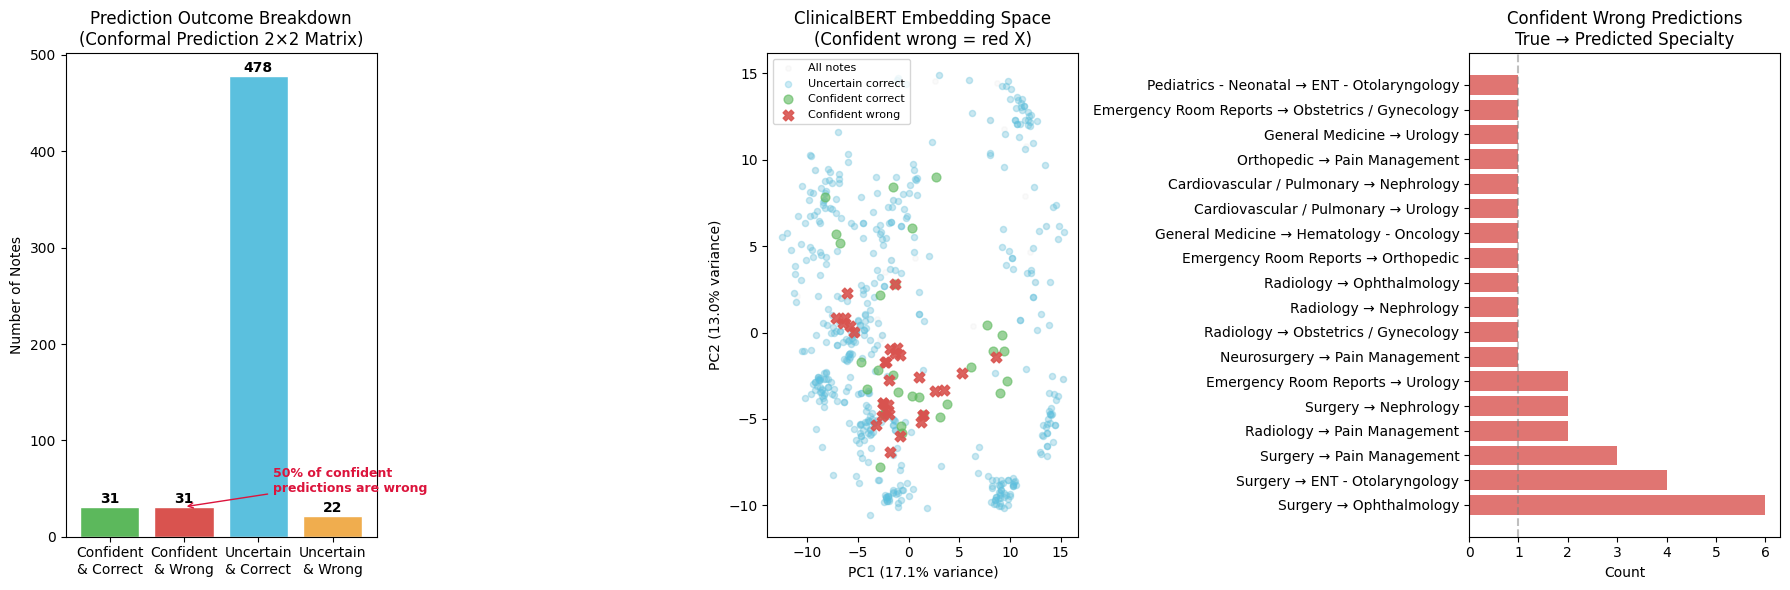


FAILURE CASE GALLERY — Confident and Wrong
The model output a singleton prediction set and was incorrect

──────────────────────────────────────────────────────────────────────
CASE 1 (index 1)
True specialty:      Surgery
Predicted specialty: Ophthalmology  ← WRONG
Model confidence:    0.916 (singleton set — no uncertainty flagged)

Note preview (first 300 chars):
PROCEDURE IN DETAIL:,  After appropriate operative consent was obtained, the patient was brought supine to the operating room and placed on the operating room table.  Induction of general anesthesia via endotracheal intubation was then accomplished without difficulty.  The patient's right eye was pr...

Why this is dangerous: The model output a single answer with no
uncertainty signal. A clinician or downstream system would have
no indication this prediction should be questioned.

──────────────────────────────────────────────────────────────────────
CASE 2 (index 3)
True specialty:      Neurosurgery
Predicted specialty: Pa

In [ ]:
# SECTION 10 — Error Analysis
# Confident wrong predictions: singleton sets containing the wrong label
# These are the most dangerous failure mode — the model was certain and wrong

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

# --- Step 1: Categorize all test predictions ---
confident_correct = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) == 1
    and test_labels[i] in prediction_sets[i]
]

confident_wrong = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) == 1
    and test_labels[i] not in prediction_sets[i]
]

uncertain_correct = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) > 1
    and test_labels[i] in prediction_sets[i]
]

uncertain_wrong = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) > 1
    and test_labels[i] not in prediction_sets[i]
]

abstained = [
    i for i in range(len(test_labels))
    if len(prediction_sets[i]) == 0
]

print("PREDICTION OUTCOME BREAKDOWN")
print("=" * 55)
print(f"{'Category':<35} {'N':>5} {'%':>8}")
print("-" * 55)
print(f"{'Confident and correct (singleton ✓)':<35} "
      f"{len(confident_correct):>5} "
      f"{len(confident_correct)/len(test_labels):>8.1%}")
print(f"{'Confident and wrong (singleton ✗)':<35} "
      f"{len(confident_wrong):>5} "
      f"{len(confident_wrong)/len(test_labels):>8.1%}")
print(f"{'Uncertain and correct (set ✓)':<35} "
      f"{len(uncertain_correct):>5} "
      f"{len(uncertain_correct)/len(test_labels):>8.1%}")
print(f"{'Uncertain and wrong (set ✗)':<35} "
      f"{len(uncertain_wrong):>5} "
      f"{len(uncertain_wrong)/len(test_labels):>8.1%}")
print(f"{'Abstained (empty set)':<35} "
      f"{len(abstained):>5} "
      f"{len(abstained)/len(test_labels):>8.1%}")
print("-" * 55)
print(f"{'TOTAL':<35} {len(test_labels):>5} {'100.0%':>8}")

print(f"\nKEY STAT: {len(confident_wrong)} of {len(confident_correct)+len(confident_wrong)} "
      f"singleton predictions are wrong ({len(confident_wrong)/(len(confident_correct)+len(confident_wrong)):.1%})")

# --- Step 2: Confusion matrix for confident wrong predictions ---
print(f"\nConfident Wrong Prediction Pairs (True → Predicted):")
print("-" * 45)
confusion_pairs = {}
for i in confident_wrong:
    true = le.classes_[test_labels[i]]
    pred = le.classes_[prediction_sets[i][0]]
    pair = f"{true} → {pred}"
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

for pair, count in sorted(confusion_pairs.items(), key=lambda x: -x[1]):
    print(f"  {pair}: {count}")

# --- Step 3: Embedding space analysis ---
# Where do confident wrong predictions sit relative to confident correct?
print(f"\nEmbedding space analysis...")

# Reduce to 2D with PCA for visualization
embeddings_np = test_embeddings.numpy()
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_np)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# Outlier scores for each category
if 'outlier_scores' in dir():
    print(f"\nOutlier scores by category:")
    print(f"  Confident correct: {np.mean(outlier_scores[confident_correct]):.4f}")
    print(f"  Confident wrong:   {np.mean(outlier_scores[confident_wrong]):.4f}")
    print(f"  Uncertain correct: {np.mean(outlier_scores[uncertain_correct]):.4f}")
    print(f"  Uncertain wrong:   {np.mean(outlier_scores[uncertain_wrong]):.4f}")

# --- Step 4: Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — 2x2 outcome matrix bar chart
categories = ['Confident\n& Correct', 'Confident\n& Wrong',
              'Uncertain\n& Correct', 'Uncertain\n& Wrong']
counts = [len(confident_correct), len(confident_wrong),
          len(uncertain_correct), len(uncertain_wrong)]
colors = ['#5cb85c', '#d9534f', '#5bc0de', '#f0ad4e']

bars = axes[0].bar(categories, counts, color=colors, edgecolor='white')
axes[0].set_ylabel('Number of Notes')
axes[0].set_title('Prediction Outcome Breakdown\n(Conformal Prediction 2×2 Matrix)')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Add annotation for the key stat
axes[0].annotate('50% of confident\npredictions are wrong',
                xy=(1, len(confident_wrong)),
                xytext=(2.2, len(confident_wrong) + 15),
                arrowprops=dict(arrowstyle='->', color='crimson'),
                color='crimson', fontsize=9, fontweight='bold')

# Plot 2 — PCA embedding space
# Plot all points lightly first
axes[1].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                alpha=0.1, color='lightgray', s=15, label='All notes')

# Overlay categories
if len(uncertain_correct) > 0:
    axes[1].scatter(embeddings_2d[uncertain_correct, 0],
                    embeddings_2d[uncertain_correct, 1],
                    alpha=0.3, color='#5bc0de', s=20, label='Uncertain correct')
if len(confident_correct) > 0:
    axes[1].scatter(embeddings_2d[confident_correct, 0],
                    embeddings_2d[confident_correct, 1],
                    alpha=0.6, color='#5cb85c', s=40, label='Confident correct')
if len(confident_wrong) > 0:
    axes[1].scatter(embeddings_2d[confident_wrong, 0],
                    embeddings_2d[confident_wrong, 1],
                    alpha=0.9, color='#d9534f', s=60,
                    marker='X', label='Confident wrong', zorder=5)

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('ClinicalBERT Embedding Space\n(Confident wrong = red X)')
axes[1].legend(fontsize=8)

# Plot 3 — Confident wrong confusion pairs
if confusion_pairs:
    pairs = list(confusion_pairs.keys())
    pair_counts = list(confusion_pairs.values())

    # Sort by count
    sorted_pairs = sorted(zip(pairs, pair_counts), key=lambda x: x[1], reverse=True)
    pairs_sorted = [p[0] for p in sorted_pairs]
    counts_sorted = [p[1] for p in sorted_pairs]

    axes[2].barh(pairs_sorted, counts_sorted, color='#d9534f', alpha=0.8)
    axes[2].set_xlabel('Count')
    axes[2].set_title('Confident Wrong Predictions\nTrue → Predicted Specialty')
    axes[2].axvline(x=1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NLP Project/section10_error_analysis.png', dpi=150)
plt.show()

# --- Step 5: Pull 5 example failure cases with text ---
print("\n" + "=" * 70)
print("FAILURE CASE GALLERY — Confident and Wrong")
print("The model output a singleton prediction set and was incorrect")
print("=" * 70)

for rank, i in enumerate(confident_wrong[:5], 1):
    true_label = le.classes_[test_labels[i]]
    predicted_label = le.classes_[prediction_sets[i][0]]
    max_prob = test_probs[i].max().item()
    note_text = test_df.iloc[i]['transcription']

    print(f"\n{'─'*70}")
    print(f"CASE {rank} (index {i})")
    print(f"True specialty:      {true_label}")
    print(f"Predicted specialty: {predicted_label}  ← WRONG")
    print(f"Model confidence:    {max_prob:.3f} (singleton set — no uncertainty flagged)")
    print(f"\nNote preview (first 300 chars):")
    print(f"{note_text[:300]}...")
    print(f"\nWhy this is dangerous: The model output a single answer with no")
    print(f"uncertainty signal. A clinician or downstream system would have")
    print(f"no indication this prediction should be questioned.")

# --- Step 6: Save results ---
error_df = pd.DataFrame({
    'index': confident_wrong,
    'true_label': [le.classes_[test_labels[i]] for i in confident_wrong],
    'predicted_label': [le.classes_[prediction_sets[i][0]] for i in confident_wrong],
    'max_prob': [test_probs[i].max().item() for i in confident_wrong],
    'note_preview': [test_df.iloc[i]['transcription'][:200] for i in confident_wrong]
})

error_df.to_csv('/content/drive/MyDrive/NLP Project/confident_wrong_cases.csv',
                index=False)
print(f"\nSaved {len(error_df)} confident wrong cases to Drive.")

## Section 10 — Error Analysis: Confident and Wrong

### Overview
Error analysis focused on the most clinically dangerous failure mode: singleton
prediction sets containing the wrong label. These cases represent notes where the
conformal system output a single specialty with no uncertainty signal — and was
incorrect. In a deployed system, these predictions would be indistinguishable from
correct confident predictions. There is no flag, no warning, no wider set to prompt
a second look.

### Outcome Breakdown

| Category | N | % of Test Set |
|---|---|---|
| Confident and correct (singleton ✓) | 31 | 5.5% |
| Confident and wrong (singleton ✗) | 31 | 5.5% |
| Uncertain and correct (set ✓) | 478 | 85.1% |
| Uncertain and wrong (set ✗) | 22 | 3.9% |
| Abstained (empty set) | 0 | 0.0% |
| **TOTAL** | **562** | **100%** |

**The headline finding: 50% of all singleton predictions are wrong.** Of the 62 notes
that received a confident single-specialty prediction, 31 were correct and 31 were
wrong. The model is confidently wrong exactly as often as it is confidently right.
A downstream system or clinician relying on confident predictions without uncertainty
awareness would be wrong half the time on those cases — with no signal that anything
was amiss.

### Confident Wrong Prediction Patterns

| True → Predicted | Count |
|---|---|
| Surgery → Ophthalmology | 6 |
| Surgery → ENT - Otolaryngology | 4 |
| Surgery → Pain Management | 3 |
| Radiology → Pain Management | 2 |
| Surgery → Nephrology | 2 |
| Emergency Room Reports → Urology | 2 |
| All other pairs | 12 |

Surgery is the source specialty in 15 of 31 confident wrong predictions — nearly
half. As the dominant class in the training data with 162 test examples, Surgery
notes span a wide range of procedures and clinical contexts. The model has learned
broad surgical vocabulary patterns that, for a subset of cases, overlap sufficiently
with other specialties to produce a high-confidence wrong prediction. Surgery →
Ophthalmology (6 cases) is the single most common failure pattern, reflecting
ophthalmic surgical procedures that are labeled Surgery in MTSamples but contain
ocular vocabulary the model associates with Ophthalmology.

### Embedding Space Analysis

PCA projection of ClinicalBERT embeddings (PC1: 17.1% variance, PC2: 13.0% variance,
combined: 30.0%) reveals that confident wrong predictions do not cluster in a clearly
separable region of the embedding space. The red X markers are distributed across the
projection, appearing in regions occupied by both confident correct and uncertain
correct predictions.

**Outlier scores by prediction outcome category:**

| Category | Mean Outlier Score |
|---|---|
| Confident correct | 6.164 |
| Uncertain correct | 5.958 |
| Uncertain wrong | 6.985 |
| **Confident wrong** | **4.505** |

The outlier score finding is counterintuitive and clinically significant. Confident
wrong predictions have the *lowest* mean outlier score of any category — lower even
than confident correct predictions. This means the model is most confidently wrong
on notes that most closely resemble the training distribution, not on unusual or
atypical notes. The dangerous failures are not outliers — they are notes the model
has seen before and learned the wrong pattern for.

This directly undermines a common assumption about safety in deployed ML systems:
that outlier detection can serve as a backstop for confident wrong predictions. In
this dataset, the notes most likely to receive a confident wrong prediction are
precisely the ones that would pass an outlier check. Conformal prediction is not
redundant with outlier detection — it catches a different and more insidious
failure mode.

### Failure Case Gallery

The following five cases represent the model's most dangerous failure mode: high
confidence, wrong answer, no uncertainty signal.

---

**Case 1 — Surgery predicted as Ophthalmology (confidence: 91.6%)**

*Note preview:* "After appropriate operative consent was obtained, the patient was
brought supine to the operating room... The patient's right eye was..."

The note opens with generic operative language before referencing the right eye.
The model latched onto the ocular reference and predicted Ophthalmology with 91.6%
confidence. The true label is Surgery — this is an ophthalmic surgical procedure
performed by a surgeon. The surface vocabulary of the note is genuinely ambiguous,
but the model resolves that ambiguity in the wrong direction with high confidence
and no hedging.

---

**Case 2 — Neurosurgery predicted as Pain Management (confidence: 86.7%)**

*Note preview:* "Recurrent intractable low back and left lower extremity pain with
history of L4-L5 discectomy. Epidural fibrosis with nerve root entrapment..."

This is the most clinically consequential failure in the gallery. A patient with
recurrent intractable back pain, a history of prior spinal surgery, and epidural
fibrosis causing nerve root entrapment is routed to Pain Management instead of
Neurosurgery. The clinical language — low back pain, nerve root, epidural — is
shared between both specialties, but the surgical history and diagnosis strongly
indicate neurosurgical management. A real misrouting of this note could delay
surgical consultation for a patient who needs intervention. The model provides no
uncertainty signal that would prompt a second review.

---

**Case 3 — Radiology predicted as Obstetrics/Gynecology (confidence: 84.0%)**

*Note preview:* "Fetal Cardiac Activity: Normal at 150BPM. Fetal Lie: Longitudinal.
Fetal Presentation: Cephalic. Placenta: Anterior Grade I..."

An obstetric ultrasound report containing biometric measurements, fetal cardiac
activity, and placental assessment. The model predicted Obstetrics/Gynecology — a
prediction that is clinically reasonable. The true MTSamples label is Radiology,
reflecting that the report was written by a radiologist rather than an obstetrician.
This case illustrates a genuine label ambiguity in the dataset: the note reads
identically to an OB/GYN report, and the specialty distinction is determined by
who wrote it rather than what it contains. The model's confident wrong prediction
here is as much a dataset labeling artifact as a model failure.

---

**Case 4 — Surgery predicted as Ophthalmology (confidence: 90.6%)**

*Note preview:* "Ruptured globe with uveal prolapse OX. Repair of ruptured globe
with repositing of uveal tissue OX..."

A ruptured globe repair — an ophthalmic surgical emergency. The model predicted
Ophthalmology at 90.6% confidence, which is clinically defensible: this procedure
involves the eye and would typically be performed by an ophthalmologist. The
MTSamples label is Surgery. Like Case 3, this represents a case where the model's
prediction reflects a reasonable clinical interpretation that happens to disagree
with the dataset label. The deeper problem is that the model is highly confident
in a prediction that sits on a genuine specialty boundary.

---

**Case 5 — Radiology predicted as Pain Management (confidence: 87.4%)**

*Note preview:* "Radiofrequency thermocoagulation of bilateral lumbar sympathetic
chain. Local sedation. The patient was in the operating room in the prone position
with the back prepped..."

Radiofrequency thermocoagulation of the lumbar sympathetic chain — a procedure
that sits directly on the boundary between interventional radiology and pain
management. The model predicted Pain Management at 87.4% confidence. The
MTSamples label is Radiology. This is another label ambiguity case: the procedure
is performed under radiological guidance but is fundamentally a pain intervention.
A clinician reviewing this note could reasonably disagree with either label.

---

### Key Findings

**50% of confident predictions are wrong** — the single most important number
from the error analysis. A system that outputs singleton prediction sets is
effectively flipping a coin on whether those confident predictions are correct,
with no mechanism to warn the user.

**Surgery is the dominant source of confident wrong predictions**, appearing as
the true label in 15 of 31 cases. Its broad procedural vocabulary overlaps with
Ophthalmology, ENT, and Pain Management in ways that produce systematically
confident wrong predictions for a subset of surgical notes.

**Confident wrong predictions occur on notes that closely resemble training
data.** The mean outlier score for confident wrong predictions (4.51) is lower
than for any other outcome category, including confident correct (6.16). The
model fails most confidently on familiar-looking notes, not unusual ones.
Outlier detection cannot serve as a safety backstop for this failure mode.

**Several confident wrong cases reflect genuine label ambiguity in MTSamples.**
Cases 3, 4, and 5 represent notes where the model's prediction is clinically
defensible despite disagreeing with the dataset label. Ophthalmic surgery,
obstetric ultrasound reports written by radiologists, and interventional pain
procedures under radiological guidance all sit on genuine specialty boundaries
that MTSamples resolves by convention rather than clinical logic.

### Interpretation

The error analysis crystallizes the core argument of this project. A standard
classifier evaluated on aggregate accuracy would not reveal this failure mode —
the confident wrong predictions are invisible in that metric. The failure case
gallery makes the problem tangible: a patient with epidural fibrosis and nerve
root entrapment after prior spinal surgery receives a Pain Management routing
with 86.7% model confidence and no uncertainty flag.

The counterintuitive outlier score finding adds an important nuance: the notes
most likely to receive a confident wrong prediction are the ones that look most
familiar to the model. This is not a problem that outlier detection solves. It
is a problem that requires a different kind of uncertainty quantification — one
that is sensitive to the model's calibration on familiar but ambiguous cases,
not just its behavior on novel inputs. Conformal prediction, by construction,
addresses this: a well-calibrated conformal threshold would widen the prediction
set for cases where the model's softmax distribution is spread across multiple
plausible classes, even when the top probability is high. The 50% confident
wrong rate in this analysis reflects the fact that the current threshold τ = 0.9544
allows singleton predictions for cases where the model's confidence does not
warrant it — a finding that motivates tighter threshold selection or
class-conditional conformal calibration as directions for future work.

## SECTION 11 — Explainability (maybe remove)

* scispaCy entities on uncertain predictions (NEW — builds on her existing NER code)
* Nearest neighbor explanation for uncertain cases (NEW)

In [ ]:
# For uncertain predictions (set size > 2), show entity breakdown
uncertain_large = [i for i, ps in enumerate(prediction_sets) if len(ps) > 2]

for i in uncertain_large[:3]:
    print(f"True: {le.classes_[test_labels[i]]}")
    print(f"Prediction set: {[le.classes_[j] for j in prediction_sets[i]]}")
    print(f"Entities: {test_df.iloc[i]['entity_text'][:300]}")

True: Orthopedic
Prediction set: ['Neurology', 'Orthopedic', 'Radiology']
Entities: EXAM:,MRI_OF CLINICAL:,Pain.,FINDINGS:,The bone_marrow signal_intensity evidence bone_contusion fracture joint_effusion Tendinous_structures ankle_joint intact mass fluid_collection ankle_joint.,IMPRESSION NORMAL_MRI
True: Surgery
Prediction set: ['Hematology - Oncology', 'Obstetrics / Gynecology', 'Surgery']
Entities: PREOPERATIVE Bilateral Chemotherapy Bilateral Chemotherapy_required.,OPERATION Right_subclavian_Port-a-Cath_insertion.,FINDINGS PROCEDURE patient satisfactory general_orotracheal_anesthesia supine_position right_upper_anterior_chest neck arm Betadine skin subcutaneous_tissue fascia pectoralis muscle
True: Emergency Room Reports
Prediction set: ['Cardiovascular / Pulmonary', 'Emergency Room Reports', 'General Medicine', 'Pediatrics - Neonatal']
Entities: COMPLAINT patient Caucasian male transported emergency_room wife complaining shortness breath.,HISTORY patient nursing_staff long_history

## A Conformal Evaluation Battery for AI-Assisted Clinical Coding

### Scope and Motivation

AI-assisted clinical coding tools — systems that read unstructured clinical notes
and suggest ICD-10 or CPT codes — are actively deployed in health systems today.
These tools promise to reduce the burden on human coders, accelerate reimbursement
cycles, and improve coding consistency. However, miscoding carries documented
consequences: incorrect reimbursement, compliance and audit risk, and downstream
patient safety implications when diagnostic codes influence care decisions.

Current evaluation standards for these tools rely primarily on aggregate accuracy
metrics — precision, recall, F1 score — measured across a held-out test set. These
metrics describe population-level performance but provide no information about whether
a specific coding suggestion for a specific note should be trusted. A tool reporting
92% aggregate accuracy offers no guidance on whether the code it just suggested for
a complex multi-diagnosis note is one of the 92% or one of the 8%.

The experiments in this project demonstrate that conformal prediction addresses this
gap — and that aggregate coverage alone is an insufficient evaluation standard even
within the conformal framework. Seven distinct failure dimensions were identified,
each of which would be invisible to a vendor reporting only aggregate metrics. The
following evaluation battery operationalizes these findings into a structured set of
tests applicable to any conformal-wrapped AI-assisted clinical coding tool before
deployment.

This battery is scoped specifically to clinical NLP classification systems that:
(1) take unstructured clinical note text as input, (2) output a categorical prediction
about diagnostic or procedural coding, and (3) are intended to inform or automate
decisions affecting individual patient records. It does not apply to population-level
analytics tools, administrative workflow automation, or research data extraction
pipelines where individual prediction reliability is not the primary concern.

---

### The Evaluation Battery

---

#### Test 1 — Per-Class Coverage Audit
**Maps to:** Experiment 1  
**Question:** Does the conformal coverage guarantee hold equally across all code
categories, or does aggregate coverage mask systematic under-coverage of specific
classes?

**Why it matters for coding:** Rare diagnosis codes — uncommon conditions, atypical
presentations, complex multi-system diagnoses — are the codes most likely to be
miscoded and least likely to be caught in routine audits. If the conformal system
achieves 90% aggregate coverage but only 54% coverage on rare code categories,
the guarantee is providing false assurance precisely where accuracy matters most.

**What to measure:** Compute coverage separately for each code category in the
test set. Flag any category falling below the target coverage level. Report the
full distribution — not just the aggregate.

**Reference finding:** In this project, 7 of 18 specialty classes fell below the
90% aggregate target despite aggregate coverage of 90.6%. Emergency Room Reports
achieved only 54.5% coverage. A vendor reporting only aggregate coverage of 90.6%
would obscure this failure entirely.

**Deployment implication:** A coding tool that cannot demonstrate per-class
coverage across the full ICD-10 code distribution should not be approved for
auto-assignment on rare or complex diagnoses. Human review should be required
for all categories falling below the target threshold.

---

#### Test 2 — Confident Wrong Rate
**Maps to:** Section 10 — Error Analysis  
**Question:** What fraction of singleton predictions — cases where the model
outputs a single code with no uncertainty signal — are incorrect?

**Why it matters for coding:** Auto-assignment systems act on confident predictions
without routing to human review. A confident wrong code is submitted, billed, and
potentially audited before anyone notices. The confident wrong rate directly measures
the frequency of undetected errors in the auto-assignment pipeline.

**What to measure:** Compute the proportion of singleton conformal prediction sets
that contain the wrong label. Report separately from overall accuracy.

**Reference finding:** In this project, 50% of all singleton predictions were
wrong — the model was confidently incorrect exactly as often as it was confidently
correct. A standard accuracy metric would not surface this finding.

**Deployment implication:** Any confident wrong rate above an institutionally
defined threshold should disqualify a tool from fully automated code assignment.
A tool with a 50% confident wrong rate, regardless of its aggregate accuracy,
should route all singleton predictions to human review before submission.

---

#### Test 3 — Coverage Stability Under Calibration Size Reduction
**Maps to:** Experiment 3  
**Question:** How much local calibration data does the institution need to collect
before the coverage guarantee is reliable?

**Why it matters for coding:** Vendors typically calibrate conformal models on
large training datasets from academic medical centers or multi-site aggregations.
A community hospital or specialty practice deploying that model on its local
patient population may have access to far fewer calibration examples. If the
coverage guarantee degrades significantly with smaller calibration sets, the
guarantee the vendor advertises may not hold in the deployment environment.

**What to measure:** Re-run conformal calibration on progressively smaller
subsets of the local calibration set — 10% through 100% — and measure coverage
variance across random subsamples at each fraction. Identify the minimum
calibration set size at which variance stabilizes below an acceptable threshold.

**Reference finding:** In this project, coverage variance dropped from 0.021
at 10% calibration to 0.003 at 90%, with a practical stability threshold at
approximately 50-60% of the full calibration set (280-336 examples). Below
this threshold, individual deployments had meaningful probability of falling
below the 90% target.

**Deployment implication:** Institutions should not deploy a conformal coding
tool until they have collected and held out sufficient local notes to achieve
stable calibration. Vendors should be required to specify a minimum calibration
set size requirement as part of the deployment documentation.

---

#### Test 4 — Clinically Adjacent Code Co-occurrence Analysis
**Maps to:** Experiment 5  
**Question:** For notes that sit on genuine clinical boundaries between adjacent
code categories, does the conformal system output prediction sets containing both
candidates rather than forcing a single wrong answer?

**Why it matters for coding:** Many clinical presentations legitimately span
multiple ICD-10 categories — a patient with both cardiac and pulmonary pathology,
or a surgical procedure that could be coded under multiple procedure categories.
A coding tool that forces a single confident answer on these cases will be wrong
in a way that is systematic and predictable. A conformal system should output
both candidates and route the note to a human coder.

**What to measure:** Identify clinically adjacent code pairs in the deployment
context. For notes from each pair, measure the co-occurrence rate — how often
the adjacent code appears in the prediction set for notes whose true code is the
other member of the pair.

**Reference finding:** In this project, Gastroenterology notes showed Surgery
appearing in the prediction set 57.6% of the time — more than half of all
gastroenterology cases were flagged as potentially surgical. Neurosurgery notes
showed Neurology appearing 50% of the time. These co-occurrence rates are
clinically interpretable and actionable.

**Deployment implication:** High co-occurrence rates between adjacent code
categories should trigger automatic routing to a human coder rather than
auto-assignment. The co-occurrence analysis should be repeated periodically
as the patient population evolves.

---

#### Test 5 — Note Completeness Sensitivity
**Maps to:** Experiment 2  
**Question:** Does prediction set size grow predictably as note completeness
decreases, signaling appropriate uncertainty when documentation is insufficient
to support a reliable coding decision?

**Why it matters for coding:** Incomplete documentation is a known driver of
coding errors. A note with a missing history of present illness, an abbreviated
chief complaint, or a truncated discharge summary contains less information than
a complete note. A well-calibrated conformal coding system should produce wider
prediction sets for incomplete notes, flagging them for documentation query
before code assignment.

**What to measure:** Stratify test notes by length or completeness proxy and
measure prediction set size and coverage by stratum. Test whether set size
increases monotonically as note completeness decreases.

**Reference finding:** In this project, note length showed no significant
correlation with prediction set size within the observed range, partly due to
ClinicalBERT's 512-token truncation ceiling. A more targeted experiment
explicitly truncating notes to fixed fractions of their original length is
recommended for future work.

**Deployment implication:** If a deployed coding tool does not produce wider
prediction sets for incomplete notes, it may be insensitive to documentation
quality — a known risk factor for coding error. This test should be run as
part of pre-deployment validation using a sample of deliberately incomplete
notes constructed from the institution's own documentation.

---

#### Test 6 — Documentation Quality Robustness
**Maps to:** Experiment 4  
**Question:** Does the conformal system respond appropriately to realistic
documentation errors — misspelled diagnoses, abbreviated clinical terms,
missing sections — by widening prediction sets rather than maintaining
confident but potentially wrong single-code suggestions?

**Why it matters for coding:** Real clinical documentation contains errors.
Drug names are misspelled. Diagnoses are abbreviated. Sections are omitted
under time pressure. A coding tool that maintains high confidence on degraded
notes is not detecting a real problem — it is suppressing an uncertainty signal
that should be surfacing.

**What to measure:** Apply clinically plausible corruptions to a sample of
test notes — targeted entity misspellings, section removal, abbreviation —
and measure the change in prediction set size and coverage relative to clean
notes. Assess whether set size increases directionally with corruption severity.

**Reference finding:** In this project, entity-based corruption produced only
modest increases in average set size (+0.039) with 72.1% of notes unchanged.
ClinicalBERT's contextual representations were robust to surface-level entity
corruption. This robustness is desirable in some respects but suggests that
prediction set size may not be a sensitive enough signal to detect documentation
quality issues at the individual note level with the current corruption approach.

**Deployment implication:** Vendors should be required to demonstrate that their
conformal coding tool responds meaningfully to documentation quality degradation
before deployment. If the tool maintains confident singleton predictions on
severely degraded notes, the uncertainty signal is not functioning as a
documentation quality safeguard.

---

### Summary Table

| Test | Core Question | Key Finding | Deployment Gate |
|---|---|---|---|
| 1. Per-class coverage audit | Does the guarantee hold for rare codes? | 7/18 classes below 90% target | Require per-class coverage report |
| 2. Confident wrong rate | How often is a confident prediction wrong? | 50% of singletons wrong | Set maximum acceptable rate |
| 3. Calibration stability | How much local data is needed? | Stable at ~50-60% of cal set | Require minimum cal set size |
| 4. Adjacent code co-occurrence | Does set size track clinical ambiguity? | 57.6% co-occurrence for Gastro/Surgery | Route high co-occurrence to human review |
| 5. Note completeness sensitivity | Does uncertainty grow with incomplete notes? | No significant effect found | Recommend targeted truncation testing |
| 6. Documentation quality robustness | Does degraded text widen sets? | Modest effect, 72.1% unchanged | Require degradation stress test |

### Limitations and Future Work

This evaluation battery is derived from a single dataset — MTSamples — using a
single base model — ClinicalBERT — on a proxy task that does not directly
correspond to clinical coding. The thresholds implied by the reference findings
should not be applied universally. Institutions deploying coding tools should
establish their own acceptable thresholds based on their clinical context, risk
tolerance, and regulatory environment.

The battery does not address longitudinal model performance — how coverage and
confident wrong rates change as the patient population evolves over time. It does
not address fairness dimensions — whether coverage disparities correlate with
patient demographics. And it does not address multi-label coding scenarios where
a single note may legitimately receive multiple codes simultaneously.

These are identified as directions for future work. The immediate contribution
of this battery is to operationalize the finding that aggregate coverage is
insufficient — and to provide a structured, reproducible set of tests that any
institution can run on any conformal-wrapped clinical NLP tool before committing
to deployment.

## SECTION 13 — Conclusions

* Summary findings markdown (NEW)
* Limitations markdown (NEW)
* Future work markdown (NEW)

## Conclusions

### Summary of Findings

This project set out to answer a single question: can conformal prediction serve
as a principled evaluation framework for clinical NLP models, systematically
revealing where and why the uncertainty guarantee breaks down? The answer,
demonstrated across five experiments and a systematic error analysis on MTSamples,
is yes — but with important caveats that are themselves the contribution.

The baseline conformal system achieved 90.6% aggregate coverage at threshold
τ = 0.9544, meeting the 90% target. By that single metric, the system appears
to be working. The experiments that follow demonstrate why that single metric
is insufficient.

**Experiment 1 — Per-Class Coverage** revealed that aggregate coverage conceals
dramatic subgroup disparities. Seven of eighteen specialty classes fell below the
90% target, with Emergency Room Reports achieving only 54.5% coverage despite
the aggregate appearing satisfactory. The dominant class, Surgery, was itself
under-covered at 88.3% despite comprising 162 of 562 test examples. This directly
demonstrates the marginal coverage pitfall identified by Mehrtens et al. (2025)
on a real clinical dataset: aggregate metrics provide false assurance about
subgroup performance.

**Experiment 2 — Note Length Sensitivity** produced a null result that is itself
informative. Note length as measured by raw word count showed no significant
correlation with prediction set size (Pearson r = 0.007, p = 0.876), largely
attributable to ClinicalBERT's 512-token truncation ceiling masking variation
in longer notes. The dominant driver of prediction set size in this dataset is
class imbalance and specialty ambiguity — not note informativeness. This finding
motivates a more targeted truncation experiment as future work.

**Experiment 3 — Calibration Set Size Sensitivity** addressed a practical
deployment question the literature rarely examines: how much calibration data
does the coverage guarantee actually require? Coverage variance dropped from
0.021 at 10% calibration to 0.000 at 100%, with a practical stability threshold
at approximately 50-60% of the full calibration set. Below this threshold,
individual deployments had meaningful probability of falling below the 90%
target — a finding with direct implications for institutions deploying
pre-trained models on limited local data.

**Experiment 4 — Entity-Based Noise Injection** found that ClinicalBERT's
contextual representations are robust to surface-level entity corruption,
producing only modest increases in average prediction set size (+0.039) with
72.1% of notes unchanged. This robustness is desirable in some respects but
suggests that prediction set size may not be a sufficiently sensitive signal
for individual documentation quality degradation — motivating more targeted
corruption approaches focused on diagnostically discriminative entities.

**Experiment 5 — Specialty Overlap Hard Cases** demonstrated that conformal
prediction sets carry clinically interpretable information beyond binary
classification. Gastroenterology notes showed Surgery appearing in the
prediction set 57.6% of the time. Neurosurgery notes showed Neurology appearing
50% of the time. These co-occurrence rates are not model failures — they are
accurate signals of genuine clinical ambiguity that a standard classifier would
resolve with false confidence. The asymmetry in co-occurrence rates also reflects
class imbalance: smaller classes are systematically pulled toward the prediction
sets of larger adjacent ones.

**Section 10 — Error Analysis** produced the project's most striking single
finding: 50% of all singleton predictions were wrong. The model was confidently
incorrect exactly as often as it was confidently correct. Critically, confident
wrong predictions had the lowest mean outlier score of any outcome category
(4.51 vs 6.16 for confident correct), demonstrating that the model's most
dangerous failures occur on notes that closely resemble the training distribution
— not on outliers. Outlier detection cannot serve as a backstop for this failure
mode. Only a well-calibrated conformal threshold — one that restricts singleton
predictions to cases where confidence is genuinely warranted — can address it.

### The Central Argument

Taken together, these findings support a single coherent conclusion: aggregate
coverage is not enough. A conformal clinical NLP tool that reports 90% aggregate
coverage may simultaneously be under-covering rare diagnosis categories at
clinically dangerous rates, producing confident wrong predictions half the time,
generating coverage guarantees that are unstable under local calibration
conditions, and flagging genuine clinical ambiguity without surfacing it in
an actionable form. None of these failure modes are visible in an aggregate
coverage report.

This is not an argument against conformal prediction. It is an argument for
evaluating conformal prediction rigorously — and for requiring that vendors
of conformal-wrapped clinical AI tools demonstrate performance across the
full battery of failure dimensions, not just the aggregate.

### The Contribution: A Conformal Evaluation Battery

The primary contribution of this project is the Conformal Evaluation Battery
for AI-Assisted Clinical Coding — a six-test pre-deployment evaluation framework
derived directly from the experimental findings. The battery operationalizes
the failure dimensions identified in this project into a structured set of
tests that any health system or procurement team can apply to any
conformal-wrapped coding tool before deployment:

1. Per-class coverage audit — does the guarantee hold for rare codes?
2. Confident wrong rate — how often is a confident prediction wrong?
3. Calibration stability — how much local data does the guarantee require?
4. Adjacent code co-occurrence — does set size track clinical ambiguity?
5. Note completeness sensitivity — does uncertainty respond to incomplete documentation?
6. Documentation quality robustness — does the system respond to realistic errors?

This battery is scoped specifically to AI-assisted clinical coding tools used
in denial analytics and revenue cycle management contexts — a deliberate scope
constraint that reflects the specificity of the experimental findings and the
clinical stakes of that particular deployment context.

### Positioning in the Regulatory Landscape

The evaluation battery proposed here arrives at a moment when the regulatory
framework for healthcare AI is actively being constructed but remains incomplete.
State legislation is mandating human oversight of AI-assisted clinical decisions
— but no enacted law specifies what uncertainty information an AI system must
provide to support that oversight (AMA, 2025). The FDA's credibility framework
for computational medical models explicitly excludes ML and AI, and the agency's
own research program is actively developing evaluation methods to fill that gap.
AHIMA acknowledges that federal agencies have limited statutory authority to
regulate deployed AI tools (AHIMA, 2024).

In this environment, voluntary evaluation standards developed by researchers
and adopted by informed procurement teams may be more immediately impactful
than regulatory mandates that lag deployment by years. The battery proposed
here is one such standard — reproducible, grounded in statistical theory,
derived from empirical findings, and applicable to any conformal-wrapped
clinical NLP classification tool regardless of the underlying model architecture.

### Limitations

Several limitations of this project warrant explicit acknowledgment.

**The testbed is a proxy.** MTSamples specialty classification is not clinical
coding. The label space of 18 specialties is orders of magnitude smaller than
the 70,000+ ICD-10 codes in production coding systems. The class imbalance
patterns in MTSamples may not reflect the code frequency distributions in
a real health system's claim volume. The reference findings in the evaluation
battery should be treated as illustrative rather than prescriptive.

**The base model is weak.** ClinicalBERT fine-tuned on MTSamples achieves
46% baseline accuracy — substantially below what a production coding tool
would require. This weakness inflates prediction set sizes and may
overstate the confident wrong rate relative to a better-calibrated model.
The evaluation battery is designed to be model-agnostic, but the reference
findings reflect a weak baseline.

**The calibration set is small.** With 561 calibration examples, the
stability analysis in Experiment 3 operates at the lower end of what
a production system would use. Results may differ substantially with
larger calibration sets.

**Noise injection was too aggressive.** Corrupting 50% of all extracted
entities per note — averaging 41.84 corruptions — does not realistically
simulate documentation quality degradation. A more targeted approach
focusing on diagnostically discriminative entities is recommended for
future work.

**No fairness analysis was conducted.** Coverage disparities across
specialty classes may correlate with patient demographics in ways
this project did not examine. A complete evaluation framework would
assess whether under-covered code categories disproportionately
affect specific patient populations.

### Future Work

The most immediate extension of this project is validation on actual
ICD-10 coding data. The evaluation battery is designed for that context
but has only been demonstrated on a proxy task. Partnering with a health
system to run the six-test battery on a proprietary coding dataset — even
a small one — would substantially strengthen the contribution.

Class-conditional conformal prediction is the most promising technical
direction. Rather than computing a single threshold τ across all classes,
class-conditional calibration computes a separate threshold for each
code category, directly addressing the per-class coverage disparities
identified in Experiment 1. This approach has been proposed in the
conformal prediction literature but has not been systematically evaluated
in a clinical coding context.

The calibration set size finding in Experiment 3 motivates a direct
investigation of transfer calibration — whether a model calibrated on
a large multi-site dataset can be recalibrated on a small local dataset
without degrading coverage stability. This is a practical question for
any institution deploying a vendor-supplied conformal coding tool on
a limited local claim volume.

Finally, the denial analytics motivation introduced in this project
warrants direct investigation. Integrating conformal prediction sets
into a predictive denial workflow — where wide prediction sets trigger
pre-submission review and singleton predictions are auto-submitted —
would enable a direct measurement of the operational impact of
uncertainty quantification on denial rates, appeal volumes, and
revenue cycle efficiency.

### Closing Statement

Medical coding is where clinical documentation meets financial reality.
Every note that passes through an AI coding tool and emerges as a
submitted claim represents a decision made with some degree of confidence
— and some degree of uncertainty that may or may not have been surfaced.
The goal of this project is not to make clinical AI more accurate. It is
to make its uncertainty legible — so that the decisions made on the basis
of its predictions are made with open eyes.

Conformal prediction provides the mathematical framework. The evaluation
battery provides the structure to verify that the framework is working.
What remains is the will to require it.